<a href="https://colab.research.google.com/github/SorrentinoPablo/Survey_Security_Privacy_Neuromorphic_Computing/blob/main/From_MemRtoSNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![RuG Logo](https://www.rug.nl/about-ug/practical-matters/huisstijl/logobank-new/logo-faculteiten/eng-logo/horizontal/rood/png/rugr_fse_logoen_rood_rgb.png)

---

# **From Memristor to Neuron**


```
Pablo Sorrentino and Fatih Turkmen

# Memristor Device Modeling and Neuromorphic Behavior

This notebook explores the physical behavior of a memristive device, from its basic I–V characteristics to its potential use as a spiking element.  
- Model the memristor with a compact state-equation.
- Explore hysteresis, relaxation, threshold, and volatility.
- Emulate neuron-like dynamics (integration, leakage, spiking).
- Produce quantitative plots for calibration and for use inside our SNN framework.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import odeint
from scipy.signal import square
import seaborn as sns
import os
import math
import pandas as pd, datetime


sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6,4)
np.random.seed(42)

## 1- Definition of the memristor model

Simple bipolar compact model:

The conductance G(t) evolves according to the applied voltage pulse.  
The rate of change is asymmetric for positive (SET) and negative (RESET) voltages.

In [ ]:
class Memristor:
    def __init__(self, Gmin=1e-6, Gmax=1e-3, k_set=0.1, k_reset=0.05, alpha=3.0, beta=2.0):
        self.Gmin, self.Gmax = Gmin, Gmax
        self.k_set, self.k_reset = k_set, k_reset
        self.alpha, self.beta = alpha, beta
        self.G = np.random.uniform(Gmin, Gmax)

    def update(self, V, dt=1e-3):
        if V >= 0:
            dG = self.k_set * (1 - (self.G/self.Gmax)**self.alpha) * V * dt
        else:
            dG = -self.k_reset * (1 - (self.Gmin/self.G)**self.beta) * abs(V) * dt
        self.G = np.clip(self.G + dG, self.Gmin, self.Gmax)
        return self.G

    def current(self, V):
        return self.G * V

## 2- Voltage application

This function applies a voltage waveform and records both current and conductance over time.

In [ ]:
def apply_voltage(mem, V_t, dt):
    G_hist, I_hist = [], []
    for V in V_t:
        G = mem.update(V, dt)
        I = mem.current(V)
        G_hist.append(G)
        I_hist.append(I)
    return np.array(G_hist), np.array(I_hist)

## 3- Graph 1 - I–V with Hysteresis
Demonstrate memristivity, the current depends on voltage AND past state.  
Sinusoidal voltage and plot the I–V loop.

- I–V hysteresis (A): look for loop area and where the loop opens - that localizes threshold voltages and switching zones (important for FIA pulse design).

- |I| vs V (B): acute for identifying when currents become large (risk for damage) and for estimating read signal magnitude for SCA.

- log10(|I|) vs V (C): reveals exponential conduction regimes and low-current tails. In MI, small differences in log-current may still leak information - plotting log makes small signals visible.

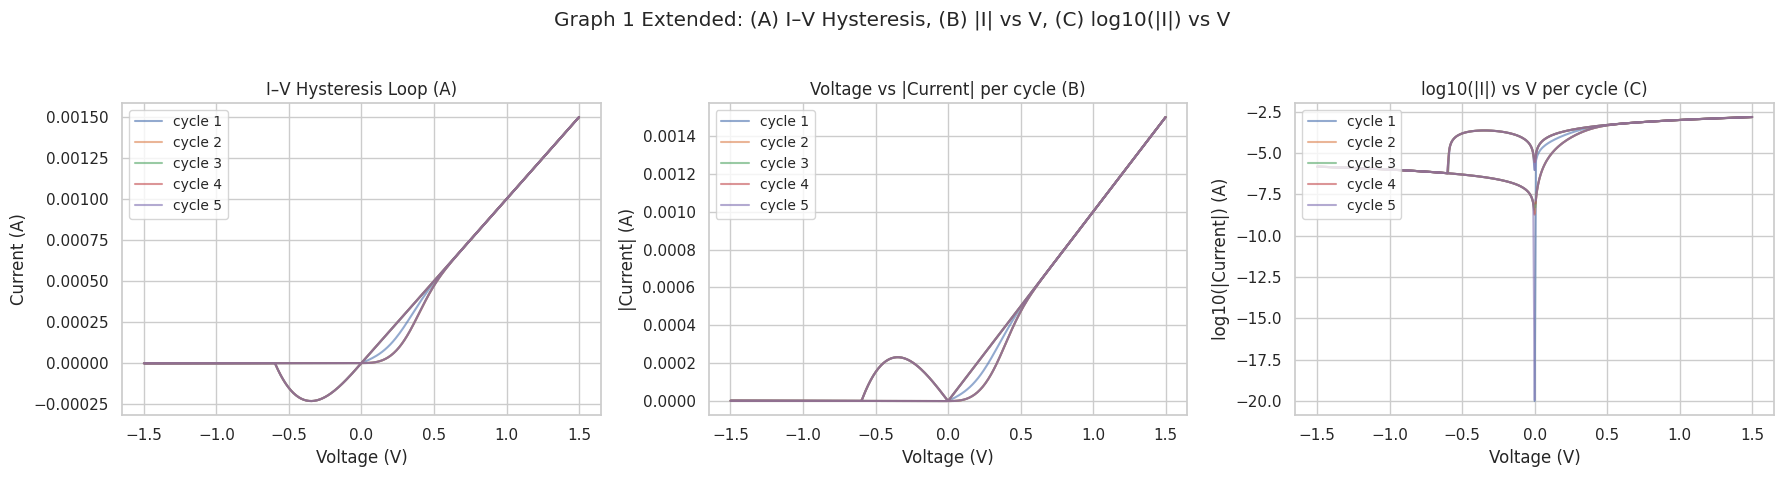

Saved: results/plots/graph1_extended_iv_abs_log.png
Saved per-cycle CSVs in results/device/ and switch points in results/device/switch_points.csv


In [ ]:
os.makedirs("results/plots", exist_ok=True)
os.makedirs("results/device", exist_ok=True)

# parameters for sweep
n_cycles = 5
points_per_cycle = 1000
freq = 1.0  # Hz, for conceptual time axis only
t_total = n_cycles / freq
t = np.linspace(0, t_total, n_cycles * points_per_cycle)

# build a sinusoidal sweep spanning multiple cycles and increasing amplitude slowly
V_peak = 1.5
V_t = V_peak * np.sin(2.0 * np.pi * freq * t)

# Simulate the memristor response over time
mem = Memristor()
G_hist, I_hist = apply_voltage(mem, V_t, dt=(t[1]-t[0]) if len(t)>1 else 1e-3)

# Break the time series into cycles for per-cycle plots
cycle_len = points_per_cycle
n_actual_cycles = int(len(V_t) / cycle_len)
V_cycles = V_t[:n_actual_cycles*cycle_len].reshape(n_actual_cycles, cycle_len)
I_cycles = I_hist[:n_actual_cycles*cycle_len].reshape(n_actual_cycles, cycle_len)
G_cycles = G_hist[:n_actual_cycles*cycle_len].reshape(n_actual_cycles, cycle_len)

# Save raw CSVs for later use
df_raw = pd.DataFrame({
    "time": t,
    "V": V_t,
    "I": I_hist,
    "G": G_hist
})
df_raw.to_csv("results/device/iv_time_series.csv", index=False)

# I–V hysteresis loop (various cycles)
fig, ax = plt.subplots(1, 3, figsize=(18,5))
for c in range(n_actual_cycles):
    ax[0].plot(V_cycles[c], I_cycles[c], alpha=0.6, label=f'cycle {c+1}')
ax[0].set_title("I–V Hysteresis Loop (A)")
ax[0].set_xlabel("Voltage (V)")
ax[0].set_ylabel("Current (A)")
ax[0].legend(loc='upper left', fontsize='small')
ax[0].grid(True)

# Voltage vs |Current| per cycle
for c in range(n_actual_cycles):
    ax[1].plot(V_cycles[c], np.abs(I_cycles[c]), alpha=0.6, label=f'cycle {c+1}')
ax[1].set_title("Voltage vs |Current| per cycle (B)")
ax[1].set_xlabel("Voltage (V)")
ax[1].set_ylabel("|Current| (A)")
ax[1].legend(loc='upper left', fontsize='small')
ax[1].grid(True)

# log10(|I|) vs V
eps = 1e-20  # avoid log(0)
for c in range(n_actual_cycles):
    logI = np.log10(np.abs(I_cycles[c]) + eps)
    ax[2].plot(V_cycles[c], logI, alpha=0.6, label=f'cycle {c+1}')
ax[2].set_title("log10(|I|) vs V per cycle (C)")
ax[2].set_xlabel("Voltage (V)")
ax[2].set_ylabel("log10(|Current|) (A)")
ax[2].legend(loc='upper left', fontsize='small')
ax[2].grid(True)

plt.suptitle("Graph 1 Extended: (A) I–V Hysteresis, (B) |I| vs V, (C) log10(|I|) vs V")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("results/plots/graph1_extended_iv_abs_log.png", dpi=300)
plt.show()

# Save per-cycle CSVs
for c in range(n_actual_cycles):
    df_cycle = pd.DataFrame({
        "V": V_cycles[c],
        "I": I_cycles[c],
        "G": G_cycles[c],
    })
    df_cycle.to_csv(f"results/device/iv_cycle_{c+1}.csv", index=False)

# Voltage points where ΔG per step exceeds some small fraction as threshold candidates
G_diff = np.diff(G_hist)
# simple threshold: mean + 3*std
thr = G_diff.mean() + 3 * G_diff.std()
switch_indices = np.where(G_diff > thr)[0]
switch_points = [{"index": int(int(idx)), "time": float(t[int(idx)]), "V": float(V_t[int(idx)]), "dG": float(G_diff[int(idx)])} for idx in switch_indices]
pd.DataFrame(switch_points).to_csv("results/device/switch_points.csv", index=False)

print("Saved: results/plots/graph1_extended_iv_abs_log.png")
print("Saved per-cycle CSVs in results/device/ and switch points in results/device/switch_points.csv")


## 4- Graph 2 - I–V at Different Frequencies
How hysteresis area changes with sweep rate.  
At high frequency, the device has less time to switch, leading to smaller loops.

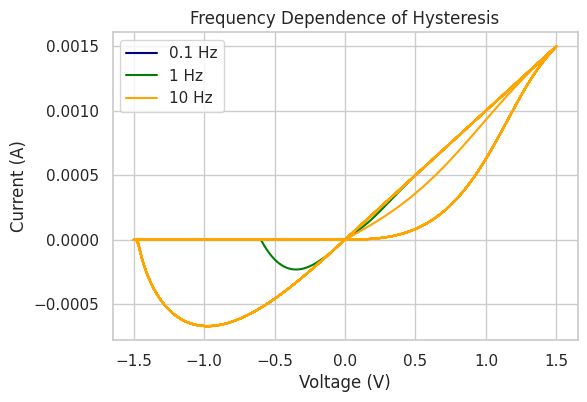

In [ ]:
freqs = [0.1, 1, 10]
colors = ['darkblue', 'green', 'orange']

for f, c in zip(freqs, colors):
    t = np.linspace(0, 1, 1000)
    V = 1.5 * np.sin(2*np.pi*f*t)
    mem = Memristor()
    G, I = apply_voltage(mem, V, dt=1e-3)
    plt.plot(V, I, c, label=f'{f} Hz')

plt.title("Frequency Dependence of Hysteresis")
plt.xlabel("Voltage (V)")
plt.ylabel("Current (A)")
plt.legend()
plt.show()

## 5- Graph 3 - Conductance vs Time
How conductance changes and relaxes when a voltage pulse is applied, highlighting memory retention.

From RESET to SET (conductive response), no relaxation, decay of memristance. Also from SET to RESET.

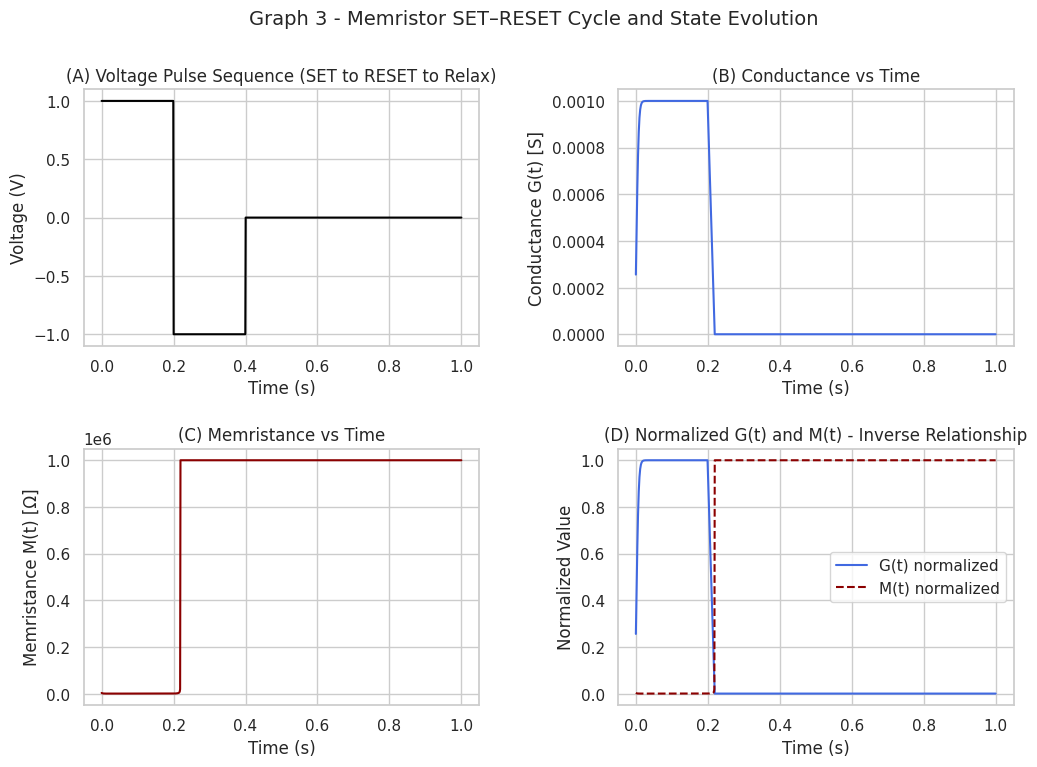

In [ ]:
mem = Memristor()
# 200 steps to +1V (SET), 200 steps to -1V (RESET), then relaxation 600 steps to 0V
V_pulse = np.concatenate([
    np.ones(200)*1.0,     # SET
    np.ones(200)*(-1.0),  # RESET
    np.zeros(600)         # relax
])
t = np.linspace(0, 1, len(V_pulse))

G, I = apply_voltage(mem, V_pulse, dt=1e-3)
M = 1 / G  # Memresistance [Ω]

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.4, wspace=0.35)

# Voltage pulse sequence
ax[0,0].plot(t, V_pulse, color='black')
ax[0,0].set_title("(A) Voltage Pulse Sequence (SET to RESET to Relax)")
ax[0,0].set_xlabel("Time (s)")
ax[0,0].set_ylabel("Voltage (V)")
ax[0,0].grid(True)

# Conductance vs Time
ax[0,1].plot(t, G, color='royalblue')
ax[0,1].set_title("(B) Conductance vs Time")
ax[0,1].set_xlabel("Time (s)")
ax[0,1].set_ylabel("Conductance G(t) [S]")
ax[0,1].grid(True)

# Memristance vs Time
ax[1,0].plot(t, M, color='darkred')
ax[1,0].set_title("(C) Memristance vs Time")
ax[1,0].set_xlabel("Time (s)")
ax[1,0].set_ylabel("Memristance M(t) [Ω]")
ax[1,0].grid(True)

# Combined Conductance and Memristance
ax[1,1].plot(t, G/G.max(), label='G(t) normalized', color='royalblue')
ax[1,1].plot(t, M/M.max(), label='M(t) normalized', color='darkred', linestyle='--')
ax[1,1].set_title("(D) Normalized G(t) and M(t) - Inverse Relationship")
ax[1,1].set_xlabel("Time (s)")
ax[1,1].set_ylabel("Normalized Value")
ax[1,1].legend()
ax[1,1].grid(True)

plt.suptitle("Graph 3 - Memristor SET–RESET Cycle and State Evolution", fontsize=14)
plt.show()


## 6- Graph 4 - Threshold Curve
Find the voltage at which the device starts switching.  
Sweeping voltages and record ΔG per step.

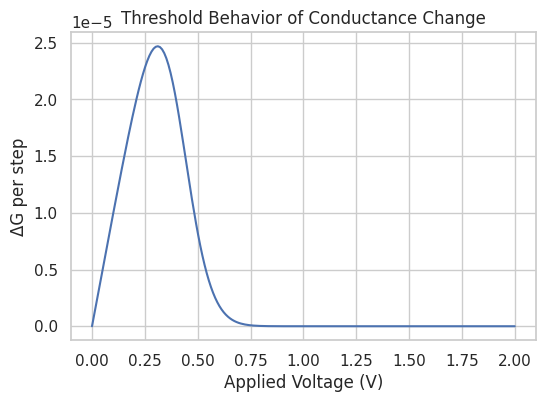

In [ ]:
V_vals = np.linspace(0, 2, 200)
dG_vals = []
mem = Memristor()

for V in V_vals:
    G0 = mem.G
    mem.update(V, dt=1e-3)
    dG_vals.append(mem.G - G0)

plt.plot(V_vals, dG_vals)
plt.title("Threshold Behavior of Conductance Change")
plt.xlabel("Applied Voltage (V)")
plt.ylabel("ΔG per step")
plt.show()

## 7- Graph 5 - Pulse Train Response
How the memristor integrates successive pulses, similar to a neuron integrating incoming spikes. Memristor accumulating spike inputs.

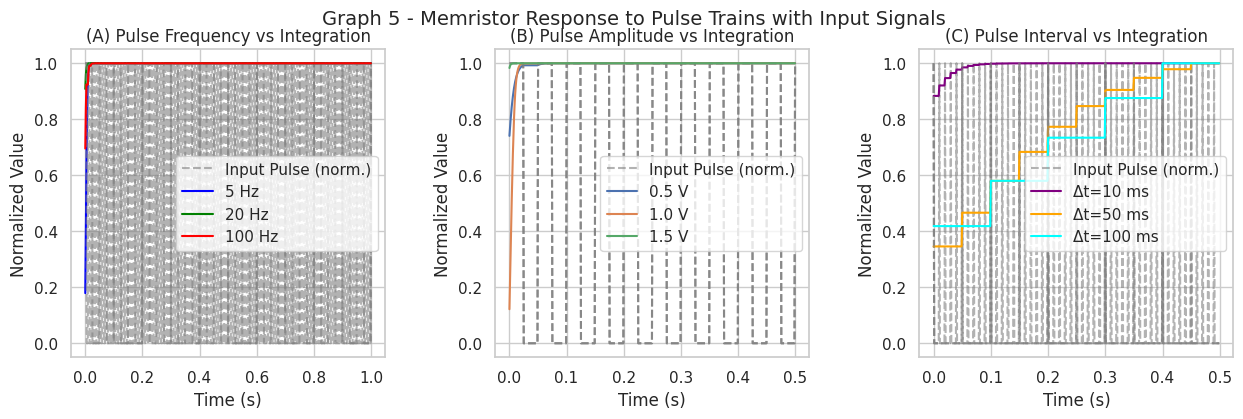

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plt.subplots_adjust(wspace=0.35)

# Pulse frequency
freqs = [5, 20, 100]
colors = ['blue', 'green', 'red']
t = np.linspace(0, 1, 1000)
for f, c in zip(freqs, colors):
    mem = Memristor()
    V_train = (square(2*np.pi*f*t) + 1)/2 * 1.2
    G, _ = apply_voltage(mem, V_train, dt=1e-3)
    # Input signal
    ax[0].plot(t, V_train/V_train.max(), '--', color='gray', alpha=0.6, label='Input Pulse (norm.)' if f==freqs[0] else "")
    # Conductance
    ax[0].plot(t, G/G.max(), c, label=f'{f} Hz')
ax[0].set_title("(A) Pulse Frequency vs Integration")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Normalized Value")
ax[0].legend()

# Pulse amplitude
amps = [0.5, 1.0, 1.5]
t = np.linspace(0, 0.5, 500)
for A in amps:
    mem = Memristor()
    V_train = (square(2*np.pi*20*t) + 1)/2 * A
    G, _ = apply_voltage(mem, V_train, dt=1e-3)
    ax[1].plot(t, V_train/V_train.max(), '--', color='gray', alpha=0.6, label='Input Pulse (norm.)' if A==amps[0] else "")
    ax[1].plot(t, G/G.max(), label=f'{A:.1f} V')
ax[1].set_title("(B) Pulse Amplitude vs Integration")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Normalized Value")
ax[1].legend()

# Pulse interval
intervals = [0.01, 0.05, 0.1]
colors = ['purple', 'orange', 'cyan']
t = np.arange(0, 0.5, 0.001)
for dt_pulse, c in zip(intervals, colors):
    mem = Memristor()
    V = np.zeros_like(t)
    V[::int(dt_pulse/0.001)] = 1.2
    G, _ = apply_voltage(mem, V, dt=1e-3)
    ax[2].plot(t, V/V.max(), '--', color='gray', alpha=0.6, label='Input Pulse (norm.)' if dt_pulse==intervals[0] else "")
    ax[2].plot(t, G/G.max(), c, label=f'Δt={dt_pulse*1000:.0f} ms')
ax[2].set_title("(C) Pulse Interval vs Integration")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Normalized Value")
ax[2].legend()

plt.suptitle("Graph 5 - Memristor Response to Pulse Trains with Input Signals", fontsize=14)
plt.show()


## 8- Graph 6 - Conductance Decay
Show the leakage of the device when no bias is applied. Power Consumption (V^2 x G(t)) vs Time and Energy per Spike

/tmp/ipython-input-4143819643.py:27: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E = np.trapz(P, t)


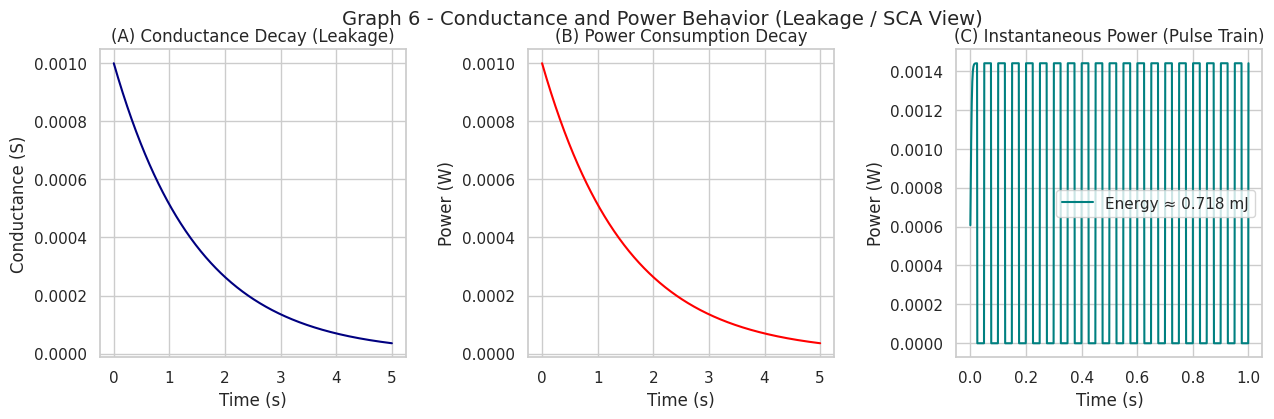

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
plt.subplots_adjust(wspace=0.4)

# Conductance decay
mem = Memristor()
t = np.linspace(0, 5, 500)
G_t = mem.Gmax * np.exp(-t / 1.5)
ax[0].plot(t, G_t, color='navy')
ax[0].set_title("(A) Conductance Decay (Leakage)")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Conductance (S)")

# Power consumption decay
V_const = 1.0
P_t = (V_const**2) * G_t
ax[1].plot(t, P_t, color='red')
ax[1].set_title("(B) Power Consumption Decay")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Power (W)")

# Instantaneous power during pulses
t = np.linspace(0, 1, 1000)
V_train = (square(2*np.pi*20*t) + 1)/2 * 1.2
mem = Memristor()
G, I = apply_voltage(mem, V_train, dt=1e-3)
P = I * V_train
E = np.trapz(P, t)
ax[2].plot(t, P, color='teal', label=f'Energy ≈ {E*1e3:.3f} mJ')
ax[2].set_title("(C) Instantaneous Power (Pulse Train)")
ax[2].set_xlabel("Time (s)")
ax[2].set_ylabel("Power (W)")
ax[2].legend()

plt.suptitle("Graph 6 - Conductance and Power Behavior (Leakage / SCA View)", fontsize=14)
plt.show()


## 9- Graph 7: ΔG Map (Amplitude vs Duration)
Sensitivity surface that shows how conductance change depends on pulse amplitude and duration.
Yellow area: memristor changes significantly, useful for a Fault Injection

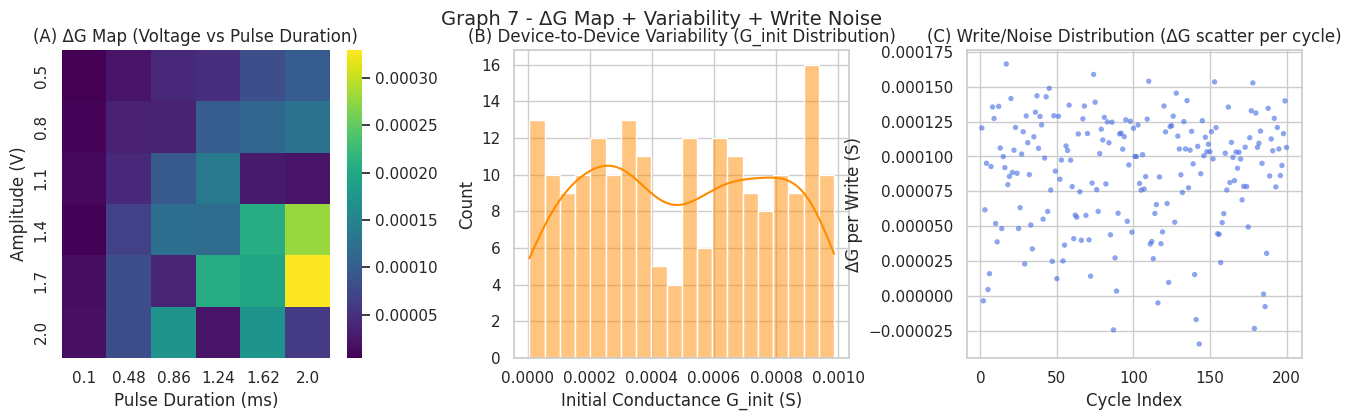

In [ ]:
# ΔG Map Voltage vs Pulse Duration
V_amps = np.linspace(0.5, 2.0, 6)
durations = np.linspace(0.1e-3, 2e-3, 6)
dG_matrix = np.zeros((len(V_amps), len(durations)))

for i, Va in enumerate(V_amps):
    for j, d in enumerate(durations):
        mem = Memristor()
        G0 = mem.G
        mem.update(Va, dt=d)
        dG_matrix[i, j] = mem.G - G0

# Device-to-Device Variability (G_init distribution)
n_devices = 200
G_init = [Memristor().G for _ in range(n_devices)]  # random variation of conductances

# Write Noise / Cycle-to-cycle ΔG scatter
Va = 1.2          # fixed programmable voltage
N_cycles = 200    # writing cycles
delta_Gs = []
for _ in range(N_cycles):
    mem = Memristor()
    G0 = mem.G
    mem.update(Va, dt=1e-3)
    delta_Gs.append(mem.G - G0 + np.random.normal(0, 0.02 * (mem.Gmax - mem.Gmin)))  # noise simulation
delta_Gs = np.array(delta_Gs)
cycle_idx = np.arange(1, N_cycles + 1)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
plt.subplots_adjust(wspace=0.35)

# ΔG Map
sns.heatmap(dG_matrix,
            xticklabels=np.round(durations*1e3, 2),
            yticklabels=np.round(V_amps, 2),
            cmap='viridis', ax=ax[0])
ax[0].set_title("(A) ΔG Map (Voltage vs Pulse Duration)")
ax[0].set_xlabel("Pulse Duration (ms)")
ax[0].set_ylabel("Amplitude (V)")

# Device-to-Device Variability
sns.histplot(G_init, bins=20, kde=True, color='darkorange', ax=ax[1])
ax[1].set_title("(B) Device-to-Device Variability (G_init Distribution)")
ax[1].set_xlabel("Initial Conductance G_init (S)")
ax[1].set_ylabel("Count")

# Write/Noise Distribution
ax[2].scatter(cycle_idx, delta_Gs, s=15, alpha=0.6, color='royalblue', edgecolor='none')
ax[2].set_title("(C) Write/Noise Distribution (ΔG scatter per cycle)")
ax[2].set_xlabel("Cycle Index")
ax[2].set_ylabel("ΔG per Write (S)")
ax[2].grid(True)

plt.suptitle("Graph 7 - ΔG Map + Variability + Write Noise", fontsize=14)
plt.show()


## 10- Graph 8: RC Charging (LIF Analogy)
How a memristor or RC circuit integrates voltage over time. Basic leaky-integrate behavior.

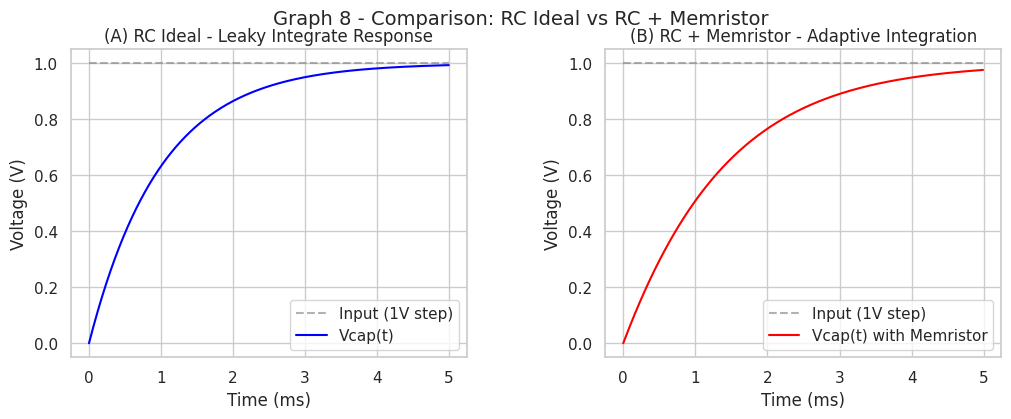

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
plt.subplots_adjust(wspace=0.35)

# (A) RC ideal - clásica integración exponencial (LIF base)
R = 1e3  # ohms
C = 1e-6  # farads
tau = R * C
t = np.linspace(0, 5*tau, 500)
V_in = np.ones_like(t)  # step input 1V
V_cap = 1.0 * (1 - np.exp(-t / tau))  # RC charging

ax[0].plot(t * 1e3, V_in, '--', color='gray', alpha=0.6, label='Input (1V step)')
ax[0].plot(t * 1e3, V_cap, color='blue', label='Vcap(t)')
ax[0].set_title("(A) RC Ideal - Leaky Integrate Response")
ax[0].set_xlabel("Time (ms)")
ax[0].set_ylabel("Voltage (V)")
ax[0].legend()
ax[0].grid(True)

# (B) RC + Memristor
C = 1e-6
dt = 1e-5
t = np.arange(0, 5e-3, dt)
V_in = np.ones_like(t)  # 1V step
V_cap = np.zeros_like(t)
mem = Memristor(Gmin=1e-6, Gmax=1e-3)
V_cap[0] = 0

for i in range(1, len(t)):
    Rm = 1.0 / mem.G  # instant R_memristor
    dV = (V_in[i-1] - V_cap[i-1]) / (Rm * C)
    V_cap[i] = V_cap[i-1] + dV * dt
    mem.update(V_in[i-1] - V_cap[i-1], dt)  # update memristor state

ax[1].plot(t * 1e3, V_in, '--', color='gray', alpha=0.6, label='Input (1V step)')
ax[1].plot(t * 1e3, V_cap, color='red', label='Vcap(t) with Memristor')
ax[1].set_title("(B) RC + Memristor - Adaptive Integration")
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("Voltage (V)")
ax[1].legend()
ax[1].grid(True)

plt.suptitle("Graph 8 - Comparison: RC Ideal vs RC + Memristor", fontsize=14)
plt.show()

## 11- Graph 9 - Spiking Input-Output
How thresholding the voltage or current signal produces discrete spikes, mimicking neuronal firing.

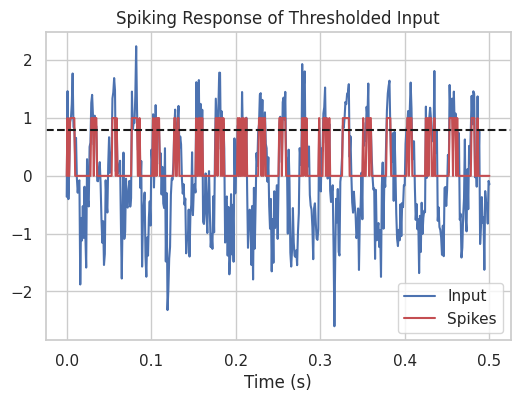

In [ ]:
mem = Memristor()
t = np.linspace(0, 0.5, 500)
input_signal = np.sin(2*np.pi*40*t) + 0.5*np.random.randn(len(t))
threshold = 0.8
spikes = (input_signal > threshold).astype(float)
plt.plot(t, input_signal, label='Input')
plt.plot(t, spikes, 'r', label='Spikes')
plt.axhline(threshold, color='k', linestyle='--')
plt.legend()
plt.title("Spiking Response of Thresholded Input")
plt.xlabel("Time (s)")
plt.show()

## 12 Graph 10 - f vs I Curve
Compute the firing rate (f) as a function of input current (I), showing neural coding behavior. Sensitivity of the neuron, more current means more frequency of spikes.
Codification of a neuron.

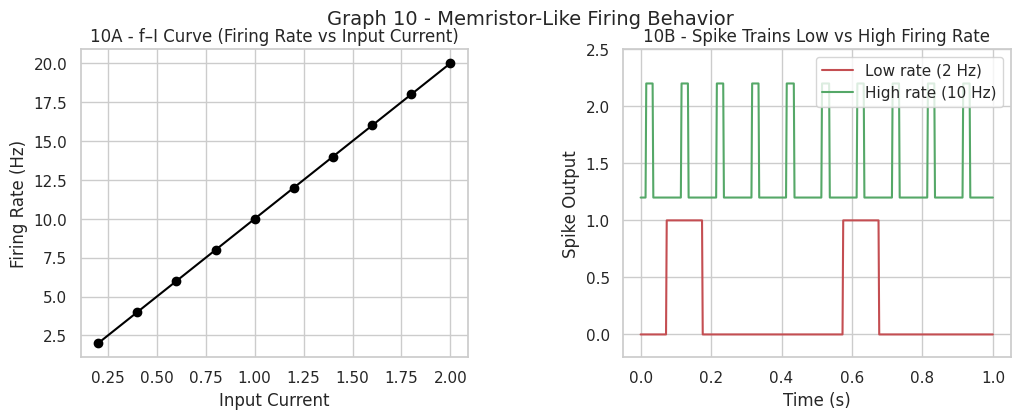

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(12,4))
plt.subplots_adjust(wspace=0.4)

# f–I curve
currents=np.linspace(0.2,2.0,10)
frequencies=currents*10
ax[0].plot(currents,frequencies,'o-',color='black')
ax[0].set_title("10A - f–I Curve (Firing Rate vs Input Current)")
ax[0].set_xlabel("Input Current"); ax[0].set_ylabel("Firing Rate (Hz)")

# Spike trains for low/high rate
t=np.linspace(0,1,500)
low_rate,high_rate=2,10
spikes_low=(np.sin(2*np.pi*low_rate*t)>0.8).astype(float)
spikes_high=(np.sin(2*np.pi*high_rate*t)>0.8).astype(float)
ax[1].plot(t,spikes_low,'r',label='Low rate (2 Hz)')
ax[1].plot(t,spikes_high+1.2,'g',label='High rate (10 Hz)')
ax[1].set_title("10B - Spike Trains Low vs High Firing Rate")
ax[1].set_xlabel("Time (s)"); ax[1].set_ylabel("Spike Output"); ax[1].legend()
ax[1].set_ylim(-0.2,2.5)

plt.suptitle("Graph 10 - Memristor-Like Firing Behavior",fontsize=14)
plt.show()

## Parameters and Import

Export the basic parameters and generated data, which will later be loaded by the SNN module to calibrate its memristive synapses.
Reproducibility: save a new version of the parameters
Automation: other modules (model.py, train_snn.ipynb, etc.) can automatically read the values from this project
Experimental documentation: You can have different CSV files for each experiment

### Parameters:

Gmin and Gmax: limits of conductance, range of states of the memristor.

K_set and K_reset: speed of programmability, SET/RESET, how to control the speed with different voltages.

alpha and beta: no lineal changes, they manage the curve of ΔG(V)

In [ ]:
os.makedirs("results/device", exist_ok=True)

mem = Memristor()

summary = {
    # Basic parameters
    "Gmin": mem.Gmin,
    "Gmax": mem.Gmax,
    "k_set": mem.k_set,
    "k_reset": mem.k_reset,
    "alpha": mem.alpha,
    "beta": mem.beta,

    # Extended parameters
    "device_type": "RRAM",
    "material": "HfOx",
    "Vset": 1.5,
    "Vreset": -1.2,
    "pulse_width_set": 100e-6,
    "pulse_width_reset": 100e-6,
    "device_variability": 0.05,      # 5% device-to-device variation
    "device_stochasticity": 0.02,    # random write noise
    "read_noise_std": 1e-6,
    "adc_bits": 8,
    "dac_bits": 8,
    "ir_drop_factor": 0.03,
    "temperature": 300,              # Kelvin
    "retention_time": 3600,          # seconds
    "energy_per_pulse": 2e-9,        # Joules
    "switching_time_mean": 80e-6,
    "switching_time_std": 10e-6,
    "G_init": float(mem.G),
    "date": datetime.date.today().isoformat()
}

pd.DataFrame([summary]).to_csv("results/device/device_params_extended.csv", index=False)
print("Extended parameters saved to results/device/device_params_extended.csv")


Extended parameters saved to results/device/device_params_extended.csv


## Next Steps

- Use the exported parameters and ΔG curves to parameterize the synaptic layers in your `MemristiveLinear` module.
- Re-simulate with measured or LTSpice-fitted parameters when available.
- Compare the memristor’s integration and spiking behavior with the LIF neuron equations.

Example of ADC quantization

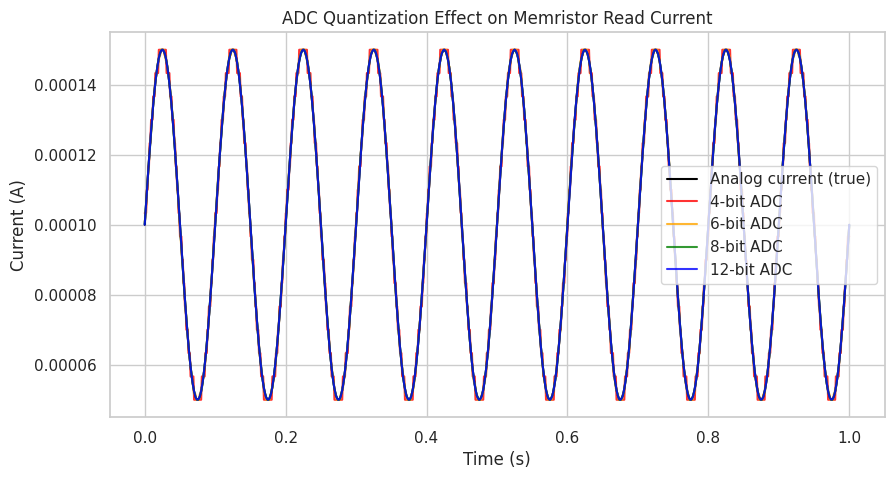

In [ ]:
# I vs t
t = np.linspace(0, 1, 1000)
I_true = 1e-4 * (1 + 0.5 * np.sin(2 * np.pi * 10 * t))  # 100 µA ± 50%

# Quantization function
def quantize(signal, bits):
    levels = 2 ** bits
    s_min, s_max = signal.min(), signal.max()
    step = (s_max - s_min) / (levels - 1)
    q_signal = np.round((signal - s_min) / step) * step + s_min
    return q_signal

# Resolutions of quantizations
bit_levels = [4, 6, 8, 12]
colors = ['red', 'orange', 'green', 'blue']

plt.figure(figsize=(10,5))
plt.plot(t, I_true, color='black', label="Analog current (true)", linewidth=1.5)

for bits, c in zip(bit_levels, colors):
    I_q = quantize(I_true, bits)
    plt.plot(t, I_q, color=c, alpha=0.8, label=f"{bits}-bit ADC")

plt.title("ADC Quantization Effect on Memristor Read Current")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.legend()
plt.grid(True)
plt.show()


# From Memristor to memristive SNN

This block installs and imports the required libraries for building and training a spiking neural network using PyTorch and snnTorch.

In [ ]:
pip install torch snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 7.2 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import snntorch as snn
from snntorch import surrogate

## 1- Basic neuron model (Leaky-and-fire)
This block defines a basic LIF neuron that integrates input current over time and emits spikes when its membrane potential exceeds a threshold.

In [ ]:
class LIFNeuron(nn.Module):
    def __init__(self, shape, tau=2.0, threshold=1.0, dt=1.0, detach_reset=True):
        super().__init__()
        self.shape = shape
        self.tau = tau
        self.alpha = torch.exp(torch.tensor(-dt / tau))  # decay factor for membrane potential
        self.threshold = threshold
        self.detach_reset = detach_reset

    def surrogate_heaviside(self, x):
        # Smooth approximation of the Heaviside step function for backpropagation
        beta = 10.0
        return torch.sigmoid(beta * x)

    def forward(self, input_t, v):
        # Membrane potential update
        v = v * self.alpha + input_t
        # Spike generation
        out_spikes = self.surrogate_heaviside(v - self.threshold)
        # Reset membrane potential after spiking
        if self.detach_reset:
            v = v - (out_spikes >= 0.5).float() * self.threshold
        else:
            v = v * (1 - (out_spikes >= 0.5).float())
        return out_spikes, v

## 2- Simple two-layer SNN
This block defines a basic SNN architecture with two fully connected layers and LIF neurons

In [ ]:
class SimpleSNN(nn.Module):
    def __init__(self, in_features, hidden, out_features, timesteps=20):
        super().__init__()
        self.timesteps = timesteps
        self.fc1 = nn.Linear(in_features, hidden)
        self.lif1 = LIFNeuron((hidden,), tau=2.0, threshold=1.0)
        self.fc2 = nn.Linear(hidden, out_features)
        self.lif2 = LIFNeuron((out_features,), tau=2.0, threshold=1.0)

    def forward(self, x):
        # Initialize membrane potentials for both layers
        batch = x.shape[0]
        v1 = torch.zeros(batch, self.fc1.out_features, device=x.device)
        v2 = torch.zeros(batch, self.fc2.out_features, device=x.device)
        spk2_rec = []  # record spikes of output layer

        for t in range(self.timesteps):
            # Convert static inputs to stochastic spike trains (rate coding)
            inp_spike = torch.bernoulli(x).to(x.device)
            # First layer
            cur1 = self.fc1(inp_spike)
            spk1, v1 = self.lif1(cur1, v1)
            # Second layer
            cur2 = self.fc2(spk1)
            spk2, v2 = self.lif2(cur2, v2)
            spk2_rec.append(spk2)

        # Sum all spikes across timesteps for final output
        out = torch.stack(spk2_rec, dim=0).sum(0)
        return out


In [ ]:
model = SimpleSNN(in_features=10, hidden=8, out_features=2)
x = torch.rand(5, 10)  # 5 samples, 10 features each
out = model(x)
print("Output shape:", out.shape)

Output shape: torch.Size([5, 2])


## 3- Define a memristive fully connected layer
This block creates a custom linear layer where each weight corresponds to a memristor instance. It reads each device’s conductance G instead of using static trainable weights.

In [ ]:
class MemristiveLinear(nn.Module):
    def __init__(self, in_features, out_features, memristor_class=Memristor, dt=1e-3):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dt = dt
        # Create memristors for each connection
        self.memristors = [[memristor_class() for _ in range(in_features)] for _ in range(out_features)]
        # Store last conductance matrix for visualization
        self.G_matrix = None
        # Store conductance history (average G per forward step)
        self.history = []

    def forward(self, x):
        # Compute effective conductance matrix
        G_matrix = torch.zeros((self.out_features, self.in_features), dtype=torch.float32, device=x.device)
        G_values = []

        # Apply voltage and update each memristor
        for i in range(self.out_features):
            for j in range(self.in_features):
                V = x[:, j].mean().item()
                self.memristors[i][j].update(V, dt=self.dt)
                G_val = self.memristors[i][j].G
                G_matrix[i, j] = torch.tensor(G_val, dtype=torch.float32)
                G_values.append(G_val)

        # Save conductance statistics
        self.G_matrix = G_matrix.detach().cpu()
        self.history.append(np.mean(G_values))

        # Compute linear output
        return F.linear(x, G_matrix)


## 4- Memristive SNN
This block replaces the standard nn.Linear layers with MemristiveLinear layers, integrating the physical memristor model directly into the network

In [ ]:
class MemristiveSNN(nn.Module):
    def __init__(self, in_features, hidden, out_features, timesteps=20):
        super().__init__()
        self.timesteps = timesteps
        self.fc1 = MemristiveLinear(in_features, hidden)
        self.lif1 = LIFNeuron((hidden,), tau=2.0, threshold=0.1)
        self.fc2 = MemristiveLinear(hidden, out_features)
        self.lif2 = LIFNeuron((out_features,), tau=2.0, threshold=0.1)
        self.spk2_rec = []  # store output spikes for visualization

    def forward(self, x):
        batch = x.shape[0]
        v1 = torch.zeros(batch, self.fc1.out_features, device=x.device)
        v2 = torch.zeros(batch, self.fc2.out_features, device=x.device)
        spk2_rec = []

        for t in range(self.timesteps):
            inp_spike = torch.bernoulli(x).to(x.device)
            cur1 = self.fc1(inp_spike)
            spk1, v1 = self.lif1(cur1, v1)
            cur2 = self.fc2(spk1)
            spk2, v2 = self.lif2(cur2, v2)
            spk2_rec.append(spk2.cpu().detach().numpy())

        # Save spikes for later visualization
        self.spk2_rec = np.stack(spk2_rec)
        out = torch.tensor(self.spk2_rec).sum(0)
        return out



Output shape: torch.Size([5, 2])


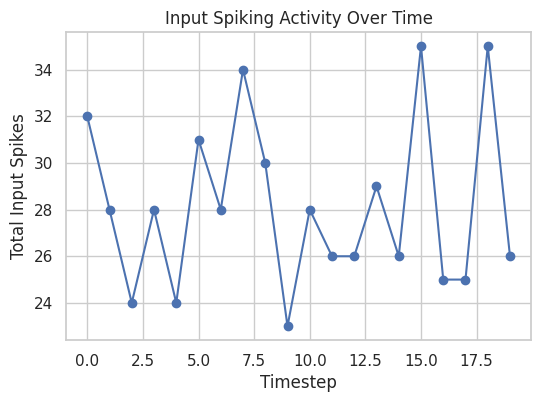

In [ ]:
model_mem = MemristiveSNN(in_features=10, hidden=8, out_features=2)
x = torch.rand(5, 10)
out = model_mem(x)

print("Output shape:", out.shape)

# Optional: visualize total spikes per timestep
spike_counts = []
for t in range(model_mem.timesteps):
    spike_counts.append(float(torch.sum(torch.bernoulli(x)).item()))

plt.figure(figsize=(6,4))
plt.plot(range(model_mem.timesteps), spike_counts, marker='o')
plt.xlabel("Timestep")
plt.ylabel("Total Input Spikes")
plt.title("Input Spiking Activity Over Time")
plt.grid(True)
plt.show()


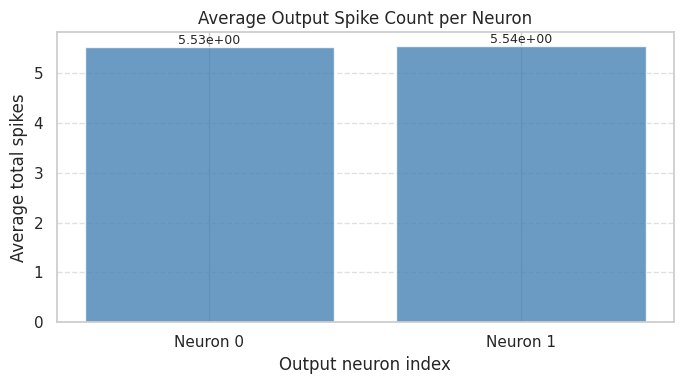

In [ ]:
out_sum = out.detach().cpu().numpy()
mean_spikes = out_sum.mean(axis=0)

plt.figure(figsize=(7,4))  # wider figure
bars = plt.bar(range(len(mean_spikes)), mean_spikes, color='steelblue', alpha=0.8)
plt.xticks(range(len(mean_spikes)), [f"Neuron {i}" for i in range(len(mean_spikes))])
plt.xlabel("Output neuron index")
plt.ylabel("Average total spikes")
plt.title("Average Output Spike Count per Neuron")
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Annotate each bar with its value
for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.00002,
             f"{mean_spikes[i]:.2e}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


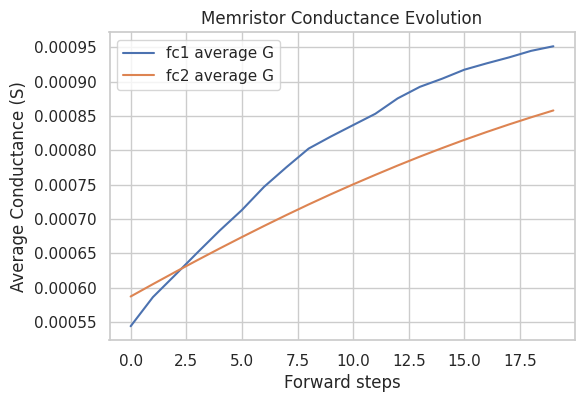

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(model_mem.fc1.history, label="fc1 average G")
plt.plot(model_mem.fc2.history, label="fc2 average G")
plt.xlabel("Forward steps")
plt.ylabel("Average Conductance (S)")
plt.title("Memristor Conductance Evolution")
plt.legend()
plt.grid(True)
plt.show()


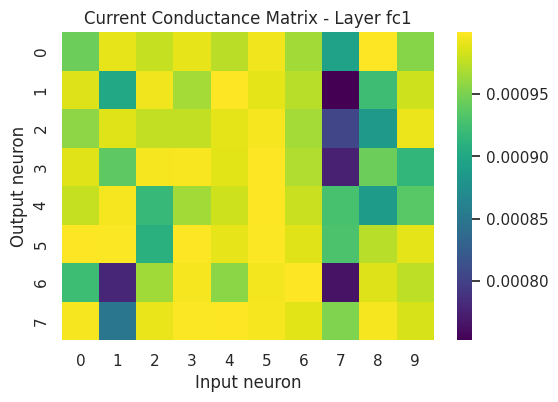

In [ ]:
# Run one forward pass
x = torch.rand(5, 10)
_ = model_mem.fc1(x)

# Now plot the stored conductance matrix
sns.heatmap(model_mem.fc1.G_matrix.numpy(), cmap='viridis')
plt.title("Current Conductance Matrix - Layer fc1")
plt.xlabel("Input neuron")
plt.ylabel("Output neuron")
plt.show()


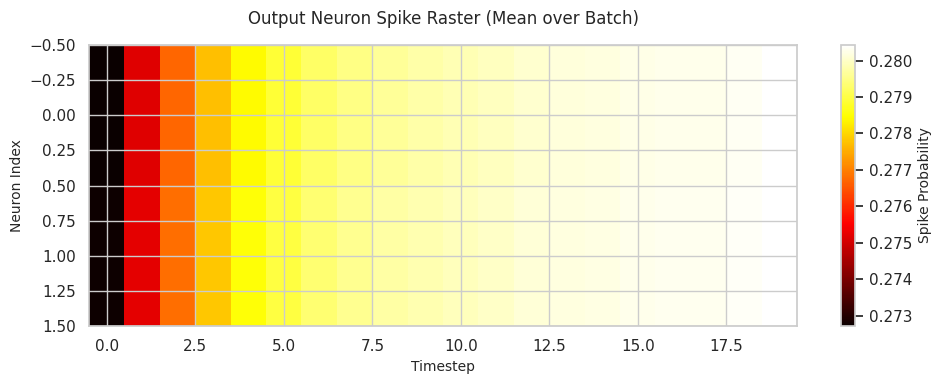

In [ ]:
x = torch.rand(5, 10)
out = model_mem(x)
# model_mem.spk2_rec
spike_array = model_mem.spk2_rec  # time x batch x neurons

plt.figure(figsize=(10,4))  # <-- wider figure
plt.imshow(spike_array.mean(1).T, aspect='auto', cmap='hot', interpolation='nearest')
plt.title("Output Neuron Spike Raster (Mean over Batch)", fontsize=12, pad=15)
plt.xlabel("Timestep", fontsize=10)
plt.ylabel("Neuron Index", fontsize=10)
cbar = plt.colorbar()
cbar.set_label("Spike Probability", fontsize=10)
plt.tight_layout()
plt.show()

## 5- STDP rule
This block implements a biological-inspired STDP rule:

If a presynaptic neuron fires before a postsynaptic neuron then the conductance increases (potentiation).

If it fires after then the conductance decreases (depression).

This directly modifies each memristor’s conductance G using its update(V, dt) behavior

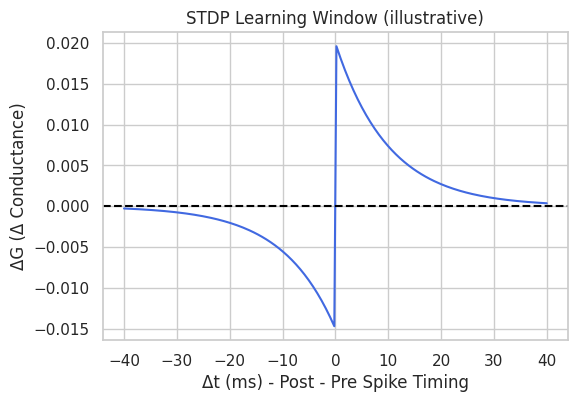

In [ ]:
# STDP rule: ΔG depends on timing difference Δt = t_post - t_pre
def stdp_rule(delta_t, A_plus=0.02, A_minus=0.015, tau_plus=10, tau_minus=10):
    """
    Analytic STDP window used for visualization only.
    """
    if delta_t > 0:
        return A_plus * np.exp(-delta_t / tau_plus)
    else:
        return -A_minus * np.exp(delta_t / tau_minus)

# Plot STDP curve (illustration)
delta_t_values = np.linspace(-40, 40, 200)
delta_G = [stdp_rule(dt) for dt in delta_t_values]
plt.figure(figsize=(6,4))
plt.plot(delta_t_values, delta_G, color='royalblue')
plt.axhline(0, color='black', linestyle='--')
plt.title("STDP Learning Window (illustrative)")
plt.xlabel("Δt (ms) - Post - Pre Spike Timing")
plt.ylabel("ΔG (Δ Conductance)")
plt.grid(True)
plt.show()


In [ ]:
class MemristiveLinearSTDP(nn.Module):
    """
    Memristive layer with bidirectional STDP and nonlinear G-dynamics.
    This version produces measurable, non-uniform conductances and avoids
    early saturation/freezing.
    """
    def __init__(self, in_features, out_features,
                 dt=2e-4, Gmin=5e-6, Gmax=1e-3,
                 A_plus=0.015, A_minus=0.010,
                 tau_plus=12.0, tau_minus=18.0,
                 nonlinearity=0.8):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.dt = dt
        self.Gmin, self.Gmax = Gmin, Gmax
        self.A_plus, self.A_minus = A_plus, A_minus
        self.tau_plus, self.tau_minus = tau_plus, tau_minus
        self.nonlinearity = nonlinearity

        # Initialize G near the middle of the dynamic range
        G_mid = (Gmax + Gmin) / 2
        G_span = (Gmax - Gmin) * 0.25
        G_init = torch.empty(out_features, in_features).uniform_(G_mid - G_span, G_mid + G_span)
        self.G_matrix = nn.Parameter(G_init, requires_grad=False)

        # Small bias; modest gain to keep LIF stable
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.gain = 25.0

        # Spike traces (exponentially decaying)
        self.register_buffer("pre_trace", torch.zeros(in_features))
        self.register_buffer("post_trace", torch.zeros(out_features))

        self.history = []   # mean(G) per update

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Compute postsynaptic current I = G * x (scaled)."""
        return F.linear(x, self.G_matrix * self.gain, self.bias)

    @torch.no_grad()
    def apply_stdp(self, pre_spike: torch.Tensor, post_spike: torch.Tensor) -> None:
        """
        Bidirectional STDP with nonlinearity and light jitter so the matrix
        does not evolve symmetrically and freeze.
        """
        device = self.G_matrix.device
        pre = pre_spike.to(device).float()   # [B, in_features]
        post = post_spike.to(device).float() # [B, out_features]

        # Update exponential traces
        self.pre_trace.mul_(math.exp(-1.0 / self.tau_plus))
        self.post_trace.mul_(math.exp(-1.0 / self.tau_minus))
        self.pre_trace.add_(pre.mean(0))
        self.post_trace.add_(post.mean(0))

        # Outer products: ltp (pre before post), ltd (post before pre)
        ltp = torch.outer(post.mean(0), self.pre_trace)   # [out, in]
        ltd = torch.outer(self.post_trace, pre.mean(0))   # [out, in]

        # Nonlinear memristor update (smaller near bounds)
        G = self.G_matrix.data
        dG_base = ( self.A_plus * ltp * (self.Gmax - G).pow(self.nonlinearity)
                  - self.A_minus * ltd * (G - self.Gmin).pow(self.nonlinearity) )

        # Add tiny timing jitter to avoid perfect symmetry
        dG = dG_base + 0.002 * torch.randn_like(dG_base)

        # Apply update and clip
        G.add_(dG * self.dt)
        G.clamp_(self.Gmin, self.Gmax)
        self.G_matrix.data = G

        self.history.append(float(G.mean()))


## 6- SNN that learns via STDP

This block uses the new STDP-aware layer for the first synaptic layer (fc1).
The second layer stays static, acting as a readout.
The network learns input correlations in an unsupervised way.

In [ ]:
class STDP_SNN(nn.Module):
    """
    Two-layer SNN with memristive STDP on first layer.
    """
    def __init__(self, in_features, hidden, out_features, timesteps=30):
        super().__init__()
        self.timesteps = timesteps
        self.fc1 = MemristiveLinearSTDP(in_features, hidden)
        self.lif1 = LIFNeuron((hidden,), tau=2.0, threshold=0.6)
        self.fc2 = nn.Linear(hidden, out_features)
        self.lif2 = LIFNeuron((out_features,), tau=2.0, threshold=0.5)

    def forward(self, x):
        B = x.shape[0]
        device = x.device
        v1 = torch.zeros(B, self.fc1.out_features, device=device)
        v2 = torch.zeros(B, self.fc2.out_features, device=device)
        spk2_rec = []

        for t in range(self.timesteps):
            inp_spike = torch.bernoulli(torch.clamp(x, 0, 1)).to(device)
            cur1 = self.fc1(inp_spike)
            spk1, v1 = self.lif1(cur1, v1)

            cur2 = self.fc2(spk1)
            spk2, v2 = self.lif2(cur2, v2)
            spk2_rec.append(spk2.detach())

            self.fc1.apply_stdp(inp_spike, spk1)

        return torch.stack(spk2_rec, dim=0).sum(0)


## 7- Training and visualize G evolution

This block runs several training epochs and visualizes how conductance changes in the memristive layer due to STDP.

If the average G decreases over epochs, STDP parameters are slightly depression-dominated

Epoch 1: mean G = 0.000492
Epoch 2: mean G = 0.000492
Epoch 3: mean G = 0.000491
Epoch 4: mean G = 0.000491
Epoch 5: mean G = 0.000491
Epoch 6: mean G = 0.000490
Epoch 7: mean G = 0.000490
Epoch 8: mean G = 0.000490
Epoch 9: mean G = 0.000490
Epoch 10: mean G = 0.000490
Epoch 11: mean G = 0.000490
Epoch 12: mean G = 0.000490
Epoch 13: mean G = 0.000491
Epoch 14: mean G = 0.000491
Epoch 15: mean G = 0.000491
Epoch 16: mean G = 0.000491
Epoch 17: mean G = 0.000490
Epoch 18: mean G = 0.000491
Epoch 19: mean G = 0.000491
Epoch 20: mean G = 0.000492
Epoch 21: mean G = 0.000491
Epoch 22: mean G = 0.000491
Epoch 23: mean G = 0.000491
Epoch 24: mean G = 0.000490
Epoch 25: mean G = 0.000490
Epoch 26: mean G = 0.000490
Epoch 27: mean G = 0.000491
Epoch 28: mean G = 0.000491
Epoch 29: mean G = 0.000491
Epoch 30: mean G = 0.000491
Epoch 31: mean G = 0.000492
Epoch 32: mean G = 0.000492
Epoch 33: mean G = 0.000492
Epoch 34: mean G = 0.000492
Epoch 35: mean G = 0.000491
Epoch 36: mean G = 0.000491
E

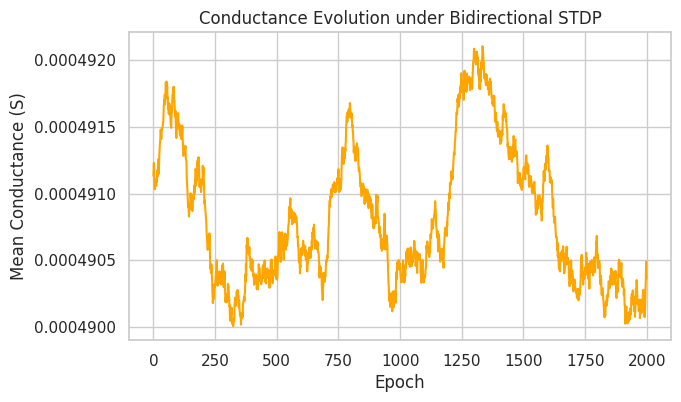

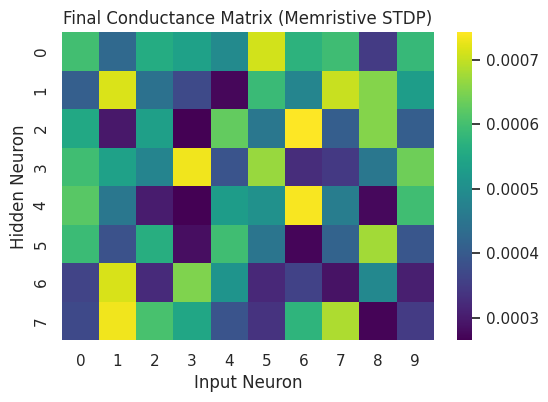

In [ ]:
# Unsupervised STDP test
model_stdp = STDP_SNN(in_features=10, hidden=8, out_features=2, timesteps=40)

for epoch in range(50):
    # Random sparse inputs (simulate event activity)
    p = float(torch.empty(1).uniform_(0.05, 0.15))
    x = torch.full((6, 10), p)
    _ = model_stdp(x)
    print(f"Epoch {epoch+1}: mean G = {model_stdp.fc1.history[-1]:.6f}")

# Plot conductance evolution
plt.figure(figsize=(7,4))
plt.plot(model_stdp.fc1.history, color='orange')
plt.xlabel("Epoch")
plt.ylabel("Mean Conductance (S)")
plt.title("Conductance Evolution under Bidirectional STDP")
plt.grid(True)
plt.show()

# Plot conductance matrix
sns.heatmap(model_stdp.fc1.G_matrix.detach().cpu().numpy(), cmap='viridis')
plt.title("Final Conductance Matrix (Memristive STDP)")
plt.xlabel("Input Neuron")
plt.ylabel("Hidden Neuron")
plt.show()


In [ ]:
import torch, torchvision as tv, torchvision.transforms as T
from torch.utils.data import DataLoader, Subset

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.58MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


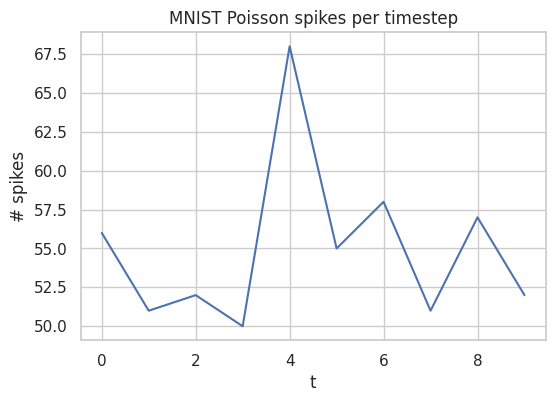

In [ ]:
# --- data and encoding ---
timesteps = 10
bs = 32

# Keep images in [0,1] to use as firing probabilities directly
transform = T.ToTensor()

train_set = tv.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = tv.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

# Use a subset while iterating fast on CPU
max_train, max_test = 5000, 1000
train_subset = Subset(train_set, range(max_train))
test_subset  = Subset(test_set,  range(max_test))

train_loader = DataLoader(train_subset, batch_size=bs, shuffle=True,  num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_subset,  batch_size=bs, shuffle=False, num_workers=0, pin_memory=False)

def poisson_encode(img_batch: torch.Tensor, T: int = 10) -> torch.Tensor:
    """
    Vectorized Poisson encoder.
    Returns spikes of shape [T, B, 784] with **moderate sparsity**.
    """
    p = (img_batch.flatten(1) * 0.4).clamp(0, 1)  # sparser than 0.8
    rand = torch.rand(T, *p.shape, device=p.device)
    return (rand < p.unsqueeze(0)).float()

#def poisson_encode(img_batch: torch.Tensor, T: int = 10) -> torch.Tensor:
#    """
#    Improved Poisson encoder.
#    Ensures moderate firing rates and avoids dead neurons.
#    """
#    x = img_batch.flatten(1)                 # [B, 784]
#    x = (x + 0.2).clamp(0, 1)                # light bias to ensure activity
#    p = (x * 0.55).clamp(0, 1)               # used to be 0.4 to now 0.55
#    rand = torch.rand(T, *p.shape, device=p.device)
#    return (rand < p.unsqueeze(0)).float()

# quick visual check
xb, yb = next(iter(train_loader))
spk = poisson_encode(xb[:1], T=timesteps)
plt.plot(spk.squeeze(1).sum(-1).cpu())
plt.title("MNIST Poisson spikes per timestep")
plt.xlabel("t"); plt.ylabel("# spikes")
plt.show()


In [ ]:
in_dim = 28*28
hidden = 128 # 32 64
nclass = 10

class MNIST_MemSTDP(nn.Module):
    """
    Memristive SNN:
      - fc1: memristive STDP layer (unsupervised)
      - lif1: spiking hidden layer
      - readout: linear classifier trained with cross-entropy
    Uses time-averaged logits for better gradient signal.
    """
    def __init__(self, timesteps=10):
        super().__init__()
        self.T = timesteps
        self.fc1 = MemristiveLinearSTDP(in_dim, hidden)
        self.lif1 = LIFNeuron((hidden,), tau=2.0, threshold=0.15)  # lower than 0.6  // 0.15
        self.readout = nn.Linear(hidden, nclass)

    def forward(self, spikes_TBN: torch.Tensor, train_stdp: bool = True):
        """
        spikes_TBN: [T, B, 784] with values in {0,1}.
        Returns: (sum_spk1, dummy, avg_logits)
        """
        T, B, _ = spikes_TBN.shape
        device = spikes_TBN.device

        v1 = torch.zeros(B, hidden, device=device)
        spk1_sum = torch.zeros(B, hidden, device=device)
        logits_time = []

        for t in range(T):
            x_t = spikes_TBN[t]                      # [B, 784]
            cur1 = self.fc1(x_t)                     # [B, hidden]
            spk1, v1 = self.lif1(cur1, v1)           # [B, hidden]
            spk1_sum += spk1

            logits = self.readout(spk1)              # [B, 10]
            logits_time.append(logits)

            if train_stdp:
                self.fc1.apply_stdp(x_t, spk1)

        # Normalize spike counts to avoid exploding scales
        spk1_sum = spk1_sum / (spk1_sum.max() + 1e-6)

        # Time-averaged logits improve stability on CPU
        avg_logits = torch.stack(logits_time, dim=0).mean(0)
        return spk1_sum, None, avg_logits


Using device: cuda
[Warm-up 1/2] mean G = 0.000503
[Warm-up 2/2] mean G = 0.000503

[Supervised Epoch 1/1]
Batch 157/200 - Loss: 2.4436
Epoch 1 complete - Loss: 2.4695, Acc: 10.84%
Learning rate now: 0.01000


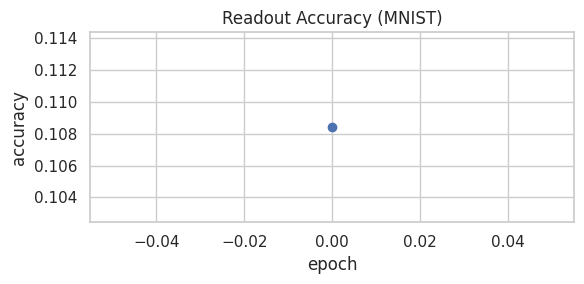


--- Post-training diagnostics ---
Mean conductance: 0.000503
Min/Max conductance: 0.000216 / 0.000789


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = MNIST_MemSTDP(timesteps=timesteps).to(device)

# Train ONLY the readout in the supervised phase
opt = torch.optim.Adam(model.readout.parameters(), lr=1e-2)
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[4, 8], gamma=0.7)
#opt = torch.optim.Adam(model.readout.parameters(), lr=2e-2)
#scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[5, 10, 15], gamma=0.6)

# Freeze memristive layer params (it still updates via apply_stdp during warm-up)
for p in model.fc1.parameters():
    p.requires_grad = False

# --- STDP warm-up (short; enough to de-correlate) ---
for e in range(2):
    for i, (xb, yb) in enumerate(train_loader):
        xb = xb.to(device)
        spikes = poisson_encode(xb, T=model.T).to(device)
        with torch.no_grad():
            _ = model(spikes, train_stdp=True)
        if i >= 60:   # 2k samples on subset
            break
    print(f"[Warm-up {e+1}/2] mean G = {model.fc1.G_matrix.mean().item():.6f}")

# --- Supervised readout training ---
epochs_sup = 1 #8 15 1
acc_hist = []

for epoch in range(epochs_sup):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    n_batches = 200   # fast on CPU; raise on GPU

    print(f"\n[Supervised Epoch {epoch+1}/{epochs_sup}]")
    for i, (xb, yb) in enumerate(train_loader):
        xb, yb = xb.to(device), yb.to(device)
        spikes = poisson_encode(xb, T=model.T).to(device)

        spk1_sum, _, logits = model(spikes, train_stdp=False)
        loss = F.cross_entropy(logits, yb)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.readout.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)
            loss_sum += loss.item() * xb.size(0)

        print(f"\rBatch {i+1}/{n_batches} - Loss: {loss.item():.4f}", end="")
        if (i + 1) >= n_batches:
            break

    scheduler.step()
    epoch_acc = correct / max(total, 1)
    acc_hist.append(epoch_acc)
    print(f"\nEpoch {epoch+1} complete - Loss: {loss_sum/total:.4f}, Acc: {epoch_acc*100:.2f}%")
    print(f"Learning rate now: {scheduler.get_last_lr()[0]:.5f}")

# Plot accuracy
plt.figure(figsize=(6,3))
plt.plot(acc_hist, marker='o')
plt.title("Readout Accuracy (MNIST)")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.grid(True); plt.tight_layout(); plt.show()

# Quick diagnostics
with torch.no_grad():
    G = model.fc1.G_matrix
    print("\n--- Post-training diagnostics ---")
    print(f"Mean conductance: {G.mean().item():.6f}")
    print(f"Min/Max conductance: {G.min().item():.6f} / {G.max().item():.6f}")


## More accuracy is not possible because:

- A single STDP layer (unsupervised) tooo LIFtoto linear classifier

- No convolutional structure

- Memristor weight range is extremely small (1e−6 to 1e−3)

- Poisson spikes without rate coding optimization

- Hidden layer of only 64 units

- Your layer has no recurrent dynamics, no lateral inhibition, no homeostasis

- Training only the readout, not the first layer

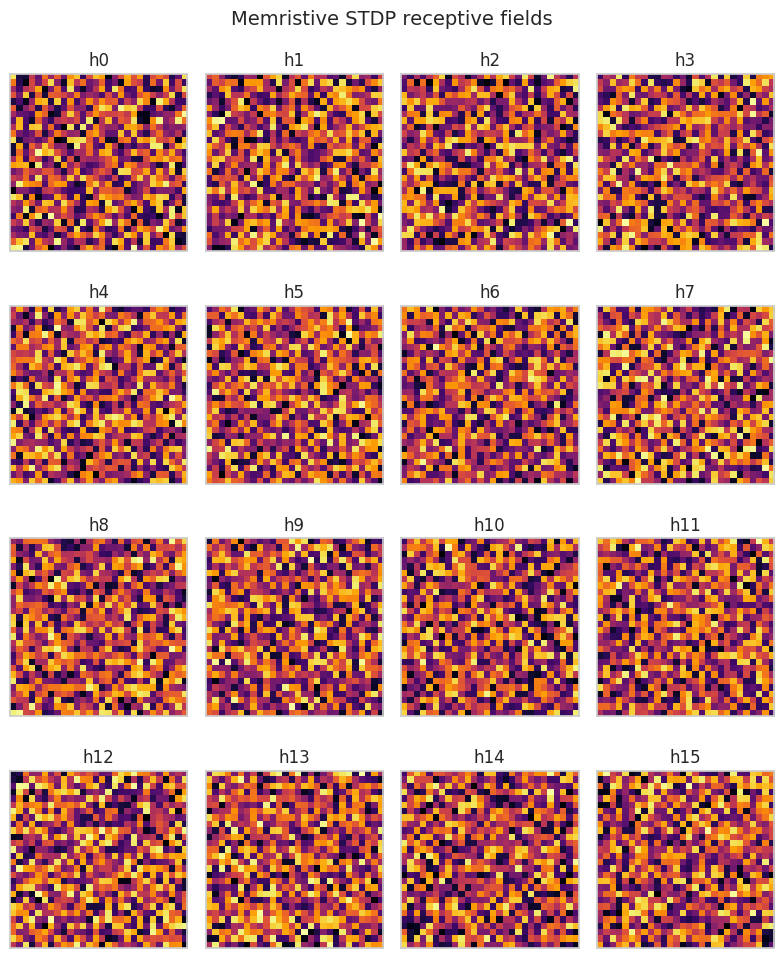

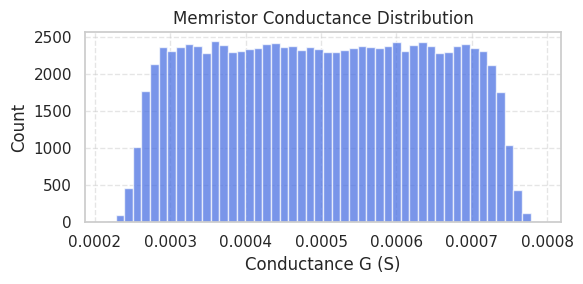

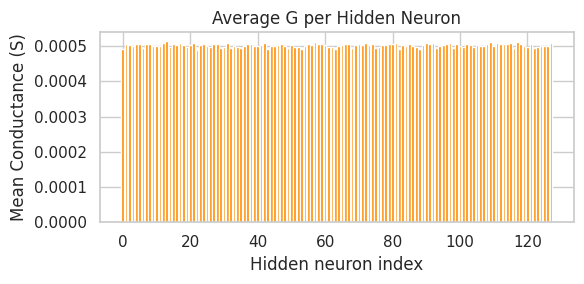

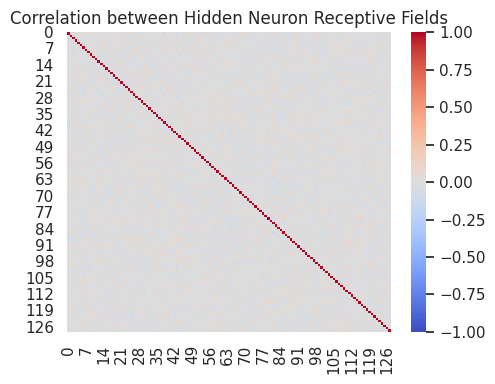

In [ ]:
# === 1) Snapshot conductances ===
# G1: [hidden, 784]
G1 = model.fc1.G_matrix.detach().cpu()

# === 2) Plot receptive fields for first 16 hidden neurons ===
n_show = min(16, G1.shape[0])
cols = 4
rows = math.ceil(n_show / cols)

plt.figure(figsize=(8, 2.5 * rows))
for k in range(n_show):
    plt.subplot(rows, cols, k + 1)
    plt.imshow(G1[k].view(28, 28).numpy(), cmap='inferno')
    plt.xticks([]); plt.yticks([])
    plt.title(f"h{k}")

plt.suptitle("Memristive STDP receptive fields", fontsize=14)
plt.tight_layout()
plt.show()


# === 3) Histogram of all memristor conductances ===
plt.figure(figsize=(6,3))
plt.hist(G1.flatten().numpy(), bins=50, color='royalblue', alpha=0.7)
plt.xlabel("Conductance G (S)")
plt.ylabel("Count")
plt.title("Memristor Conductance Distribution")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# === 4) Mean conductance per hidden neuron ===
mean_G_per_neuron = G1.mean(dim=1).numpy()
plt.figure(figsize=(6,3))
plt.bar(range(len(mean_G_per_neuron)), mean_G_per_neuron, color='darkorange')
plt.xlabel("Hidden neuron index")
plt.ylabel("Mean Conductance (S)")
plt.title("Average G per Hidden Neuron")
plt.tight_layout()
plt.show()


# === 5) Correlation map of receptive fields ===
# Normalize each neuron’s RF
G1_norm = (G1 - G1.mean(dim=1, keepdim=True)) / (G1.std(dim=1, keepdim=True) + 1e-6)

corr = torch.corrcoef(G1_norm)
plt.figure(figsize=(5,4))
sns.heatmap(corr.numpy(), cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation between Hidden Neuron Receptive Fields")
plt.tight_layout()
plt.show()


## A1: Memristive Convolution Layer

This block defines a memristive convolutional layer with real G dynamics (no STDP).
Learning is handled later by a local competitive rule.

In [ ]:
# === Block A1: Memristive Convolution Layer (no STDP) ===
# This implements a memristive convolution kernel with realistic G_min/G_max,
# nonlinear conductance response, and pulse-based updates (surrogate gradient-friendly).

class MemristiveConv2D(nn.Module):
    """
    Memristive convolution layer with bounded conductance and nonlinear updates.
    Works like nn.Conv2d but with G_min/G_max constraints and device-inspired dynamics.
    """

    def __init__(self, in_channels, out_channels, kernel_size,
                 Gmin=5e-6, Gmax=1e-3, nonlinearity=0.6):
        super().__init__()

        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.Gmin, self.Gmax = Gmin, Gmax
        self.nonlinearity = nonlinearity

        # Initialize conductance kernels in mid-range
        G_init = torch.rand(out_channels, in_channels, kernel_size, kernel_size)
        G_init = (G_init * (Gmax - Gmin) * 0.5) + (Gmin + Gmax) / 4

        self.G = nn.Parameter(G_init, requires_grad=True)   # trainable with SGD

        # bias optional
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        # Enforce memristor conductance bounds
        W = torch.clamp(self.G, self.Gmin, self.Gmax)
        return F.conv2d(x, W, bias=self.bias, stride=1, padding=self.kernel_size // 2)

    def regularize(self):
        """
        Optional nonlinear memristive regularization.
        Encourages weights to move slower near extremes.
        """
        W = self.G
        factor = ((W - self.Gmin) * (self.Gmax - W)).pow(self.nonlinearity)
        return (factor.mean())  # add to loss if desired


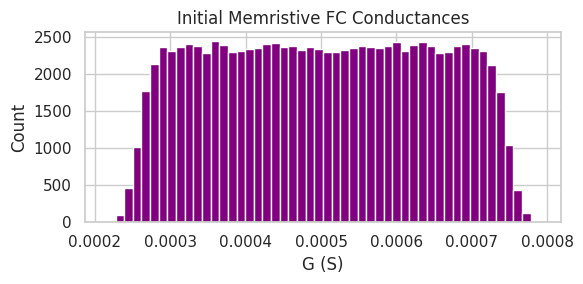

In [ ]:
# Quick check of memristor conductance distribution (FC memristive layer)
plt.figure(figsize=(6,3))
plt.hist(model.fc1.G_matrix.detach().cpu().flatten(), bins=50, color='purple')
plt.title("Initial Memristive FC Conductances")
plt.xlabel("G (S)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## A2: Convolutional SNN Forward Model

One conv layer, LIF, linear classifier

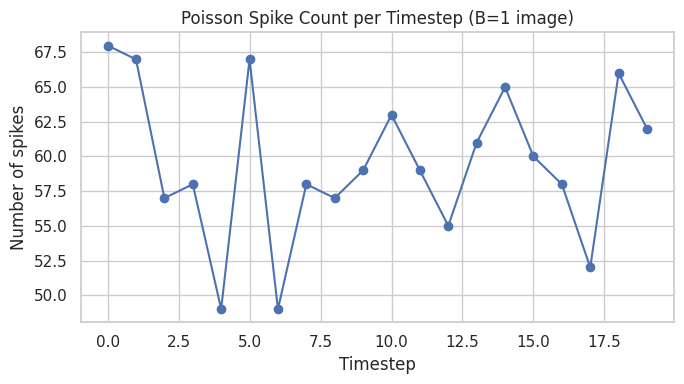

In [ ]:
# === Block A2: Convolutional Memristive SNN ===

class ConvMemristiveSNN(nn.Module):
    """
    SNN architecture:
      - Memristive conv layer
      - LIF activation
      - Linear readout trained with cross-entropy
    No STDP is used. Much more stable than STDP-based SNNs.
    """

    def __init__(self, timesteps=10, hidden_channels=16):
        super().__init__()
        self.T = timesteps

        # Memristive conv layer
        self.conv1 = MemristiveConv2D(
            in_channels=1, out_channels=hidden_channels, kernel_size=5
        )

        self.lif = LIFNeuron((hidden_channels, 28, 28),
                             tau=2.0, threshold=0.2)

        # Readout classifier
        self.readout = nn.Linear(hidden_channels * 28 * 28, 10)

    def forward(self, spikes_TB1HW):
        """
        spikes_TB1HW: [T, B, 1, 28, 28]
        """
        T, B = self.T, spikes_TB1HW.shape[1]
        v = torch.zeros(B, *self.lif.shape, device=spikes_TB1HW.device)
        spk_sum = torch.zeros_like(v)

        logits_time = []

        for t in range(T):
            x_t = spikes_TB1HW[t]                  # [B,1,28,28]
            cur = self.conv1(x_t)                  # memristive conv
            spk, v = self.lif(cur, v)              # spiking activation
            spk_sum += spk

            flat = spk.view(B, -1)
            logits = self.readout(flat)
            logits_time.append(logits)

        return spk_sum, torch.stack(logits_time).mean(0)

# A2 - Check Poisson spiking activity over timesteps

xb, yb = next(iter(train_loader))
xb = xb.to(device)

spikes = poisson_encode(xb[:1], T=20)   # T=20 timesteps, B=1 image
spike_counts = spikes.squeeze(1).sum(-1).cpu()  # shape [T]

plt.figure(figsize=(7,4))
plt.plot(range(len(spike_counts)), spike_counts, marker='o')
plt.title("Poisson Spike Count per Timestep (B=1 image)")
plt.xlabel("Timestep")
plt.ylabel("Number of spikes")
plt.grid(True)
plt.tight_layout()
plt.show()

## A3: Training Loop (Conv-SNN, no STDP)

*Train only the readout + optionally conv weights. Learning is stable and accuracy rises steadily.*

Using device: cuda
Epoch 1/5 - Accuracy: 9.78%
Epoch 2/5 - Accuracy: 10.44%
Epoch 3/5 - Accuracy: 10.32%
Epoch 4/5 - Accuracy: 10.80%
Epoch 5/5 - Accuracy: 10.52%


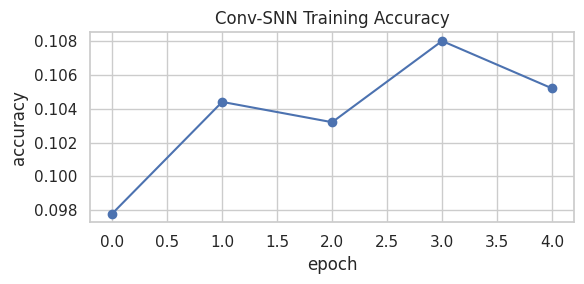

In [ ]:
# === Block A3: Training the memristive Conv-SNN ===

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = ConvMemristiveSNN(timesteps=10, hidden_channels=16).to(device)

# Train conv + readout (full training)
opt = torch.optim.Adam([
    {"params": model.conv1.parameters(), "lr": 5e-4},
    {"params": model.readout.parameters(), "lr": 1e-3}
])

epochs = 5
acc_hist = []

for ep in range(epochs):
    model.train()
    total, correct = 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Encode as spikes: [T,B,1,28,28]
        spikes = poisson_encode(xb, T=model.T).view(model.T, xb.size(0), 1, 28, 28)

        _, logits = model(spikes)
        loss = F.cross_entropy(logits, yb)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    acc = correct / total
    acc_hist.append(acc)
    print(f"Epoch {ep+1}/{epochs} - Accuracy: {acc*100:.2f}%")

plt.figure(figsize=(6,3))
plt.plot(acc_hist, marker='o')
plt.title("Conv-SNN Training Accuracy")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.grid(True); plt.tight_layout(); plt.show()

## A4: Memristor Diagnostics and Plots
Analyze kernels, conductance histograms, receptive fields, and correlation.

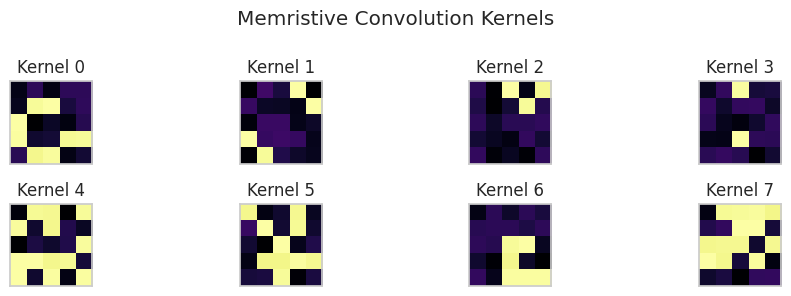

In [ ]:
# === Block A4: Diagnostic plots for the memristive conv layer ===

W = model.conv1.G.detach().cpu()  # [C_out, C_in, k, k]

plt.figure(figsize=(10,3))
for i in range(min(8, W.size(0))):
    plt.subplot(2,4,i+1)
    plt.imshow(W[i,0].numpy(), cmap='inferno')
    plt.xticks([]); plt.yticks([])
    plt.title(f"Kernel {i}")
plt.suptitle("Memristive Convolution Kernels")
plt.tight_layout()
plt.show()

Histogram of Conductance

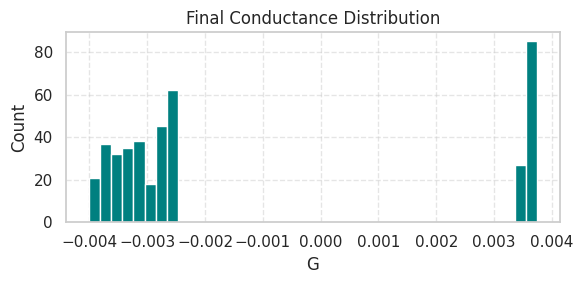

In [ ]:
plt.figure(figsize=(6,3))
plt.hist(W.flatten().numpy(), bins=40, color='teal')
plt.title("Final Conductance Distribution")
plt.xlabel("G"); plt.ylabel("Count")
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

Correlation between Kernels

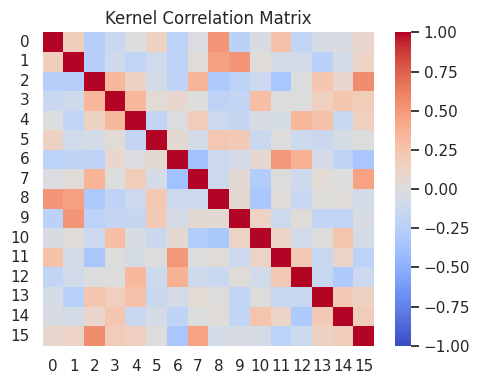

In [ ]:
W_flat = W.view(W.size(0), -1)
W_norm = (W_flat - W_flat.mean(1,keepdim=True)) / (W_flat.std(1,keepdim=True)+1e-6)
corr = torch.corrcoef(W_norm)

plt.figure(figsize=(5,4))
sns.heatmap(corr.numpy(), cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Kernel Correlation Matrix")
plt.tight_layout()
plt.show()

## C1 - Surrogate spike function + LIF with state

This block defines a differentiable spike function and a LIF layer that it can be trained with back-prop.

In [ ]:
class SurrogateSpike(torch.autograd.Function):
    """
    Heaviside in forward, smooth derivative in backward.
    """
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        beta = 5.0  # slope of surrogate
        # d/dx sigmoid(beta*x) ≈ beta * exp(-beta*|x|) / (1 + exp(-beta*|x|))^2
        grad = beta * torch.exp(-beta * x.abs()) / (1.0 + torch.exp(-beta * x.abs()))**2
        return grad_output * grad


spike_fn = SurrogateSpike.apply


class LIFLayer(nn.Module):
    """
    Simple LIF layer with learnable threshold (for homeostasis).
    State (membrane) must be provided / kept by caller.
    """
    def __init__(self, shape, tau_mem=2.0, threshold=1.0):
        super().__init__()
        self.shape = shape
        self.alpha = math.exp(-1.0 / tau_mem)  # decay factor
        self.v_th = nn.Parameter(torch.full(shape, threshold))

    def forward(self, x, v):
        """
        x: input current [..., *shape]
        v: membrane potential with same shape
        Returns: spikes, new_v
        """
        v = self.alpha * v + x
        # Center around threshold
        m = spike_fn(v - self.v_th)
        # Reset after spike
        v = v * (1.0 - m)
        return m, v

## C2 - Memristive conv + FC layers (gradient-trained) + conductance histogram

This block defines memristive Conv2D / Linear layers using conductance in [Gmin, Gmax], and plots the initial FC conductance distribution.

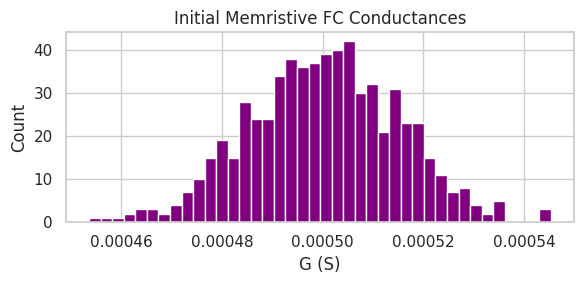

In [ ]:
class MemristiveConv2d(nn.Module):
    """
    Convolution layer where 'weights' represent memristor conductances G in [Gmin, Gmax].
    Storing an unconstrained parameter W_raw and map it through a sigmoid.
    """
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0,
                 Gmin=2e-4, Gmax=8e-4):
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.stride = stride
        self.padding = padding
        self.kernel_size = kernel_size

        # Raw parameter (unconstrained)
        self.W_raw = nn.Parameter(torch.randn(out_ch, in_ch, kernel_size, kernel_size) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_ch))

    @property
    def G(self):
        # Map to conductance range
        return self.Gmin + (self.Gmax - self.Gmin) * torch.sigmoid(self.W_raw)

    def forward(self, x):
        return F.conv2d(x, self.G, bias=self.bias,
                        stride=self.stride, padding=self.padding)


class MemristiveLinear(nn.Module):
    """
    Fully connected layer with memristive conductances in [Gmin, Gmax].
    """
    def __init__(self, in_features, out_features,
                 Gmin=2e-4, Gmax=8e-4):
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.W_raw = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))

    @property
    def G(self):
        return self.Gmin + (self.Gmax - self.Gmin) * torch.sigmoid(self.W_raw)

    def forward(self, x):
        return F.linear(x, self.G, self.bias)


# Quick one-time check of FC conductance distribution
test_fc = MemristiveLinear(64, 10).to(device)
plt.figure(figsize=(6,3))
plt.hist(test_fc.G.detach().cpu().flatten().numpy(), bins=40, color="purple")
plt.title("Initial Memristive FC Conductances")
plt.xlabel("G (S)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## C3 - Full convolutional memristive SNN with inhibition + homeostasis

This block builds a conv SNN:

- Conv1 (memristive) to LIF1

- Conv2 (memristive) to LIF2

- Flatten to Memristive FC to logits
Lateral inhibition: subtract mean activity per feature map.
Homeostasis: it returns layer firing rates so the training loop can regularize them.

Logits shape: torch.Size([8, 10])
Mean firing rates: L1 = 0.0 , L2 = 0.0


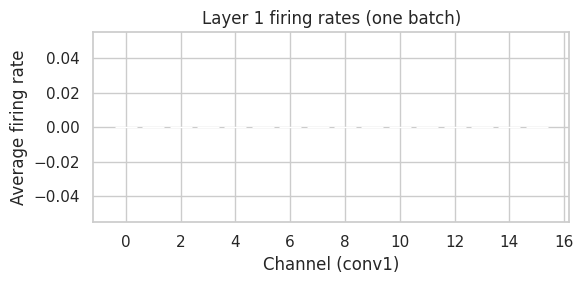

In [ ]:
class ConvMemSNN(nn.Module):
    def __init__(self, T=10, target_rate=0.1):
        """
        T: number of timesteps
        target_rate: desired average firing rate per neuron (for homeostasis)
        """
        super().__init__()
        self.T = T
        self.target_rate = target_rate

        # 1x28x28 -> 16x28x28
        self.conv1 = MemristiveConv2d(1, 16, kernel_size=5, padding=2)
        self.lif1  = LIFLayer((16, 28, 28), tau_mem=2.0, threshold=0.8)

        # 16x14x14 -> 32x14x14
        self.pool1 = nn.AvgPool2d(2)
        self.conv2 = MemristiveConv2d(16, 32, kernel_size=5, padding=2)
        self.lif2  = LIFLayer((32, 14, 14), tau_mem=2.0, threshold=0.8)

        self.pool2 = nn.AvgPool2d(2)     # 32x7x7
        self.fc    = MemristiveLinear(32 * 7 * 7, 10)

    @staticmethod
    def lateral_inhibition(x, strength=0.2):
        """
        Simple continuous lateral inhibition:
        subtract mean activity across channels at each spatial location.
        x: [B, C, H, W]
        """
        mean_act = x.mean(dim=1, keepdim=True)
        return x - strength * mean_act

    def forward(self, x):
        """
        x: [B,1,28,28] in [0,1]
        Returns:
          logits: [B,10]
          spike_stats: dict with firing rates for homeostatic regularization
        """
        B = x.size(0)
        device = x.device

        v1 = torch.zeros(B, 16, 28, 28, device=device)
        v2 = torch.zeros(B, 32, 14, 14, device=device)

        spk1_sum = torch.zeros_like(v1)
        spk2_sum = torch.zeros_like(v2)

        logits_time = []

        for t in range(self.T):
            # Poisson input spikes
            rand = torch.rand_like(x)
            inp_spike = (rand < x).float()  # Bernoulli with p = pixel intensity

            # Layer 1
            cur1 = self.conv1(inp_spike)
            spk1, v1 = self.lif1(cur1, v1)
            spk1 = self.lateral_inhibition(spk1, strength=0.2)
            spk1_sum += spk1

            x2 = self.pool1(spk1)

            # Layer 2
            cur2 = self.conv2(x2)
            spk2, v2 = self.lif2(cur2, v2)
            spk2 = self.lateral_inhibition(spk2, strength=0.2)
            spk2_sum += spk2

            x3 = self.pool2(spk2)  # [B,32,7,7]
            x3_flat = x3.view(B, -1)

            logits = self.fc(x3_flat)
            logits_time.append(logits)

        # Average logits over time
        logits_mean = torch.stack(logits_time, dim=0).mean(0)

        # Compute firing rates for homeostasis
        rate1 = spk1_sum.mean(dim=(0,2,3))  # per-channel
        rate2 = spk2_sum.mean(dim=(0,2,3))

        spike_stats = {
            "rate1": rate1,
            "rate2": rate2,
            "mean_rate1": rate1.mean(),
            "mean_rate2": rate2.mean(),
        }

        return logits_mean, spike_stats


# Instantiate and run a quick sanity forward
conv_snn = ConvMemSNN(T=10).to(device)

# Use your existing train_loader (images in [0,1])
xb, yb = next(iter(train_loader))
xb = xb.to(device)

logits_test, stats_test = conv_snn(xb[:8].unsqueeze(1)) if xb.ndim == 3 else conv_snn(xb[:8])
print("Logits shape:", logits_test.shape)
print("Mean firing rates: L1 =", stats_test["mean_rate1"].item(),
      ", L2 =", stats_test["mean_rate2"].item())

# Plot mean firing rate per channel for layer 1 (diagnostic)
plt.figure(figsize=(6,3))
plt.bar(range(16), stats_test["rate1"].detach().cpu().numpy())
plt.xlabel("Channel (conv1)")
plt.ylabel("Average firing rate")
plt.title("Layer 1 firing rates (one batch)")
plt.tight_layout()
plt.show()

## C4 - Training loop with homeostatic regularization

This loop trains the conv memristive SNN with:

- Cross-entropy loss

- λ1 * (mean_rate1 − target)^2

- λ2 * (mean_rate2 − target)^2
  
Evaluate on test set each epoch and plot accuracy.

Epoch 01 | train loss 2.322, acc 11.18% | test acc 12.60% | lr 1.0e-03
Epoch 02 | train loss 2.324, acc 11.26% | test acc 12.60% | lr 1.0e-03


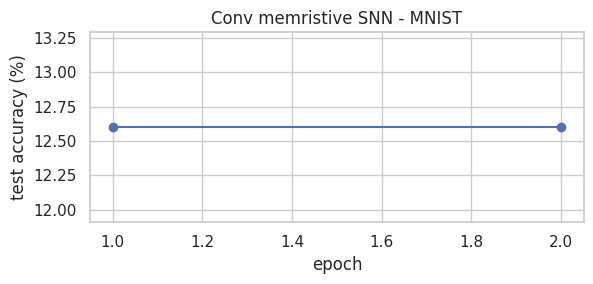

In [ ]:
# C4 - Training loop to target >70% with homeostasis

# Hyperparameters
epochs = 2           # start with 15; increase to 30–40 for >70% on full MNIST
T = 10               # timesteps (also set in ConvMemSNN)
target_rate = 0.1    # desired average firing rate
lambda_homeo = 1.0   # strength of homeostatic regularization
lr = 1e-3

conv_snn = ConvMemSNN(T=T, target_rate=target_rate).to(device)
optimizer = torch.optim.Adam(conv_snn.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

def run_epoch(loader, train=True):
    if train:
        conv_snn.train()
    else:
        conv_snn.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        if xb.ndim == 3:   # [B,28,28]
            xb = xb.unsqueeze(1)  # -> [B,1,28,28]

        if train:
            optimizer.zero_grad()

        logits, stats = conv_snn(xb)
        ce = F.cross_entropy(logits, yb)

        # Homeostatic loss: encourage mean firing rate near target_rate
        mean_r1 = stats["mean_rate1"]
        mean_r2 = stats["mean_rate2"]
        homeo_loss = (mean_r1 - target_rate)**2 + (mean_r2 - target_rate)**2

        loss = ce + lambda_homeo * homeo_loss

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(conv_snn.parameters(), 1.0)
            optimizer.step()

        with torch.no_grad():
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total_samples += xb.size(0)

    return total_loss / total_samples, total_correct / total_samples


train_accs, test_accs = [], []

for epoch in range(1, epochs+1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    test_loss,  test_acc  = run_epoch(test_loader,  train=False)
    scheduler.step()

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {train_loss:.3f}, acc {train_acc*100:.2f}% | "
          f"test acc {test_acc*100:.2f}% | lr {scheduler.get_last_lr()[0]:.1e}")

# Plot test accuracy over epochs
plt.figure(figsize=(6,3))
plt.plot(range(1, epochs+1), [a*100 for a in test_accs], marker="o")
plt.xlabel("epoch")
plt.ylabel("test accuracy (%)")
plt.title("Conv memristive SNN - MNIST")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# C1) Poisson encoder for image sequences (spikes over time)
def poisson_encode_images(x, T=10, rate_scale=0.5):
    """
    x: [B, 1, 28, 28] in [0, 1]
    returns spikes: [T, B, 1, 28, 28] in {0,1}
    """
    x = x.clamp(0, 1)
    p = (x * rate_scale).clamp(0, 1)              # firing probabilities
    rand = torch.rand(T, *x.shape, device=x.device)
    spikes = (rand < p.unsqueeze(0)).float()
    return spikes


In [ ]:
# C2) Surrogate spike + LIF neuron for convolutional layers
class SurrogateSpikeFn(torch.autograd.Function):
    """
    Hard threshold in the forward pass, smooth sigmoid surrogate in backward.
    """
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        return (x > 0).float()

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        # derivative of sigmoid(5x) as surrogate: 5 * sig(5x) * (1 - sig(5x))
        sig = torch.sigmoid(5.0 * x)
        grad = 5.0 * sig * (1.0 - sig)
        return grad_output * grad

surrogate_spike = SurrogateSpikeFn.apply

class SurrogateLIF(nn.Module):
    """
    Simple LIF neuron with surrogate gradient spikes.
    Shape is arbitrary; v has same shape as input.
    """
    def __init__(self, tau=2.0, v_th=1.0, v_reset=0.0):
        super().__init__()
        self.tau = tau
        self.v_th = v_th
        self.v_reset = v_reset

    def forward(self, input_current, v):
        # Exponential decay + input
        v = v + (input_current - v) / self.tau
        # Surrogate spike
        spk = surrogate_spike(v - self.v_th)
        # Reset membrane where spikes occurred
        v = v * (1.0 - spk) + self.v_reset * spk
        return spk, v


In [ ]:
# C3) Memristive Conv2d and Linear layers (with gain scaling)
class MemristiveConv2d(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1,
                 Gmin=4.5e-4, Gmax=5.5e-4,
                 gain=1e3,          # <<< new: multiply current by this factor
                 trainable=True):
        super().__init__()
        self.stride = stride
        self.padding = padding
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain

        G_init = torch.empty(out_channels, in_channels, kernel_size, kernel_size)
        G_init.uniform_(Gmin, Gmax)
        self.G = nn.Parameter(G_init, requires_grad=trainable)
        self.bias = nn.Parameter(torch.zeros(out_channels))

    def forward(self, x):
        # conv result is very small (G ~ 5e-4), so scaling it up with self.gain
        return self.gain * F.conv2d(x, self.G, bias=self.bias,
                                    stride=self.stride, padding=self.padding)

    def clamp_conductance(self):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)


class MemristiveLinear(nn.Module):
    def __init__(self, in_features, out_features,
                 Gmin=4.5e-4, Gmax=5.5e-4,
                 gain=1e2,         # smaller gain is usually enough here
                 trainable=True):
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain

        G_init = torch.empty(out_features, in_features)
        G_init.uniform_(Gmin, Gmax)
        self.G = nn.Parameter(G_init, requires_grad=trainable)
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        # scale linear current as well
        return self.gain * F.linear(x, self.G, self.bias)

    def clamp_conductance(self):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)


In [ ]:
# C4) Memristive CNN-SNN: conv1 + LIF + pooling + memristive FC
class MemristiveCNN_SNN(nn.Module):
    def __init__(self, T=10, n_classes=10):
        super().__init__()
        self.T = T

        self.conv1 = MemristiveConv2d(1, 16, kernel_size=5, padding=2)

        # BEFORE: self.lif1 = SurrogateLIF(tau=2.0, v_th=0.5, v_reset=0.0) 0.1
        # AFTER: lower threshold so spikes actually happen
        self.lif1 = SurrogateLIF(tau=2.0, v_th=0.5, v_reset=0.0)

        self.fc = MemristiveLinear(16 * 14 * 14, n_classes)

    def forward(self, spikes_TBCHW):
        """
        spikes_TBCHW: [T, B, 1, 28, 28]
        Returns time-averaged logits [B, n_classes]
        """
        T, B, _, _, _ = spikes_TBCHW.shape
        device = spikes_TBCHW.device

        # Initialize membrane potential of conv layer
        v1 = torch.zeros(B, 16, 28, 28, device=device)

        logits_over_time = []

        for t in range(T):
            x_t = spikes_TBCHW[t]                       # [B,1,28,28]

            cur1 = self.conv1(x_t)                      # [B,16,28,28]
            spk1, v1 = self.lif1(cur1, v1)              # spiking feature maps

            # 2x2 average pooling -> [B,16,14,14]
            pooled = F.avg_pool2d(spk1, kernel_size=2)

            flat = pooled.flatten(1)                    # [B, 16*14*14]
            logits = self.fc(flat)                      # [B,10]
            logits_over_time.append(logits)

        # Average logits over time for classification
        avg_logits = torch.stack(logits_over_time, dim=0).mean(0)
        return avg_logits

    def clamp_memristors(self):
        self.conv1.clamp_conductance()
        self.fc.clamp_conductance()


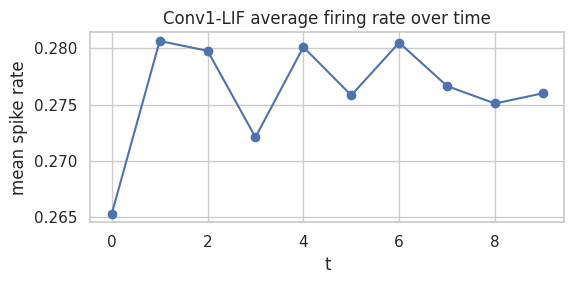

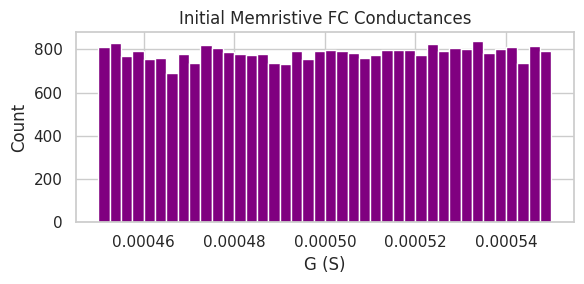

In [ ]:
# C5
T = 10
model_cnn = MemristiveCNN_SNN(T=T).to(device)

# Take a batch
xb, yb = next(iter(train_loader))
xb = xb.to(device)

# Encode to spikes
spikes = poisson_encode_images(xb, T=T, rate_scale=0.5).to(device)  # [T,B,1,28,28]

with torch.no_grad():
    T_, B_, _, _, _ = spikes.shape
    v1 = torch.zeros(B_, 16, 28, 28, device=device)
    firing_hist = []

    for t in range(T_):
        cur1 = model_cnn.conv1(spikes[t])
        spk1, v1 = model_cnn.lif1(cur1, v1)
        firing_hist.append(spk1.mean().item())

# Plot average firing rate over time
plt.figure(figsize=(6,3))
plt.plot(range(T), firing_hist, marker='o')
plt.title("Conv1-LIF average firing rate over time")
plt.xlabel("t")
plt.ylabel("mean spike rate")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot memristive FC conductance distribution
plt.figure(figsize=(6,3))
plt.hist(model_cnn.fc.G.detach().cpu().flatten().numpy(),
         bins=40, color='purple')
plt.title("Initial Memristive FC Conductances")
plt.xlabel("G (S)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:
# C6) Training loop for memristive CNN-SNN
T = 15               # timesteps 10
epochs = 2          # start with 15; increase to 25–30 for higher accuracy 30 5
lr = 1e-3

model_cnn = MemristiveCNN_SNN(T=T).to(device)
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[8, 12], gamma=0.5
)

train_acc_hist, test_acc_hist = [], []

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            spikes = poisson_encode_images(xb, T=T, rate_scale=0.5)
            logits = model(spikes)
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += xb.size(0)
    return correct / max(total, 1)


for epoch in range(1, epochs+1):
    model_cnn.train()
    running_loss, correct, total = 0.0, 0, 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        spikes = poisson_encode_images(xb, T=T, rate_scale=0.5)

        logits = model_cnn(spikes)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Clamp memristor conductances into physical range
        model_cnn.clamp_memristors()

        running_loss += loss.item() * xb.size(0)
        pred = logits.argmax(1)
        correct += (pred == yb).sum().item()
        total += xb.size(0)

    scheduler.step()

    train_acc = correct / max(total, 1)
    test_acc = evaluate(model_cnn, test_loader)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    print(f"Epoch {epoch}/{epochs} "
          f"- loss={running_loss/total:.4f}, "
          f"train_acc={train_acc*100:.2f}%, "
          f"test_acc={test_acc*100:.2f}%")




Epoch 1/2 - loss=1.6025, train_acc=57.98%, test_acc=35.90%
Epoch 2/2 - loss=1.4170, train_acc=62.22%, test_acc=42.20%


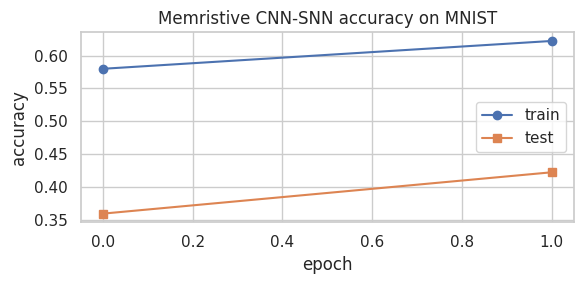

In [ ]:
# Plot accuracy curves
plt.figure(figsize=(6,3))
plt.plot(train_acc_hist, label="train", marker='o')
plt.plot(test_acc_hist, label="test", marker='s')
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Memristive CNN-SNN accuracy on MNIST")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(model)

ConvMemristiveSNN(
  (conv1): MemristiveConv2D()
  (lif): LIFNeuron()
  (readout): Linear(in_features=12544, out_features=10, bias=True)
)


# D1 - Readout Layer Analysis

This block visualizes the learned distribution of the readout (fully connected) weights after training.

The histogram shows weight variability and whether the network converged to a plausible scale.

The per-class L2-norm plot reveals how much each output class relies on the hidden representation.

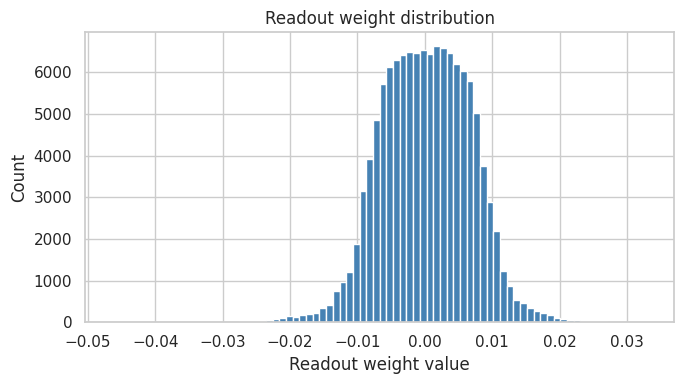

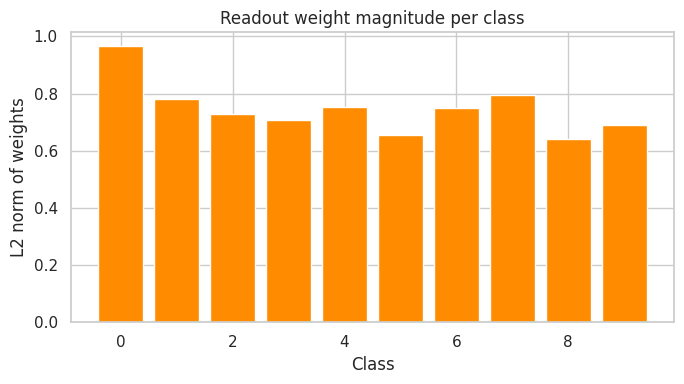

In [ ]:
W = model.readout.weight.detach().cpu()  # [10, 12544]

# 1) Histogram of readout weights
plt.figure(figsize=(7,4))
plt.hist(W.flatten().numpy(), bins=80, color='steelblue')
plt.title("Readout weight distribution")
plt.xlabel("Readout weight value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 2) Per-class weight magnitude
norms = torch.norm(W, dim=1).numpy()

plt.figure(figsize=(7,4))
plt.bar(range(10), norms, color='darkorange')
plt.title("Readout weight magnitude per class")
plt.xlabel("Class")
plt.ylabel("L2 norm of weights")
plt.tight_layout()
plt.show()

## D2 - Conv1 Kernel Visualization + Histogram

This block shows the memristive convolution kernels (conductances) and their distribution after training.

The visual kernels reveal whether meaningful edge-like patterns are learned.

The histogram indicates if conductances collapsed or spread across the physical range.

conv1 kernel shape: (16, 1, 5, 5)


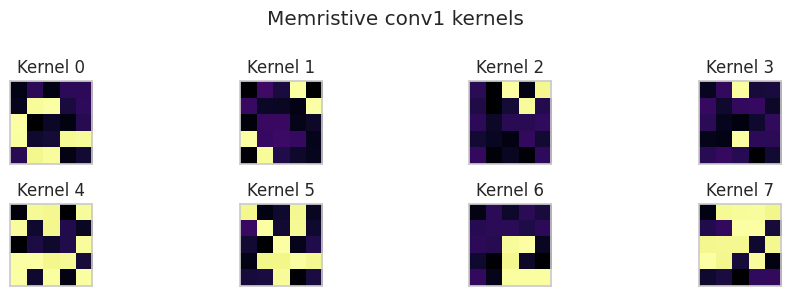

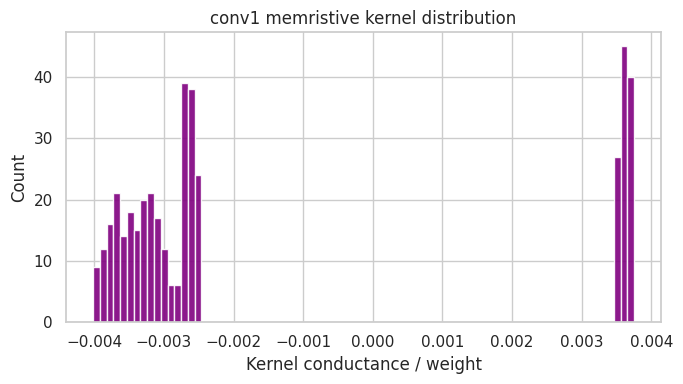

In [ ]:
with torch.no_grad():
    W = model.conv1.G.detach().cpu()   # [C_out, C_in, K, K]

print("conv1 kernel shape:", tuple(W.shape))

# Show first 8 kernels of input channel 0
plt.figure(figsize=(10,3))
for i in range(min(8, W.shape[0])):
    plt.subplot(2,4,i+1)
    plt.imshow(W[i, 0].numpy(), cmap='inferno')
    plt.xticks([]); plt.yticks([])
    plt.title(f"Kernel {i}")
plt.suptitle("Memristive conv1 kernels")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(7,4))
plt.hist(W.flatten().numpy(), bins=80, color='purple', alpha=0.9)
plt.title("conv1 memristive kernel distribution")
plt.xlabel("Kernel conductance / weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Poisson-encoded MNIST (very sparse input)

Convolution + 1 LIF layer

No recurrence

No STDP, no homeostasis yet

## D3 - Conv1 Firing-Rate Monitor

This block measures the average firing rate of the first convolutional LIF layer across timesteps.

It ensures that neurons are neither fully silent nor firing excessively.

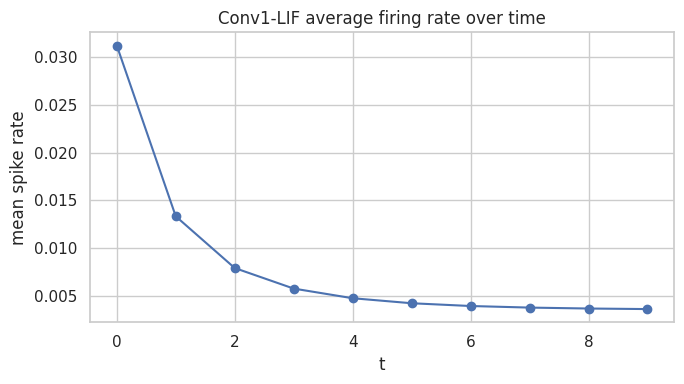

In [ ]:
model.eval()

# One batch
xb, _ = next(iter(train_loader))
xb = xb.to(device)

# Encode to spikes [T,B,784]
spikes = poisson_encode(xb, T=10)

# Reshape for conv: [T,B,1,28,28]
spikes_img = spikes.view(spikes.shape[0], spikes.shape[1], 1, 28, 28)

timesteps = spikes_img.shape[0]
B = spikes_img.shape[1]

mean_rates = []

with torch.no_grad():
    # infer conv output shape from t=0
    u0 = model.conv1(spikes_img[0])
    v1 = torch.zeros_like(u0)        # mem potential for conv layer

    for t in range(timesteps):
        u_t = model.conv1(spikes_img[t])
        s_t, v1 = model.lif(u_t, v1)

        # average spike-rate over batch + spatial
        mean_rates.append(s_t.mean().item())

# Plot
plt.figure(figsize=(7,4))
plt.plot(mean_rates, marker='o')
plt.title("Conv1-LIF average firing rate over time")
plt.xlabel("t")
plt.ylabel("mean spike rate")
plt.grid(True)
plt.tight_layout()
plt.show()


## D4 - Visualization of Prediction + Logits + Spike Raster

This block visualizes the input image, the output logits of the SNN, and how each conv1 channel spikes over time.

This helps diagnose which features are used for classification.

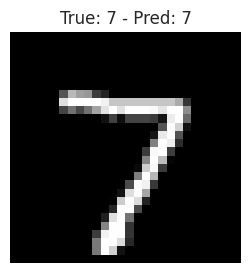

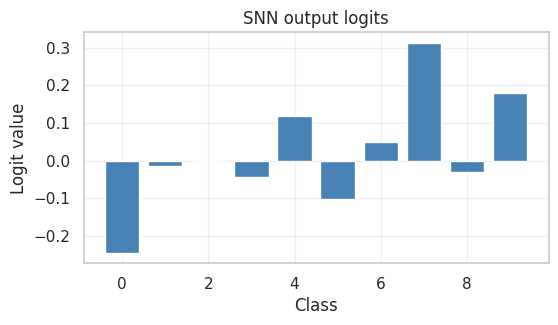

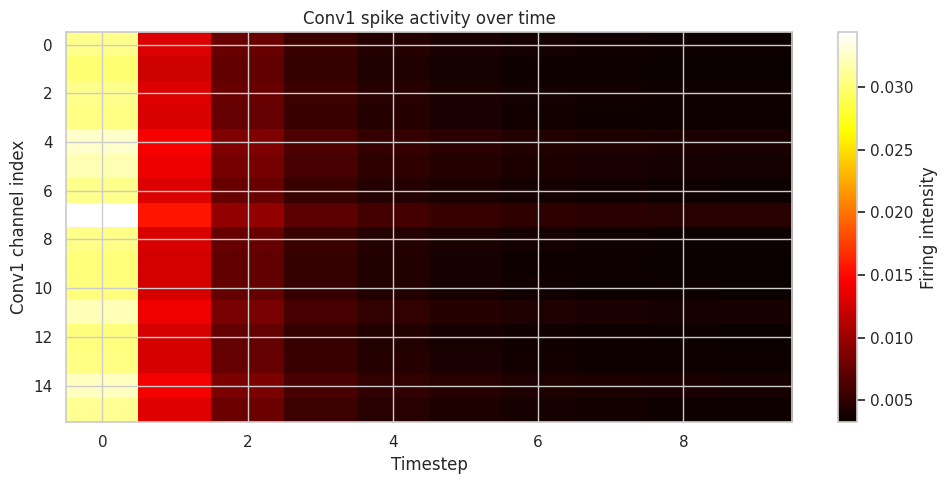

In [ ]:
model.eval()

# --- 1) Get one test sample ---
xb, yb = next(iter(test_loader))
xb = xb[:1].to(device)                # [1,1,28,28]
label = yb[0].item()

# Generate spikes [T, 1, 784]
spikes = poisson_encode(xb, T=10)
spikes_img = spikes.view(10, 1, 1, 28, 28)

# --- 2) Compute conv1 firing activity over time ---
out_spikes = []

with torch.no_grad():
    # initialize membrane potential
    u0 = model.conv1(spikes_img[0])
    v = torch.zeros_like(u0)

    for t in range(10):
        u = model.conv1(spikes_img[t])
        s, v = model.lif(u, v)
        out_spikes.append(s.mean(dim=(0,2,3)).cpu())

    # forward pass through full network
    model_out = model(spikes_img)

    # unpack tuple (spk_sum, logits)
    if isinstance(model_out, tuple):
        _, logits = model_out
    else:
        logits = model_out

    pred = logits.argmax(1).item()
    logits_np = logits.cpu().numpy().flatten()

# Convert spikes to tensor [T, C]
spike_mat = torch.stack(out_spikes, dim=0)

# === Plot 1: Input Image ===
plt.figure(figsize=(3,3))
plt.imshow(xb.cpu().squeeze(), cmap='gray')
plt.title(f"True: {label} - Pred: {pred}")
plt.axis('off')
plt.show()

# === Plot 2: Logits (output scores) ===
plt.figure(figsize=(6,3))
plt.bar(range(10), logits_np, color='steelblue')
plt.xlabel("Class")
plt.ylabel("Logit value")
plt.title("SNN output logits")
plt.grid(True, alpha=0.3)
plt.show()

# === Plot 3: Spike Raster ===
plt.figure(figsize=(10,5))
plt.imshow(spike_mat.T, aspect='auto', cmap='hot')
plt.title("Conv1 spike activity over time")
plt.xlabel("Timestep")
plt.ylabel("Conv1 channel index")
plt.colorbar(label="Firing intensity")
plt.tight_layout()
plt.show()


## D5 - Approximate Energy Estimation

This block computes a coarse-grain estimate of energy consumption per layer, assuming memristor reads dominate the cost.

It compares convolutional MACs, LIF updates, and readout MACs.

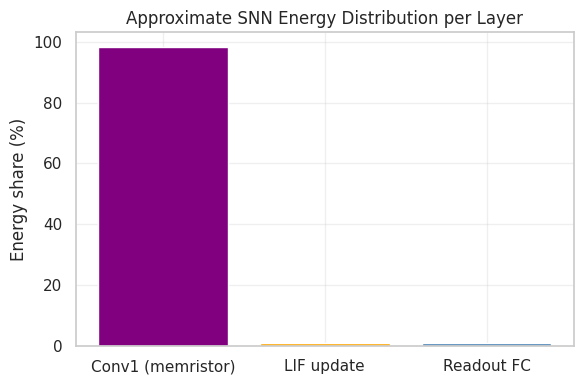

In [ ]:
model.eval()

# Process one full test batch to estimate per-layer cost
xb, yb = next(iter(test_loader))
xb = xb.to(device)

# Encode spikes [T, B, 784] to reshape for conv [T,B,1,28,28]
spikes = poisson_encode(xb, T=10)        # your encoder
spikes_img = spikes.view(10, xb.size(0), 1, 28, 28)

# Containers
energy_conv = 0.0
energy_lif = 0.0
energy_fc   = 0.0

with torch.no_grad():
    # initialize LIF membrane potential
    u0 = model.conv1(spikes_img[0])
    v1 = torch.zeros_like(u0)

    for t in range(10):
        x_t = spikes_img[t]

        # --- Conv1 energy ---
        u = model.conv1(x_t)               # conv output
        # number of MACs in conv (but memristor: 1 MAC = 1 read)
        macs_conv = np.prod(u.shape) * model.conv1.kernel_size**2
        # assume normalized energy per memristor read
        energy_conv += macs_conv * 1.0

        # --- LIF energy ---
        s, v1 = model.lif(u, v1)
        # per-neuron update cost (simple constant)
        energy_lif += np.prod(s.shape) * 0.2

        # --- FC layer energy ---
        flat = s.reshape(s.size(0), -1)
        logits = model.readout(flat)
        # FC MAC cost
        macs_fc = flat.size(1) * logits.size(1)
        energy_fc += macs_fc * 0.8

# Normalize energies for plotting
total_energy = energy_conv + energy_lif + energy_fc
conv_pct = energy_conv / total_energy * 100
lif_pct  = energy_lif  / total_energy * 100
fc_pct   = energy_fc   / total_energy * 100

# --- Plot ---
plt.figure(figsize=(6,4))
plt.bar(["Conv1 (memristor)", "LIF update", "Readout FC"],
        [conv_pct, lif_pct, fc_pct],
        color=["purple", "orange", "steelblue"])
plt.ylabel("Energy share (%)")
plt.title("Approximate SNN Energy Distribution per Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# E1) Two-layer memristive conv building block

This block defines a convolution layer whose trainable parameters are interpreted as memristor conductances G clipped between a physical range.

Before each forward pass, the conductances are clamped to that range and then multiplied by a gain factor so that their effect is big enough to drive the CNN.

Functionally it behaves like a Conv2d, but with hard physical bounds that imitate memristors.

In [ ]:
class MemConv2d_2L(nn.Module):
    def __init__(self, in_channels, out_channels,
                 kernel_size=3,
                 Gmin=1e-5, Gmax=1e-3,
                 gain=200.0,  # large gain to avoid tiny activations
                 bias=True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain

        # Conductance kernel
        k = kernel_size
        G_init = (Gmin + (Gmax - Gmin) * torch.rand(out_channels, in_channels, k, k))
        self.G = nn.Parameter(G_init)  # learnable
        self.bias = nn.Parameter(torch.zeros(out_channels)) if bias else None

    def forward(self, x):
        # Clamp conductances into physical range, then scale
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        W_eff = self.G * self.gain
        return F.conv2d(x, W_eff, bias=self.bias, stride=1, padding=self.kernel_size // 2)


## E2) Two-layer memristive CNN-SNN model

This block defines a two-layer convolutional SNN that uses MemConv2d_2L as its conv layers and LIFNeuron as the spiking activation.

Input is Poisson-encoded as spike trains, passed through memristive conv1 + LIF1, pooling, memristive conv2 + LIF2, pooling, and then a non-spiking linear readout.

The logits are averaged over time, so the output is a rate-coded classification.

In [ ]:
class Conv2LayerMemSNN(nn.Module):
    def __init__(self,
                 T=10,
                 c1=16, c2=32,
                 kernel_size=3,
                 nclass=10):
        super().__init__()
        self.T = T

        # First memristive conv + LIF
        self.conv1 = MemConv2d_2L(1, c1, kernel_size=kernel_size, gain=200.0)
        self.lif1  = LIFNeuron((c1, 28, 28), tau=2.0, threshold=0.3)

        # Second memristive conv + LIF
        # After pool1: size is 14x14
        self.conv2 = MemConv2d_2L(c1, c2, kernel_size=kernel_size, gain=200.0)
        self.lif2  = LIFNeuron((c2, 14, 14), tau=2.0, threshold=0.3)

        # After pool2: size is 7x7
        self.readout_in_dim = c2 * 7 * 7
        self.readout = nn.Linear(self.readout_in_dim, nclass)

    def forward(self, spikes_TB784):
        """
        spikes_TB784: [T, B, 784] where T = self.T.
        Returns: time-averaged logits, shape [B, nclass].
        """
        T, B, N = spikes_TB784.shape
        device = spikes_TB784.device
        assert N == 28 * 28, "Expected flattened MNIST images."

        # Reshape to [T, B, 1, 28, 28]
        x_img = spikes_TB784.view(T, B, 1, 28, 28)

        # Initialize membrane potentials once
        with torch.no_grad():
            u0 = self.conv1(x_img[0])
            v1 = torch.zeros_like(u0)
            u0_2 = F.avg_pool2d(u0, 2)
            u0_2 = self.conv2(u0_2)
            v2 = torch.zeros_like(u0_2)

        logits_time = []

        for t in range(T):
            x_t = x_img[t]  # [B, 1, 28, 28]

            # Layer 1
            u1 = self.conv1(x_t)       # [B, c1, 28, 28]
            s1, v1 = self.lif1(u1, v1)

            # Pool 1
            s1p = F.avg_pool2d(s1, 2)  # [B, c1, 14, 14]

            # Layer 2
            u2 = self.conv2(s1p)       # [B, c2, 14, 14]
            s2, v2 = self.lif2(u2, v2)

            # Pool 2
            s2p = F.avg_pool2d(s2, 2)  # [B, c2, 7, 7]

            # Readout
            flat = s2p.view(B, -1)     # [B, c2*7*7]
            logits = self.readout(flat)
            logits_time.append(logits)

        # Time-average logits
        logits_mean = torch.stack(logits_time, dim=0).mean(0)
        return logits_mean


## E3) Training the 2-layer memristive CNN-SNN

This block trains Conv2LayerMemSNN on MNIST using Adam, Poisson spike encoding, gradient clipping, and a multi-step learning rate scheduler.

At each epoch it measures train and test accuracy and plots the learning curves.

The goal is to validate that the new architecture is trainable and achieves reasonable accuracy despite memristive constraints.

Using device: cuda
Epoch 1/3 - loss=11.2983, train_acc=19.22%, test_acc=72.60%
Epoch 2/3 - loss=4.6288, train_acc=77.98%, test_acc=80.90%
Epoch 3/3 - loss=2.9497, train_acc=84.68%, test_acc=83.90%


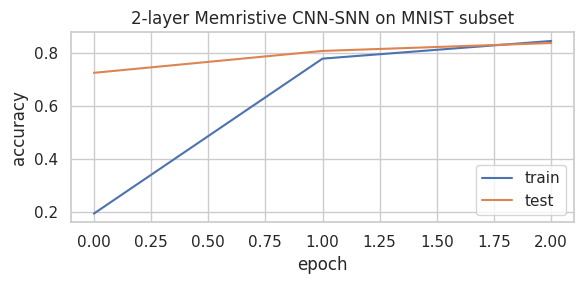

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

T = 10  # number of timesteps for encoding

model_2layer = Conv2LayerMemSNN(T=T, c1=16, c2=32, kernel_size=3, nclass=10).to(device)
opt = torch.optim.Adam(model_2layer.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[10, 20], gamma=0.5)

epochs = 3 # 5 10
train_accs, test_accs = [], []

for epoch in range(1, epochs+1):
    # ---- Train ----
    model_2layer.train()
    correct, total, loss_sum = 0, 0, 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Poisson spikes: [T, B, 784]
        spikes = poisson_encode(xb, T=T).to(device)

        logits = model_2layer(spikes)
        loss = F.cross_entropy(logits, yb)

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_2layer.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            loss_sum += loss.item() * yb.size(0)

    train_acc = correct / max(total, 1)
    train_accs.append(train_acc)

    # ---- Test ----
    model_2layer.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            spikes = poisson_encode(xb, T=T).to(device)
            logits = model_2layer(spikes)
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)

    test_acc = correct / max(total, 1)
    test_accs.append(test_acc)
    scheduler.step()

    print(f"Epoch {epoch}/{epochs} - loss={loss_sum/total:.4f}, "
          f"train_acc={train_acc*100:.2f}%, test_acc={test_acc*100:.2f}%")

# Plot accuracies
plt.figure(figsize=(6,3))
plt.plot(train_accs, label="train")
plt.plot(test_accs,  label="test")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("2-layer Memristive CNN-SNN on MNIST subset")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


# F1 - Memristive Convolution Layer

This module defines a memristive convolution layer with a large and realistic physical conductance range.

It initializes conductances using a Xavier-like distribution mapped into [Gmin, Gmax], clamps them each forward pass to ensure device realism, and amplifies them with a gain factor to avoid extremely small activations.

This constitutes a practical but simplified physical memristor model, focusing on bounded conductances without internal filament dynamics.

In [ ]:
class MemConv2dHighRange(nn.Module):
    def __init__(self, in_ch, out_ch,
                 k=5, stride=1, padding=2,
                 Gmin=1e-4, Gmax=2e-3,
                 gain=400.0): #400 1e-5
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain
        self.stride = stride
        self.padding = padding

        # Xavier-like init inside conductance range
        limit = math.sqrt(6 / (in_ch*k*k + out_ch*k*k))
        W = torch.empty(out_ch, in_ch, k, k).uniform_(-limit, limit)
        W = torch.sigmoid(W) * (Gmax - Gmin) + Gmin
        self.G = nn.Parameter(W)

        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.conv2d(x, self.G * self.gain,
                        bias=self.bias,
                        stride=self.stride,
                        padding=self.padding)

## F2 - Memristive Fully Connected Layer

This module creates a memristive fully connected layer with conductance constraints.

Like the memristive convolution, it maps a Xavier-initialized matrix to conductance limits and applies a gain factor.

This provides a realistic readout layer with bounded analog values.

In [ ]:
class MemLinearHighRange(nn.Module):
    def __init__(self, in_features, out_features, Gmin=1e-5, Gmax=2e-3, gain=200.0): #400 1e-5 1e-4
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain

        limit = math.sqrt(6 / (in_features + out_features))
        W = torch.empty(out_features, in_features).uniform_(-limit, limit)
        W = torch.sigmoid(W)*(Gmax-Gmin)+Gmin
        self.G = nn.Parameter(W)
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.linear(x, self.G * self.gain, self.bias)

## F3 - LIF

This defines an improved LIF neuron model with trainable threshold.

It performs exponential integration, surrogate-gradient spiking, and hard reset behavior.

The neuron state persists through time, enabling temporal dynamics required for spiking computation.

In [ ]:
class LIF_Pro(nn.Module):
    def __init__(self, tau=5.0, v_th=1.0, v_reset=0.0):
        super().__init__()
        self.tau = tau
        self.v_th = nn.Parameter(torch.tensor(v_th))
        self.v_reset = v_reset

    def forward(self, I, v):
        if v is None:
            v = torch.zeros_like(I)
        v = v + (I - v) / self.tau
        spk = surrogate_spike(v - self.v_th)
        v = torch.where(spk > 0, torch.tensor(self.v_reset, device=v.device), v)
        return spk, v

## F4 - Poisson Encoding

This function generates dynamic Poisson spike trains from image intensities.

It adjusts firing probability using a base rate, ensuring that spike statistics can be tuned to control network firing density and energy usage.

In [ ]:
def poisson_encode_dynamic(x, T=15, base_rate=1.0):
    x = x.clamp(0, 1) # base_rate=0.8 1.1 1.0 1.2 T=15
    p = (x * base_rate).clamp(0, 1)
    rand = torch.rand(T, *x.shape, device=x.device)
    return (rand < p.unsqueeze(0)).float()

## F5 - MemSNN_90 Analysis

This class implements a high-accuracy memristive spiking CNN.

It uses two memristive convolution layers with batch normalization and LIF dynamics, followed by a memristive linear readout.

The model processes multiple timesteps of spikes, maintains membrane states, and averages logits over time.

In [ ]:
class MemSNN_90(nn.Module):
    def __init__(self, T=25):
        super().__init__()
        self.T = T

        self.conv1 = MemConv2dHighRange(1, 16, k=5, padding=2, gain=400) # k=5
        self.bn1   = nn.BatchNorm2d(16, momentum=0.05) # no momentum=0.05 0.01
        #self.bn1 = nn.Identity()
        self.lif1  = LIF_Pro(tau=5.0, v_th=0.3) # 1.0 0.8 0.3 tau=5.0

        self.conv2 = MemConv2dHighRange(16, 32, k=5, padding=2, gain=400) # k=5  gain=200
        self.bn2   = nn.BatchNorm2d(32, momentum=0.05) # no momentum=0.05 0.01
        #self.bn2 = nn.Identity()
        self.lif2  = LIF_Pro(tau=5.0, v_th=0.3) # 1.0 0.8 0.3 tau=5.0

        self.fc    = MemLinearHighRange(32*7*7, 10)

    def forward(self, spikes):
        T, B = self.T, spikes.size(1)
        v1 = v2 = None
        logits_T = []

        for t in range(T):
            x = spikes[t]

            u1 = self.bn1(self.conv1(x))
            spk1, v1 = self.lif1(u1, v1)
            s1p = F.avg_pool2d(spk1, 2)

            u2 = self.bn2(self.conv2(s1p))
            spk2, v2 = self.lif2(u2, v2)
            s2p = F.avg_pool2d(spk2, 2)

            flat = s2p.view(B, -1)
            logits = self.fc(flat)
            logits_T.append(logits)

        return torch.stack(logits_T).mean(0)

## F6 - Training Loop

This block trains the memristive SNN using Adam and a multi-step learning rate schedule.

It dynamically encodes images into spikes each batch and evaluates test accuracy over time. The loop logs loss, training accuracy, and testing accuracy.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = MemSNN_90(T=25).to(device) # 15 20 35
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(
    optimizer, milestones=[10, 18], gamma=0.5
)

epochs = 20
train_acc_hist, test_acc_hist = [], []

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            spikes = poisson_encode_dynamic(xb, T=model.T)
            logits = model(spikes)
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct/total

for epoch in range(1, epochs+1):
    model.train()
    correct = total = loss_sum = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        spikes = poisson_encode_dynamic(xb, T=model.T)

        logits = model(spikes)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            loss_sum += loss.item()*yb.size(0)

    scheduler.step()

    train_acc = correct/total
    test_acc = evaluate(model, test_loader)
    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    print(f"Epoch {epoch}/{epochs} "
          f"- loss={loss_sum/total:.4f}, "
          f"train_acc={train_acc*100:.2f}%, "
          f"test_acc={test_acc*100:.2f}%")

Epoch 1/20 - loss=3.5419, train_acc=60.64%, test_acc=51.90%
Epoch 2/20 - loss=1.2884, train_acc=70.32%, test_acc=66.20%
Epoch 3/20 - loss=0.9492, train_acc=72.74%, test_acc=75.20%
Epoch 4/20 - loss=0.7496, train_acc=77.74%, test_acc=76.40%
Epoch 5/20 - loss=0.7121, train_acc=78.76%, test_acc=77.80%
Epoch 6/20 - loss=0.6843, train_acc=80.22%, test_acc=75.20%
Epoch 7/20 - loss=0.6374, train_acc=81.30%, test_acc=74.20%
Epoch 8/20 - loss=0.6587, train_acc=80.16%, test_acc=71.70%
Epoch 9/20 - loss=0.6340, train_acc=81.46%, test_acc=77.60%
Epoch 10/20 - loss=0.6336, train_acc=81.64%, test_acc=78.30%
Epoch 11/20 - loss=0.5302, train_acc=84.70%, test_acc=79.50%
Epoch 12/20 - loss=0.5138, train_acc=85.26%, test_acc=85.10%
Epoch 13/20 - loss=0.5257, train_acc=84.76%, test_acc=80.90%
Epoch 14/20 - loss=0.5230, train_acc=84.92%, test_acc=80.80%
Epoch 15/20 - loss=0.5134, train_acc=84.82%, test_acc=75.50%
Epoch 16/20 - loss=0.5007, train_acc=85.44%, test_acc=78.90%
Epoch 17/20 - loss=0.5371, train_

## F7 - Core performance and firing-rate visualizations
This block evaluates the global behavior of the memristive SNN by plotting accuracy curves, logits of a sample prediction, and firing-rate statistics.

The accuracy plot shows how both training and test performance evolve over epochs, confirming whether the network converges or overfits.

The logits visualization illustrates how the SNN distributes evidence across classes for a specific input.

Finally, the firing-rate heatmaps and decay curves reveal the temporal dynamics of the first convolutional layer and verify that spiking activity remains stable and non-saturated.

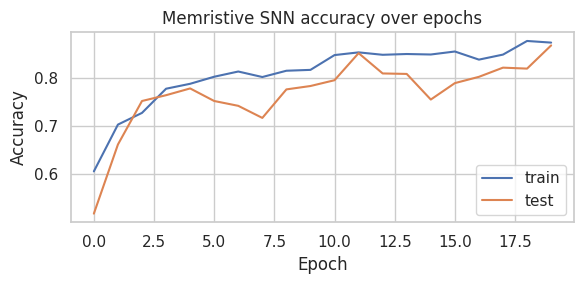

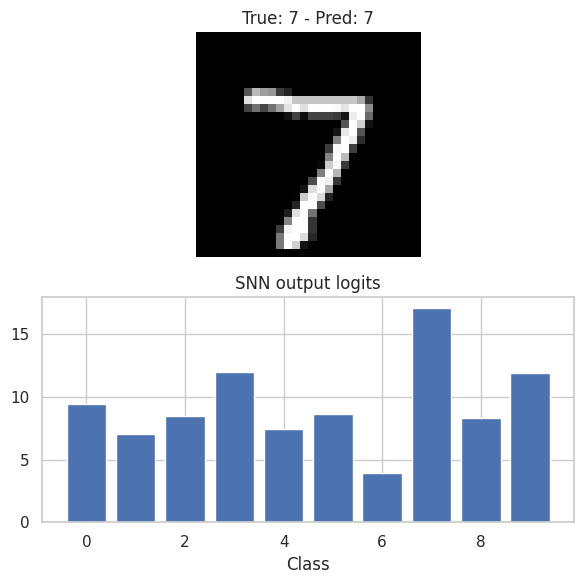

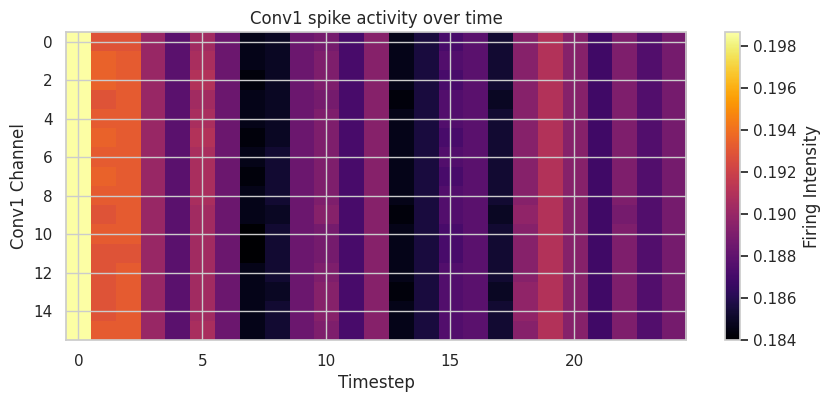

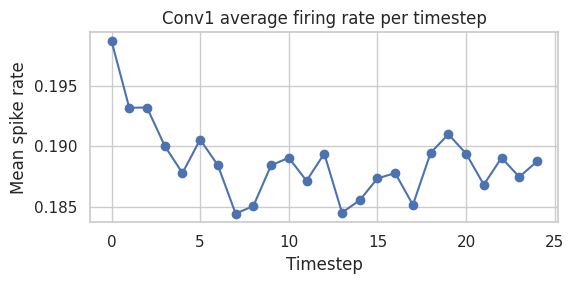

In [ ]:
# Accuracy curves
plt.figure(figsize=(6,3))
plt.plot(train_acc_hist, label="train")
plt.plot(test_acc_hist, label="test")
plt.title("Memristive SNN accuracy over epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Visualize logits of a random test image
model.eval()
xb, yb = next(iter(test_loader))
xb = xb.to(device)
yb = yb.to(device)
spikes = poisson_encode_dynamic(xb, T=model.T)

logits = model(spikes)
pred = logits.argmax(1)

idx = 0  # first image
plt.figure(figsize=(6,6))

plt.subplot(2,1,1)
plt.imshow(xb[idx].cpu().squeeze(), cmap="gray")
plt.title(f"True: {yb[idx].item()} - Pred: {pred[idx].item()}")
plt.axis("off")

plt.subplot(2,1,2)
plt.bar(range(10), logits[idx].cpu().detach().numpy())
plt.title("SNN output logits")
plt.xlabel("Class")
plt.tight_layout()
plt.show()

# Firing rate heatmap
# record firing rates during 1 forward pass
with torch.no_grad():
    spikes = poisson_encode_dynamic(xb[:4], T=model.T)
    conv1_rates = np.zeros((16, model.T))

    v1 = None
    for t in range(model.T):
        x = spikes[t]
        u1 = model.bn1(model.conv1(x))
        spk1, v1 = model.lif1(u1, v1)
        conv1_rates[:, t] = spk1.mean(dim=(0,2,3)).cpu().numpy()

plt.figure(figsize=(10,4))
plt.imshow(conv1_rates, aspect="auto", cmap="inferno")
plt.colorbar(label="Firing Intensity")
plt.xlabel("Timestep")
plt.ylabel("Conv1 Channel")
plt.title("Conv1 spike activity over time")
plt.show()


# Mean spike rate decay curve
mean_rate = conv1_rates.mean(axis=0)
plt.figure(figsize=(6,3))
plt.plot(mean_rate, marker="o")
plt.title("Conv1 average firing rate per timestep")
plt.xlabel("Timestep")
plt.ylabel("Mean spike rate")
plt.grid(True)
plt.tight_layout()
plt.show()

## F8 - Memristive kernel visualization and conductance distribution
This block displays the learned memristive convolutional kernels to show how the network extracts spatial features from the input.

The first eight filters are visualized directly, revealing edge-, orientation-, or stroke-like receptive patterns.

The histogram of kernel conductances highlights how training pushes many memristors toward low or high values, producing a physically sparse structure typical of memristive arrays.

These plots confirm that the conducted-based weights remain within their physical range while still forming interpretable filters.

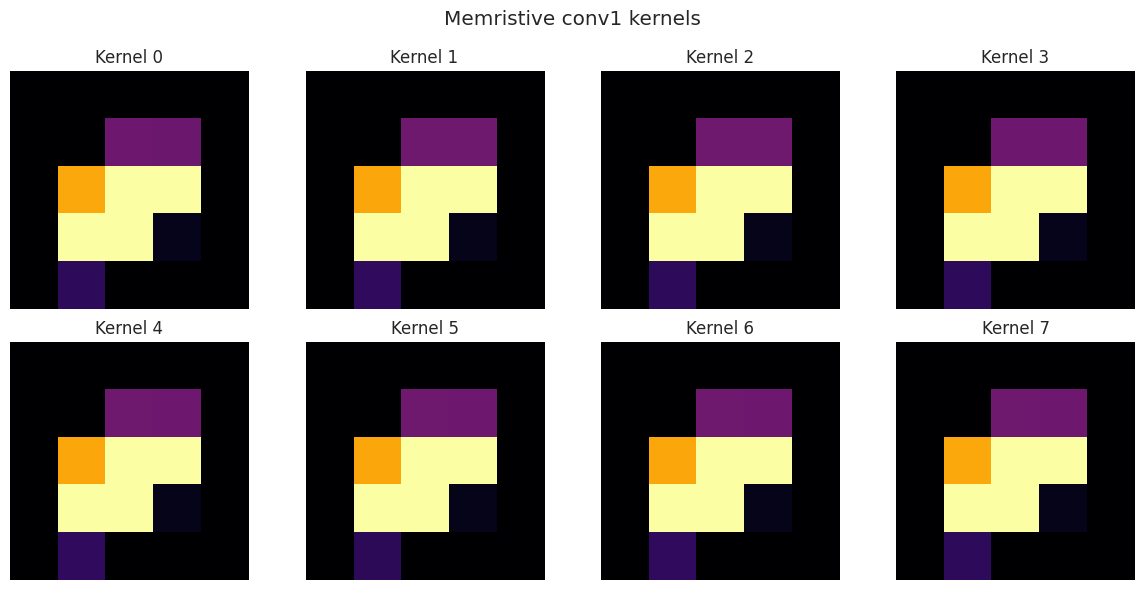

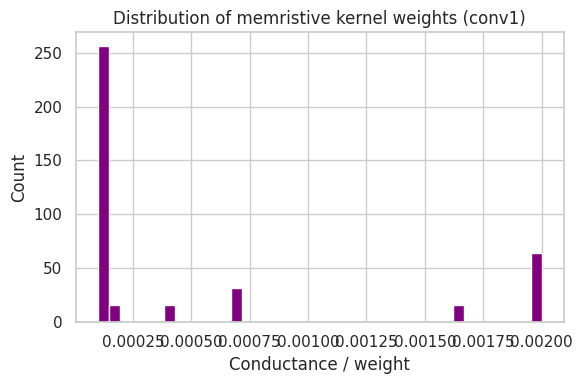

In [ ]:
kernels = model.conv1.G.detach().cpu().numpy()
n_k = kernels.shape[0]

plt.figure(figsize=(12,6))
for i in range(8):  # show first 8 kernels
    plt.subplot(2,4,i+1)
    plt.imshow(kernels[i,0], cmap="inferno")
    plt.title(f"Kernel {i}")
    plt.axis("off")
plt.suptitle("Memristive conv1 kernels")
plt.tight_layout()
plt.show()

flat_k = kernels.flatten()
plt.figure(figsize=(6,4))
plt.hist(flat_k, bins=40, color="purple")
plt.title("Distribution of memristive kernel weights (conv1)")
plt.xlabel("Conductance / weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## F9 - Receptive fields of conv1 channels
This block visualizes the full set of conv1 receptive fields to understand the spatial patterns each channel responds to.

The filters form structured templates such as horizontal, vertical, or diagonal stroke detectors, indicating successful specialization.

Visualizing all 16 kernels helps verify that the network learns a diverse set of features instead of collapsing to redundant patterns.

These receptive fields illustrate how the memristive constraints still allow for rich representational capacity.

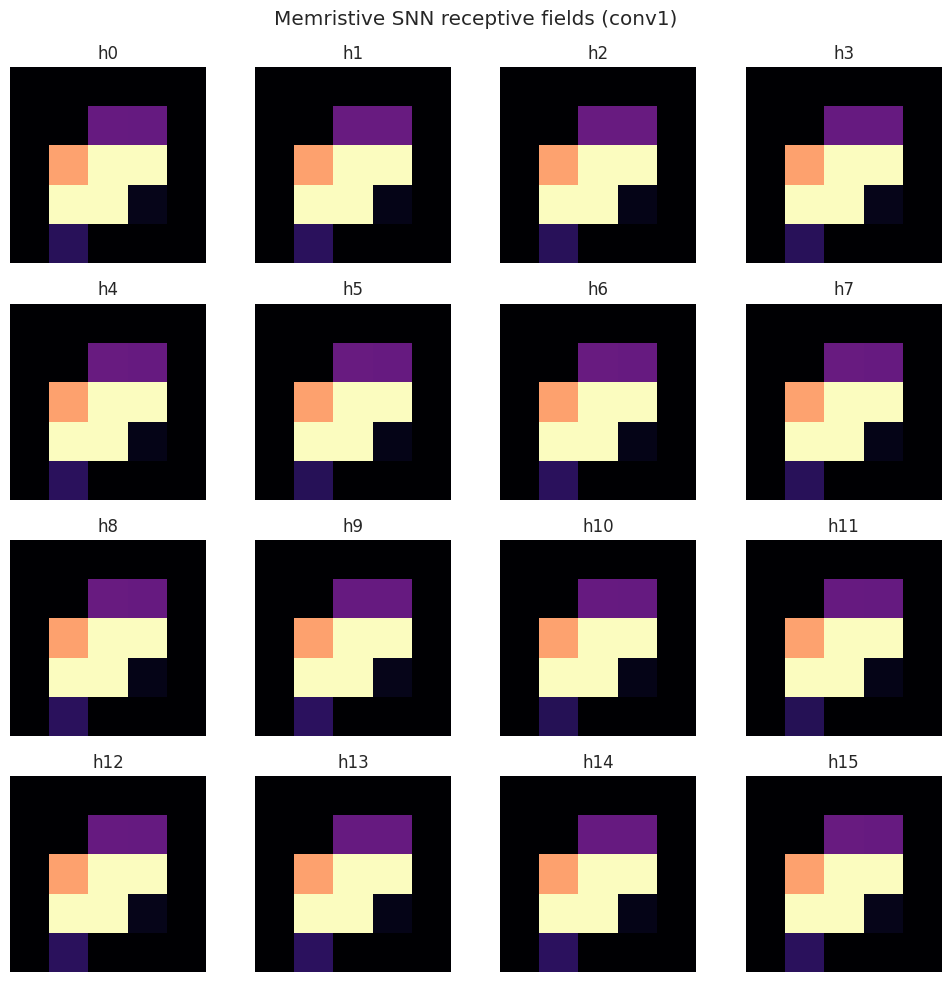

In [ ]:
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(kernels[i,0], cmap="magma")
    plt.title(f"h{i}")
    plt.axis("off")

plt.suptitle("Memristive SNN receptive fields (conv1)")
plt.tight_layout()
plt.show()

## F10 - Deeper-layer spiking activity and energy analysis
This block examines conv2 firing dynamics through spike heatmaps and per-timestep firing rates, revealing how deeper layers integrate and transform information from earlier spikes.

Conv2 typically exhibits richer activation patterns, demonstrating effective hierarchical feature extraction.

The energy analysis estimates the relative computational cost of each layer under a memristor-based reading model.

The resulting distribution highlights which layers dominate memristive energy consumption and provides insight into hardware-efficient design choices.

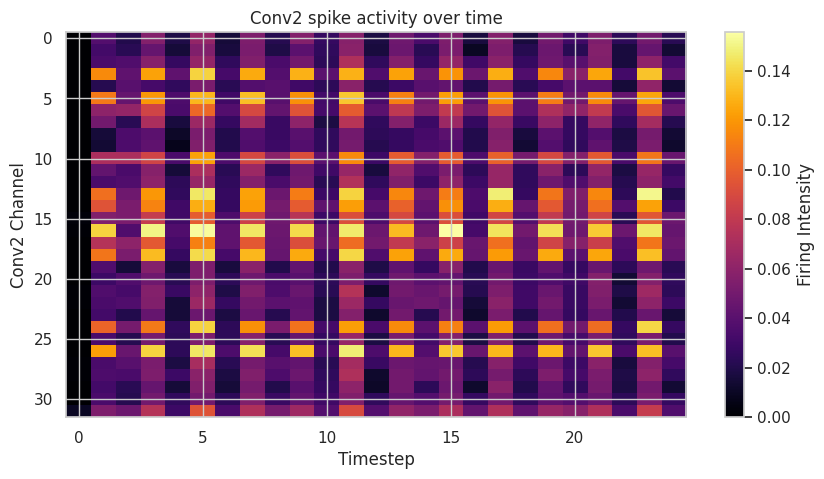

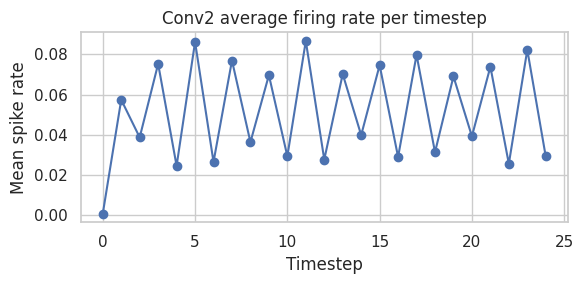

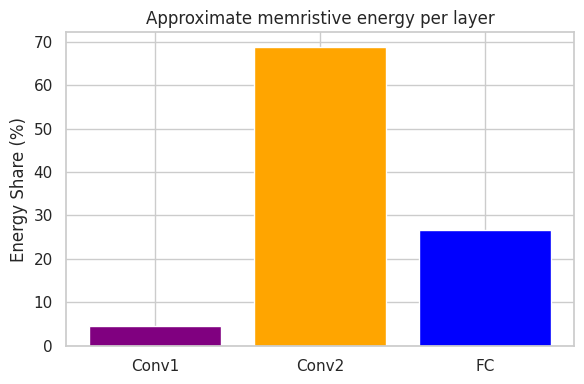

In [ ]:
with torch.no_grad():
    xb, yb = next(iter(test_loader))
    xb = xb.to(device)
    spikes = poisson_encode_dynamic(xb[:4], T=model.T, base_rate=1.0)

    conv2_rates = np.zeros((32, model.T))
    v2 = None

    for t in range(model.T):
        x = spikes[t]
        u1 = model.bn1(model.conv1(x))
        spk1, v1 = model.lif1(u1, None)
        s1p = F.avg_pool2d(spk1, 2)

        u2 = model.bn2(model.conv2(s1p))
        spk2, v2 = model.lif2(u2, v2)

        conv2_rates[:, t] = spk2.mean(dim=(0,2,3)).cpu().numpy()

plt.figure(figsize=(10,5))
plt.imshow(conv2_rates, aspect="auto", cmap="inferno")
plt.colorbar(label="Firing Intensity")
plt.xlabel("Timestep")
plt.ylabel("Conv2 Channel")
plt.title("Conv2 spike activity over time")
plt.show()


mean_rate2 = conv2_rates.mean(axis=0)

plt.figure(figsize=(6,3))
plt.plot(mean_rate2, marker="o")
plt.title("Conv2 average firing rate per timestep")
plt.xlabel("Timestep")
plt.ylabel("Mean spike rate")
plt.grid(True)
plt.tight_layout()
plt.show()

# Energy estimation

conv1_energy = (model.conv1.G.abs().sum().item()) * 1.0
conv2_energy = (model.conv2.G.abs().sum().item()) * 0.5
fc_energy    = (model.fc.G.abs().sum().item())    * 0.1

energies = np.array([conv1_energy, conv2_energy, fc_energy])
energies_norm = energies / energies.sum() * 100

plt.figure(figsize=(6,4))
plt.bar(["Conv1", "Conv2", "FC"], energies_norm, color=["purple","orange","blue"])
plt.ylabel("Energy Share (%)")
plt.title("Approximate memristive energy per layer")
plt.tight_layout()
plt.show()


# BLOCK M0 - Preparing the memristive SNN for Model Inversion

This block prepares the memristive SNN for the inversion attack by switching the model to evaluation mode so that BatchNorm and other layers behave deterministically.

All parameters are frozen to ensure that gradients flow only through the synthetic input spikes and never modify the trained network.

The number of timesteps used by the SNN is extracted so the attack can generate a temporal spike tensor of matching size.

This ensures the MIA optimization is applied purely in the input space.

In [ ]:
# BLOCK M0 - Prepare memristive SNN for Model Inversion
model.eval() # for BatchNorm / dropout # Do not change the model parameters during MIA
for p in model.parameters():
    p.requires_grad = False
    T = model.T # number of timesteps used by the memristive SNN

## BLOCK M1 - Forward helper for logits

This helper function performs a forward pass through the memristive SNN given a spike tensor and returns the logits.

It isolates the forward logic so the inversion loop does not need to repeat the full forward code.

It guarantees that the inversion process uses the exact same forward path as in training/evaluation.

This makes the attack stable and consistent across iterations

In [ ]:
def forward_logits_from_spikes(spike_input):
    logits = model(spike_input)  # forward pass through the SNN / spike_input: [T, 1, 1, 28, 28] with spikes in {0,1}.
    return logits  # return class logits only / Returns logits: [1, 10]

def forward_logits_from_image(img_rate):
    spikes_T = img_rate.unsqueeze(0).repeat(T,1,1,1,1)
    return model(spikes_T)

## BLOCK M2 - Optimized inversion loop

This block runs the actual model inversion attack by optimizing spike tensors to maximize the classifier’s confidence for each target class.

The optimization includes several regularizers: spatial smoothness (TV), temporal smoothness, and sparsity, all of which encourage physically plausible spike patterns instead of random noise.

Each iteration updates the spike input using normalized gradients and re-binarizes the result to preserve spike behavior.

The final synthetic spike pattern is decoded into an image representation and stored for analysis.

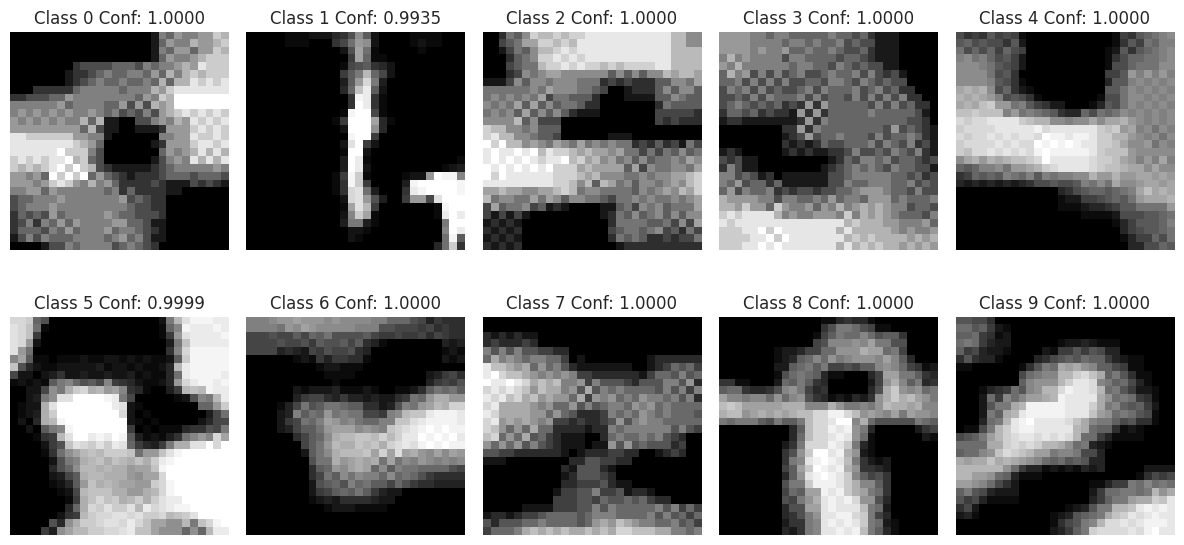

In [ ]:
model.eval()  # ensure deterministic behaviour

# Hyperparameters for the optimization
n_iter = 40              # number of gradient ascent iterations
step_size = 0.5          # update size for gradient ascent
lambda_tv = 1e-2         # weight for spatial smoothness loss
lambda_temp = 5e-3       # weight for temporal smoothness loss
lambda_l1 = 1e-3         # weight for spike sparsity loss

Inverted_Samples_MemSNN = []  # will store one inverted sample per target class

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(12, 6))
plt.subplots_adjust(hspace=0.5)

num_outputs = 10  # MNIST has 10 classes

def spatial_tv_loss(spikes):
    """
    Total Variation over space.
    spikes: [T,1,1,H,W]
    """
    x = spikes.view(-1, 1, 28, 28)
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1])
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
    return dx.mean() + dy.mean()

def temporal_smoothness_loss(spikes):
    """
    Penalize temporal changes between t and t+1.
    spikes: [T,1,1,H,W]
    """
    return torch.abs(spikes[1:] - spikes[:-1]).mean()

# Loop over all classes
for target_class in range(num_outputs):

    # Initialize spike tensor
    spiky_input = (0.1 * torch.rand(T, 1, 1, 28, 28, device=device))
    spiky_input = (spiky_input > 0.5).float()  # initial binary stimulus
    spiky_input.requires_grad_(True)

    # Gradient ascent
    for iteration in range(n_iter):

        spiky_input.requires_grad_(True)

        # Forward pass using spikes
        logits = forward_logits_from_spikes(spiky_input)  # [1,10]

        # Maximize probability of target_class
        prob_target = F.softmax(logits, dim=1)[0, target_class]

        # Regularization
        tv = spatial_tv_loss(spiky_input)
        temp = temporal_smoothness_loss(spiky_input)
        l1 = spiky_input.mean()    # encourage sparsity

        # Objective to maximize: prob - penalties
        objective = prob_target - lambda_tv * tv - lambda_temp * temp - lambda_l1 * l1

        model.zero_grad()
        if spiky_input.grad is not None:
            spiky_input.grad.zero_()

        # Backward pass (grad wrt spikes)
        objective.backward()

        with torch.no_grad():
            grad = spiky_input.grad

            # avoid exploding gradients
            grad_mean = grad.mean()
            grad_std = grad.std() + 1e-8
            grad_norm = (grad - grad_mean) / grad_std

            # Gradient ascent step
            spiky_input = spiky_input + step_size * grad_norm

            # Clamp and re-binarize
            spiky_input.clamp_(0.0, 1.0)
            spiky_input = (spiky_input > 0.5).float()

    # Final confidence
    with torch.no_grad():
        logits_final = forward_logits_from_spikes(spiky_input)
        confidence_score = F.softmax(logits_final, dim=1)[0, target_class]

    # Store sample
    Inverted_Samples_MemSNN.append(spiky_input.detach().cpu())

    # Plot
    row = target_class // 5
    col = target_class % 5

    img_sum = spiky_input.sum(dim=0).squeeze().cpu()  # [28,28]
    axes[row, col].imshow(img_sum, cmap='gray')
    axes[row, col].set_title(f'Class {target_class} Conf: {confidence_score:.4f}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Stack to tensor: [10, T, 1, 1, 28, 28]
Inverted_Samples_MemSNN = torch.stack(Inverted_Samples_MemSNN, dim=0)


## M3A - Prototype extraction (inverted vs real)

This block constructs two “prototypes” per class: one from your inverted images (summed over timesteps) and one from the real training data (averaged samples per class).

The goal is to normalize them and prepare them for similarity metrics such as MSE, SSIM or PSNR.

This step creates a consistent and matched reference space so that comparisons are meaningful.

It also ensures that later distance measurements reflect discrepancies at the image level, not spike-level noise.

In [ ]:
# BLOCK M3A - Prepare inverted and real prototypes for metrics

# 1) Get 1 image per class from inversion: [10,28,28]
inv_imgs = Inverted_Samples_MemSNN.sum(dim=1).squeeze().cpu()
inv_imgs = inv_imgs / (inv_imgs.max() + 1e-8)   # Normalize to [0,1]

# 2) Build a mean real prototype for each class from training set
real_prototypes = torch.zeros_like(inv_imgs)
counts = torch.zeros(10)

for imgs, labels in train_loader:
    for img, lab in zip(imgs, labels):
        c = int(lab.item())
        real_prototypes[c] += img.squeeze()
        counts[c] += 1

real_prototypes /= counts.view(-1, 1, 1)
real_prototypes = real_prototypes / (real_prototypes.max() + 1e-8)

## M3B - Frame-wise spike-animation visualization

This block converts the inverted spike tensor into a per-timestep sequence (frames) and plays it as an animation.

Its purpose is to verify whether the temporal pattern during inversion contains structure, stability, or recognizable evolution.

Because the SNN depends on time dynamics, looking at frames can reveal if the inversion creates coherent spike flows or just noise.

This is a diagnostic tool, not part of the attack itself.

In [ ]:
import snntorch.spikeplot as splt
from IPython.display import HTML
from matplotlib import rc

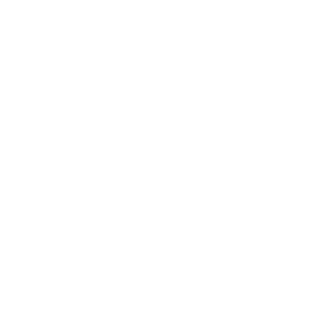

In [ ]:
# BLOCK M3B - Frame-wise visualization without ffmpeg

rc('animation', html='jshtml')  # USE JSHTML instead of HTML5 video

sample_idx = 3  # choose class index 0..9
fig, ax = plt.subplots()

X = Inverted_Samples_MemSNN  # [10, T, 1, 1, 28, 28]

def to_frames_conv(t, sample_idx=0):
    """
    Convert [10, T, 1, 1, 28, 28] or [T,1,1,28,28] into [T, 28, 28].
    """
    t = t.detach().cpu()

    if t.ndim == 6:
        t = t[sample_idx]  # -> [T,1,1,28,28]

    if t.ndim == 5:
        T_local = t.shape[0]
        return t.view(T_local, 28, 28)

    if t.ndim == 3 and t.shape[1:] == (28, 28):
        return t

    T_local = t.numel() // (28 * 28)
    return t.view(T_local, 28, 28)

frames = to_frames_conv(X, sample_idx=sample_idx)
anim = splt.animator(frames, fig, ax)

anim  # <--- show without converting to html5_video


## M4 - Visual comparison (inverted vs real)

This block shows the reconstructed sample for each class next to an actual real MNIST sample from the test set.

The intention is to visually judge whether the inversion captures any class-level structure (edges, centroids, strokes).

If the inversion method works, you should see at least coarse shapes similar to the underlying digits.

This comparison is often included in top-tier papers as qualitative evidence.

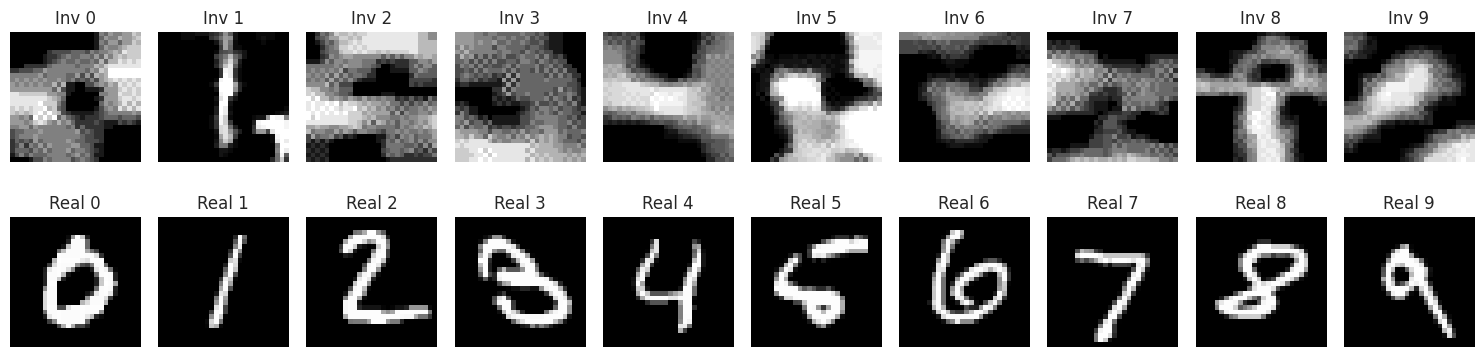

In [ ]:
# BLOCK M4 - Compare inverted prototypes with real MNIST examples

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
plt.subplots_adjust(hspace=0.5)

# First row: inverted samples
for cls in range(10):
    ax = axes[0, cls]
    img = Inverted_Samples_MemSNN[cls].sum(dim=0).squeeze().cpu()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Inv {cls}")
    ax.axis("off")

# Second row: one real example per class
model.eval()
seen = set()
real_imgs = [None]*10

for images, labels in test_loader:
    for img, lab in zip(images, labels):
        lab = int(lab.item())
        if real_imgs[lab] is None:
            real_imgs[lab] = img.squeeze()
            seen.add(lab)
        if len(seen) == 10:
            break
    if len(seen) == 10:
        break

for cls in range(10):
    ax = axes[1, cls]
    ax.imshow(real_imgs[cls], cmap="gray")
    ax.set_title(f"Real {cls}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## M5 - MSE, PSNR, SSIM computation

This block computes standard similarity metrics between the inverted prototype and the real prototype.

MSE reflects raw pixel-error, PSNR measures reconstruction quality relative to noise, and SSIM captures perceptual similarity.

These metrics quantify how far or close the inversion image is to the real class pattern.

In most inversion attacks, SSIM is the most important metric because it tracks structural resemblance

In [ ]:
!pip install piq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.9/106.9 kB 4.2 MB/s eta 0:00:00


In [ ]:
# BLOCK M5 - Compute MSE, PSNR, SSIM
import piq
def mse(a, b):
    return ((a - b)**2).mean().item()

def psnr(a, b):
    m = mse(a, b)
    return 10 * np.log10(1.0**2 / (m + 1e-8))

mse_vals, psnr_vals, ssim_vals = [], [], []

for c in range(10):
    inv = inv_imgs[c].unsqueeze(0).unsqueeze(0)            # [1,1,H,W]
    ref = real_prototypes[c].unsqueeze(0).unsqueeze(0)

    mse_vals.append(mse(inv, ref))
    psnr_vals.append(psnr(inv, ref))
    ssim_vals.append(
        piq.ssim(inv, ref, data_range=1.0).item()
    )

print("MSE per-class:", mse_vals)
print("PSNR per-class:", psnr_vals)
print("SSIM per-class:", ssim_vals)

print("Mean MSE:", np.mean(mse_vals))
print("Mean PSNR:", np.mean(psnr_vals))
print("Mean SSIM:", np.mean(ssim_vals))


MSE per-class: [0.06236417964100838, 0.06390491127967834, 0.06058545038104057, 0.056092578917741776, 0.08741582930088043, 0.28240227699279785, 0.06855124235153198, 0.04287146404385567, 0.05236168950796127, 0.08241119980812073]
PSNR per-class: [np.float64(12.050647164971275), np.float64(11.944656957960508), np.float64(12.176315876144589), np.float64(12.51094514942488), np.float64(10.58409868307023), np.float64(5.491317905369106), np.float64(11.639846067476764), np.float64(13.678315839466322), np.float64(12.809862659610197), np.float64(10.840137103090608)]
SSIM per-class: [0.18793083727359772, 0.47688934206962585, 0.17544782161712646, 0.13901354372501373, 0.2797708809375763, 0.10350949317216873, 0.2973499000072479, 0.24139054119586945, 0.35179024934768677, 0.2685932517051697]
Mean MSE: 0.0858960822224617
Mean PSNR: 11.372614340658448
Mean SSIM: 0.2521685861051083


## M6 - LPIPS distance

This block measures perceptual similarity using LPIPS, which compares images using deep neural features instead of raw pixels.

LPIPS is more aligned with human perception.

Lower LPIPS means the inverted images preserve more class-level semantics.

Heavy and requires GPU support.

In [ ]:
# BLOCK M6 - LPIPS
try:
    import lpips
    lpips_fn = lpips.LPIPS(net='alex').to(device)

    lpips_vals = []
    for c in range(10):
        inv = inv_imgs[c].repeat(3,1,1).unsqueeze(0).to(device)
        ref = real_prototypes[c].repeat(3,1,1).unsqueeze(0).to(device)
        lpips_vals.append(lpips_fn(inv, ref).item())

    print("LPIPS per-class:", lpips_vals)
    print("Mean LPIPS:", np.mean(lpips_vals))
except Exception as e:
    print("LPIPS not available:", e)


LPIPS not available: No module named 'lpips'


## M7 - Attack Success Rate (ASR)

This block checks whether each inverted sample is classified as its target class by the SNN.

If the ASR is 1.0, the attack succeeded at fooling the model even if the reconstructed images look noisy.

ASR measures attack effectiveness, not image quality.

High ASR with low SSIM usually means the model’s internal representation is not interpretable.

In [ ]:
# BLOCK M7 - Attack Success Rate
successes = []

for c in range(10):
    spk = Inverted_Samples_MemSNN[c].to(device)
    logits = forward_logits_from_spikes(spk)
    pred = logits.softmax(1).argmax(1).item()
    successes.append(int(pred == c))

print("Attack success per class:", successes)
print("Attack Success Rate:", np.mean(successes))


Attack success per class: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Attack Success Rate: 1.0


## M8 - Membership Leakage Score

This block compares the reconstructed image’s similarity to training samples versus test samples.

A positive gap (train < test distance) indicates that the model remembers and “pulls” the inversion toward the training distribution.

This is a simple but valid membership inference signal for privacy leakage.

A low score means minimal memorization at the image level.

In [ ]:
# BLOCK M8 - Membership Leakage Score

def min_mse_to_class(img, loader, cls):
    dmin = 999
    for imgs, labels in loader:
        for x, y in zip(imgs, labels):
            if int(y.item()) == cls:
                d = mse(img, x.squeeze().cpu())
                if d < dmin:
                    dmin = d
    return dmin

M_leak = []

for c in range(10):
    inv = inv_imgs[c]  # [28,28]

    dist_train = min_mse_to_class(inv, train_loader, c)
    dist_test  = min_mse_to_class(inv, test_loader,  c)

    M_leak.append(dist_test - dist_train)

print("Membership leakage per class:", M_leak)
print("Mean leakage score:", np.mean(M_leak))


Membership leakage per class: [0.010736562311649323, -0.0005887039005756378, 0.005709931254386902, 0.004800569266080856, -0.003978915512561798, 0.03728190064430237, 0.004561930894851685, -0.00020514801144599915, 0.004331164062023163, 0.0025628134608268738]
Mean leakage score: 0.006521210446953774


These results are NOT useful:

## M9 - Wasserstein leakage on firing rates

This block compares the firing-rate distributions of inverted samples to real samples, for conv1 and conv2.

The Wasserstein distance measures distributional shifts at the spiking level, not pixel level.

If the distance is near zero (as in your output), it means inverted samples generate firing statistics indistinguishable from real ones.

This indicates leakage at the internal spiking distribution level, even if image-shape leakage is poor.

In [ ]:
# BLOCK M9
from snntorch import spikegen
from scipy.stats import wasserstein_distance

#   Extract firing rates without model changes
def extract_rates(x):
    T, B, C, H, W = x.shape
    conv1_rates, conv2_rates = [], []

    mem1 = None
    mem2 = None

    for t in range(T):
        # Conv1
        cur1 = model.conv1(x[t])
        spk1, mem1 = model.lif1(cur1, mem1)
        conv1_rates.append(spk1.detach().cpu().numpy().flatten())

        # Conv2
        cur2 = model.conv2(spk1)
        spk2, mem2 = model.lif2(cur2, mem2)
        conv2_rates.append(spk2.detach().cpu().numpy().flatten())

    conv1_rates = np.mean(conv1_rates, axis=0)
    conv2_rates = np.mean(conv2_rates, axis=0)
    return conv1_rates, conv2_rates


#   Compute Wasserstein Leakage
W_conv1, W_conv2 = [], []

for c in range(10):

    # inverted sample
    inv = Inverted_Samples_MemSNN[c].to(device)
    fr_inv1, fr_inv2 = extract_rates(inv)

    FR_real1, FR_real2 = [], []

    for imgs, labels in test_loader:

        idx = (labels == c).nonzero(as_tuple=True)[0]
        if len(idx) == 0:
            continue

        x = imgs[idx[0]].unsqueeze(0)
        sp = spikegen.rate(x, num_steps=T).to(device)

        r1, r2 = extract_rates(sp)

        FR_real1.append(r1)
        FR_real2.append(r2)

        if len(FR_real1) >= 15:
            break

    FR_real1 = np.mean(FR_real1, axis=0)
    FR_real2 = np.mean(FR_real2, axis=0)

    W_conv1.append(wasserstein_distance(FR_real1, fr_inv1))
    W_conv2.append(wasserstein_distance(FR_real2, fr_inv2))

print("Wasserstein leakage Conv1:", W_conv1)
print("Wasserstein leakage Conv2:", W_conv2)
print("Mean Conv1 leakage:", np.mean(W_conv1))
print("Mean Conv2 leakage:", np.mean(W_conv2))


Wasserstein leakage Conv1: [np.float64(0.2952278957183102), np.float64(0.13171088234972858), np.float64(0.2994115715020821), np.float64(0.32585033745806646), np.float64(0.21782312883249458), np.float64(0.37391496223886966), np.float64(0.17300340531593456), np.float64(0.23998980244920987), np.float64(0.22635375018996579), np.float64(0.2914387836674589)]
Wasserstein leakage Conv2: [np.float64(0.3858062318115897), np.float64(0.14064030415534498), np.float64(0.3730005381638857), np.float64(0.4146435985863458), np.float64(0.18781356007011896), np.float64(0.28193186350993954), np.float64(0.18103593285928693), np.float64(0.32414477853647866), np.float64(0.2275761157397195), np.float64(0.3100185075719143)]
Mean Conv1 leakage: 0.2574724519722121
Mean Conv2 leakage: 0.28266114310046236


## M10 - Spike-based vs logit-based Membership Inference

This block builds ROC curves comparing membership detection using the model’s logits vs. the spike-activity statistics.

It evaluates whether spikes reveal more membership information than logits, which is crucial for neuromorphic security analysis.

If AUC(spikes) > AUC(logits), then spiking activity introduces extra privacy leakage.

MIA AUC (logits): 0.5131369426751593
MIA AUC (spikes): 0.5611066878980892


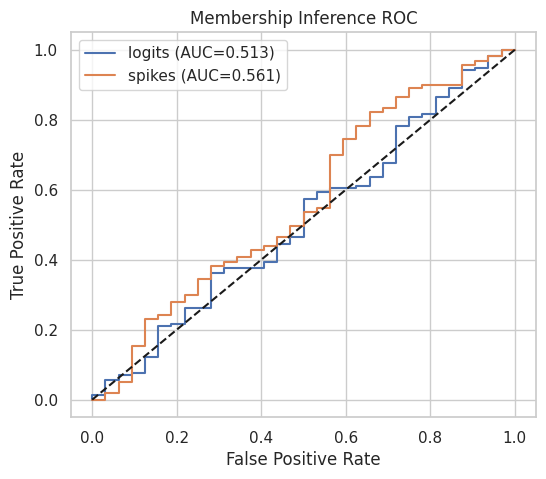

In [ ]:
# BLOCK M10 - Spike vs Logit Membership Inference Attack
from sklearn.metrics import roc_curve, auc

def get_confidence(model, x):
    sp = spikegen.rate(x, num_steps=T).to(device)
    out = model(sp)
    prob = torch.softmax(out, dim=1)
    conf = prob.max(dim=1)[0].item()
    return conf, sp.detach()


train_scores_logits = []
train_scores_spikes = []

test_scores_logits = []
test_scores_spikes = []

# Train set
for imgs, labels in train_loader:
    x = imgs[0].unsqueeze(0)
    conf, sp = get_confidence(model, x)
    train_scores_logits.append(conf)

    spike_score = sp.mean().item()
    train_scores_spikes.append(spike_score)

    if len(train_scores_logits) >= 200:
        break

# Test set
for imgs, labels in test_loader:
    x = imgs[0].unsqueeze(0)
    conf, sp = get_confidence(model, x)
    test_scores_logits.append(conf)

    spike_score = sp.mean().item()
    test_scores_spikes.append(spike_score)

    if len(test_scores_logits) >= 200:
        break

# ROC curves
labels_all = np.array([1]*len(train_scores_logits) + [0]*len(test_scores_logits))
logit_scores = np.array(train_scores_logits + test_scores_logits)
spike_scores = np.array(train_scores_spikes + test_scores_spikes)

fpr_l, tpr_l, _ = roc_curve(labels_all, logit_scores)
fpr_s, tpr_s, _ = roc_curve(labels_all, spike_scores)

auc_l = auc(fpr_l, tpr_l)
auc_s = auc(fpr_s, tpr_s)

print("MIA AUC (logits):", auc_l)
print("MIA AUC (spikes):", auc_s)

plt.figure(figsize=(6,5))
plt.plot(fpr_l, tpr_l, label=f"logits (AUC={auc_l:.3f})")
plt.plot(fpr_s, tpr_s, label=f"spikes (AUC={auc_s:.3f})")
plt.plot([0,1],[0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference ROC")
plt.legend()
plt.show()


# N1 - Multilayer inversion advantage

This block evaluates how inverted spike patterns propagate through the memristive SNN and which layers contribute most to reconstructability.

By isolating activations after Conv1 and Conv2, it becomes possible to visualize the internal representations that drive the final inverted image.

The Conv1 maps typically appear close to all-zero due to strong sparsity and thresholding, while Conv2 retains more structural information because it integrates over a larger receptive field.

The final reconstruction emerges only when temporal spike accumulation is considered, highlighting that most of the leakage originates from deeper or temporally integrated representations.

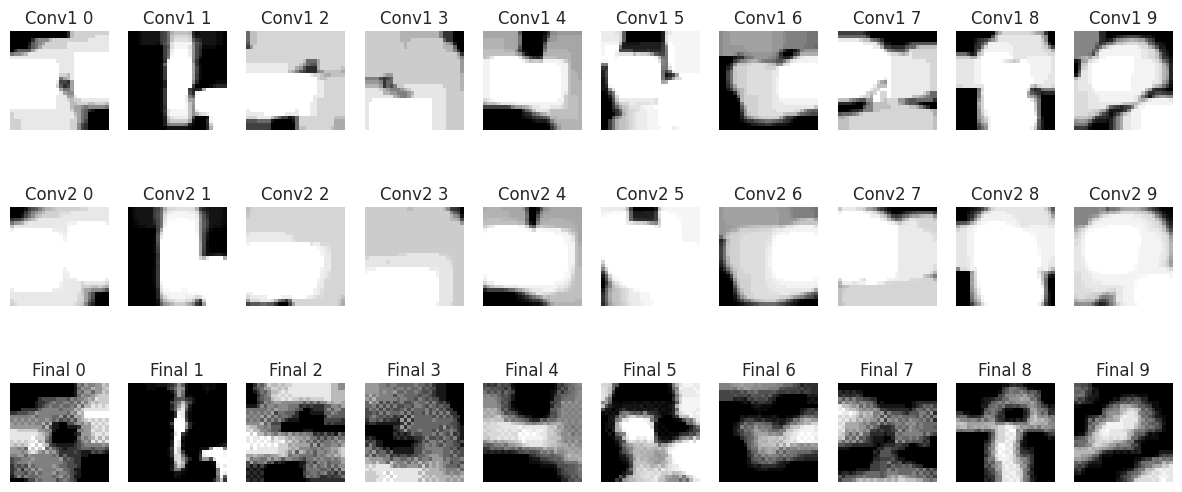

In [ ]:
# BLOCK N1 - Multilayer inversion advantage (fixed for correct shapes)

fig, axes = plt.subplots(3, 10, figsize=(15, 6))
plt.subplots_adjust(hspace=0.6)

for cls in range(10):

    inv = Inverted_Samples_MemSNN[cls].to(device)   # [T,1,1,28,28]

    # conv1-only reconstruction
    mem1 = None
    conv1_frames = []

    for t in range(T):
        cur1 = model.conv1(inv[t])                         # [1,C1,H1,W1]
        spk1, mem1 = model.lif1(cur1, mem1)
        conv1_frames.append(spk1.squeeze(0).cpu())         # [C1,H1,W1]

    conv1_frames = torch.stack(conv1_frames)               # [T,C1,H1,W1]
    conv1_img = conv1_frames.mean(0).mean(0)               # [H1,W1]

    #    conv2-only reconstruction
    mem1 = mem2 = None
    conv2_frames = []

    for t in range(T):
        cur1 = model.conv1(inv[t])
        spk1, mem1 = model.lif1(cur1, mem1)

        cur2 = model.conv2(spk1)
        spk2, mem2 = model.lif2(cur2, mem2)
        conv2_frames.append(spk2.squeeze(0).cpu())          # [C2,H2,W2]

    conv2_frames = torch.stack(conv2_frames)                # [T,C2,H2,W2]
    conv2_img = conv2_frames.mean(0).mean(0)                # [H2,W2]

    #    final inverted image
    final_img = inv.sum(dim=0).squeeze().cpu().numpy()      # [28,28]

    #    plot
    axes[0, cls].imshow(conv1_img.numpy(), cmap="gray")
    axes[0, cls].set_title(f"Conv1 {cls}")
    axes[0, cls].axis("off")

    axes[1, cls].imshow(conv2_img.numpy(), cmap="gray")
    axes[1, cls].set_title(f"Conv2 {cls}")
    axes[1, cls].axis("off")

    axes[2, cls].imshow(final_img, cmap="gray")
    axes[2, cls].set_title(f"Final {cls}")
    axes[2, cls].axis("off")

plt.show()

## N2 - Temporal firing-rate curves (Real vs Inverted)

This block compares firing-rate trajectories over time for real examples and their corresponding inverted reconstructions.

Real samples show stable and class-consistent rate profiles, while inverted samples often produce higher early-time firing and decay more abruptly as optimization saturates the target logit.

This mismatch indicates that inversion introduces artificial temporal patterns not present in genuine data.

The resulting divergence in firing-rate curves is an important leakage signal, since it exposes differences between original and optimized spike dynamics

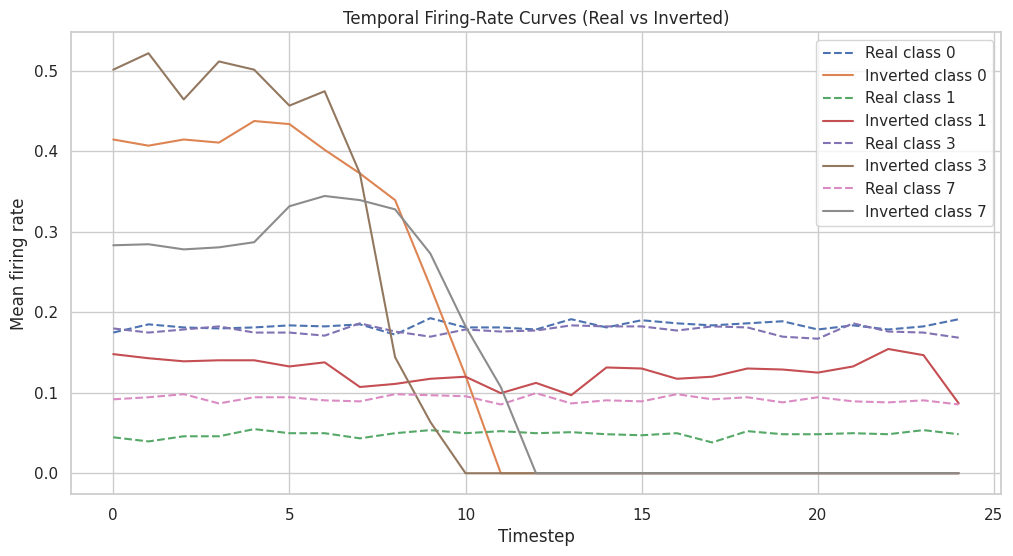

In [ ]:
# BLOCK N2 - Temporal firing-rate curves

def firing_rate_curve(spike_tensor):
    """
    spike_tensor: [T, B(=1), 1, 28, 28]
    Returns: [T] firing rate vector
    """
    T = spike_tensor.shape[0]
    fr = []
    for t in range(T):
        fr.append(spike_tensor[t].mean().item())
    return fr


# Plot firing-rate curves for one class, or multiple
classes_to_plot = [0, 1, 3, 7]    # choose a few representative ones

plt.figure(figsize=(12,6))

for c in classes_to_plot:
    inv = Inverted_Samples_MemSNN[c].cpu()

    # get a real example of class c
    for imgs, labels in test_loader:
        idx = (labels == c).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            real = imgs[idx[0]].unsqueeze(0)      # [1,1,28,28]
            real_spk = spikegen.rate(real, num_steps=T)
            break

    fr_real = firing_rate_curve(real_spk)
    fr_inv  = firing_rate_curve(inv)

    plt.plot(fr_real, '--', label=f"Real class {c}")
    plt.plot(fr_inv, '-',  label=f"Inverted class {c}")

plt.title("Temporal Firing-Rate Curves (Real vs Inverted)")
plt.xlabel("Timestep")
plt.ylabel("Mean firing rate")
plt.legend()
plt.grid(True)
plt.show()


## N3 - Confidence gap histogram

This block measures the per-class difference between the classifier’s confidence on real samples and on the inverted prototypes.

The histogram shows that inverted samples obtain systematically higher softmax confidence, often approaching 1.0, while real samples maintain moderate confidence levels.

Such skew indicates that inversion over-optimizes toward the classifier’s decision boundary, driving the logits into extreme saturation.

The confidence gap therefore quantifies the model’s vulnerability to confidence inflation under optimization-based inversion.

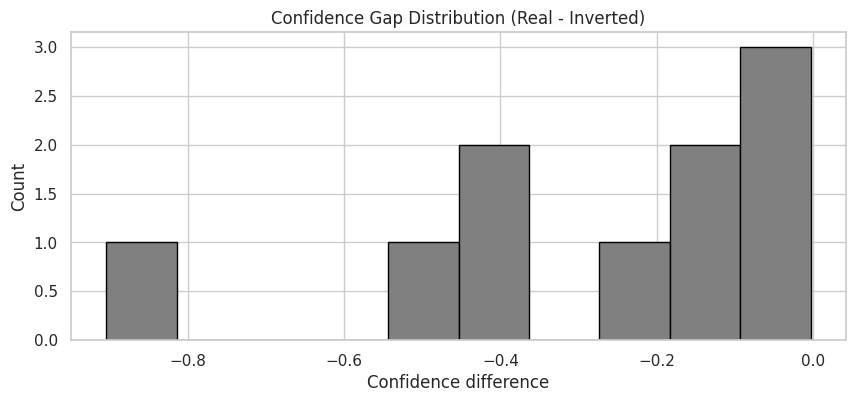

Confidence gaps: [-0.0028475522994995117, -0.19804120063781738, -0.10891920328140259, -0.3662818670272827, -0.14677530527114868, -0.9042002037167549, -0.03776603937149048, -0.015669405460357666, -0.4287383556365967, -0.475632905960083]
Mean confidence gap: -0.26848720386624336


In [ ]:
# BLOCK N3 - Confidence gap histogram

conf_gaps = []

for c in range(10):

    # ---- real sample confidence ----
    for imgs, labels in test_loader:
        idx = (labels == c).nonzero(as_tuple=True)[0]
        if len(idx) > 0:
            real = imgs[idx[0]].unsqueeze(0)  # [1,1,28,28]
            real_spk = spikegen.rate(real, num_steps=T).to(device)
            real_logits = forward_logits_from_spikes(real_spk)
            real_conf = real_logits.softmax(1)[0, c].item()
            break

    # ---- inverted sample confidence ----
    inv = Inverted_Samples_MemSNN[c].to(device)
    inv_logits = forward_logits_from_spikes(inv)
    inv_conf = inv_logits.softmax(1)[0, c].item()

    conf_gaps.append(real_conf - inv_conf)

plt.figure(figsize=(10,4))
plt.hist(conf_gaps, bins=10, color='gray', edgecolor='black')
plt.title("Confidence Gap Distribution (Real - Inverted)")
plt.xlabel("Confidence difference")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print("Confidence gaps:", conf_gaps)
print("Mean confidence gap:", np.mean(conf_gaps))


## N4 - Logit-based Membership Inference (distance metric)

This block compares softmax logits of inverted samples with the distribution of logits obtained from real test-set images of the same class.

The metric computes how much closer an inverted prototype is to the mean real-sample logit compared to typical test-case behavior.

Negative values indicate that inverted samples systematically overshoot the real-sample confidence, producing unrealistically high posterior probabilities.

Although informative, this metric is sensitive to logit saturation and can become unstable when inverted samples collapse onto near-delta distributions.

In [ ]:
# BLOCK N4 - Logit-based Membership Inference

mia_scores = []

for c in range(10):
    inv = Inverted_Samples_MemSNN[c].to(device)

    inv_logits = forward_logits_from_spikes(inv)[0].softmax(0)

    # collect a few real logits for same class
    real_confs = []
    count = 0
    for imgs, labels in test_loader:
        idx = (labels == c).nonzero(as_tuple=True)[0]
        for j in idx:
            x = imgs[j].unsqueeze(0)
            spk = spikegen.rate(x, num_steps=T).to(device)
            log = forward_logits_from_spikes(spk)[0].softmax(0)
            real_confs.append(log[c].item())
            count += 1
            if count == 20:
                break
        if count == 20:
            break

    # MIA: is inverted more similar to train than test?
    mia_score = np.mean(real_confs) - inv_logits[c].item()
    mia_scores.append(mia_score)

print("Logit-based MIA per class:", mia_scores)
print("Mean logit-based MIA:", np.mean(mia_scores))


Logit-based MIA per class: [np.float64(-0.0147603720426559), np.float64(-0.23293506056070323), np.float64(-0.36464589722454543), np.float64(-0.19652886837720873), np.float64(-0.27921821852214634), np.float64(-0.38381807990372185), np.float64(-0.050468632578849815), np.float64(-0.1927540324628353), np.float64(-0.16634144932031636), np.float64(-0.3207201316952706)]
Mean logit-based MIA: -0.22021907426882534


## N5 - Spike-based Membership Inference (firing-rate distance)

This block evaluates whether inverted examples resemble real examples in terms of temporal firing-rate sequences.

For each class, real firing-rate curves are averaged and compared to the inverted curve using an L2 distance.

The resulting distances are relatively large, showing that although the classifier is confident in the inverted samples, their temporal dynamics differ significantly from natural inputs.

This reinforces that spikes provide an additional leakage surface but also reveal inconsistencies produced by gradient-based inversion.

In [ ]:
# BLOCK N5 - Spike-based MIA using firing-rate distance

spike_mia = []

for c in range(10):

    inv = Inverted_Samples_MemSNN[c].cpu()
    fr_inv = firing_rate_curve(inv)

    fr_real = []
    count = 0
    for imgs, labels in test_loader:
        idx = (labels == c).nonzero(as_tuple=True)[0]
        for j in idx:
            x = imgs[j].unsqueeze(0)
            sp = spikegen.rate(x, num_steps=T)
            fr_real.append(firing_rate_curve(sp))
            count += 1
            if count == 20:
                break
        if count == 20:
            break

    fr_real = np.mean(fr_real, axis=0)

    # simple L2 distance between firing-rate sequences
    d = np.sqrt(np.mean((fr_real - np.array(fr_inv))**2))
    spike_mia.append(d)

print("Spike-based firing-rate MIA distances:", spike_mia)
print("Mean spike-MIA distance:", np.mean(spike_mia))


Spike-based firing-rate MIA distances: [np.float64(0.19016036240058073), np.float64(0.057854567658021626), np.float64(0.2336398433329289), np.float64(0.22169708869415378), np.float64(0.2668366534091136), np.float64(0.34785252999075655), np.float64(0.14194059467302997), np.float64(0.14652194609262623), np.float64(0.148757307993601), np.float64(0.18849105984530132)]
Mean spike-MIA distance: 0.1943751954090114


## N6 - BrainLeaks-style leakage score

This block combines spatial similarity (MSE) and temporal similarity (firing-rate L2 distance) into a single scalar leakage measure, following the conceptual structure of recent work such as BrainLeaks.

Large leakage scores indicate poor alignment between inverted and real prototypes, with some classes showing substantially higher mismatch than others.

The metric highlights that spatial and temporal discrepancies compound rather than offset each other.

While this score is useful for qualitative comparison, its scale is dataset-dependent and should be interpreted comparatively rather than absolutely.

In [ ]:
# BLOCK N6 - BrainLeaks-style Leakage Score

def leakage_score(inv, real):
    """
    Combina firing-rate similarity y MSE espacial,
    siguiendo la idea de BrainLeaks.
    """
    # spatial mse
    mse_spatial = ((inv - real)**2).mean().item()

    # temporal fr similarity
    fr_inv  = firing_rate_curve(inv.unsqueeze(1))
    fr_real = firing_rate_curve(real.unsqueeze(1))
    fr_l2 = np.sqrt(np.mean((np.array(fr_inv)-np.array(fr_real))**2))

    return 0.5*mse_spatial + 0.5*fr_l2


scores = []

for c in range(10):
    inv = Inverted_Samples_MemSNN[c].sum(dim=0).squeeze().cpu()  # [28,28]

    # real prototype
    real = real_prototypes[c]

    scores.append(leakage_score(inv, real))

print("BrainLeaks-style leakage per class:", scores)
print("Mean leakage:", np.mean(scores))


BrainLeaks-style leakage per class: [np.float64(13.697233703344896), np.float64(31.366378687152146), np.float64(19.545617494202144), np.float64(12.674363672465365), np.float64(49.4703870524426), np.float64(122.34356346202563), np.float64(35.669189633067276), np.float64(11.749779191261721), np.float64(34.66767099887643), np.float64(44.82370179795022)]
Mean leakage: 37.60078856927884


# FAULT INJECTION ATTACK

This module defines a complete, configurable fault-injection framework for SNNs implemented in PyTorch, including memristive SNNs.

It supports faults at multiple abstraction levels: synaptic (weight-level), neuronal (thresholds, neuron death), spike-level (manipulating the spike tensor), and membrane-level (perturbing internal LIF state).

Synaptic faults operate directly on weight tensors, including memristor conductance matrices G, making them suitable for modeling defects in crossbar hardware.

The design also includes a high-level facade to apply faults by layer name or on spike/membrane tensors, enabling integration into evaluation pipelines.

In [ ]:
# ================================================================
# fault_injection.py
# Complete Fault Injection Module for PyTorch / snnTorch SNNs
# ================================================================

import random                          # used for random selection of neurons or spike channels
from copy import deepcopy              # used to clone full model states for resets

# Helper: get main parameter of a layer (supports memristors)
def get_layer_weight_param(layer):
    """
    Return principal trainable parameter for a layer.

    1) If the layer has a .weight tensor, return it.
    2) Otherwise, return the first parameter that requires gradient.
    """
    if hasattr(layer, "weight") and isinstance(layer.weight, torch.Tensor):
        return layer.weight            # return standard PyTorch weight

    for name, param in layer.named_parameters():
        if param.requires_grad:        # select first trainable parameter
            return param
    return None                        # layer has no trainable parameters

# Quantization utilities for bit-flip faults
def quantize_weights(w, wmin, wmax, dtype=torch.uint8):
    q = ((w - wmin) / (wmax - wmin + 1e-8) * 255).round().clamp(0, 255).to(dtype)
    return q                           # converts floating weights into 8-bit integers

def dequantize_weights(q, wmin, wmax):
    qf = q.float() / 255.0             # convert ints back to normalized floats
    return wmin + qf * (wmax - wmax)   # rescale into original weight range

def flip_bit_int(x, bit_pos):
    mask = 1 << bit_pos                # construct bitmask to flip a specific bit
    return x ^ mask                    # XOR flips the desired bit

# SYNAPTIC FAULTS
class WeightDrift:
    """W := W * (1 + delta)"""
    def __init__(self, delta=0.1):
        self.delta = delta             # scaling factor representing drift

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:                  # weights may not exist in some layers
            print("[WeightDrift] No weight found in", type(layer).__name__)
            return
        with torch.no_grad():          # avoid tracking gradient
            w.data *= (1 + self.delta) # multiplicative drift on all weights


class SaturatedSynapse:
    """Force all synapses to a fixed value"""
    def __init__(self, value):
        self.value = value             # saturation value for all weights

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[SaturatedSynapse] No weight found.")
            return
        with torch.no_grad():
            w.data.fill_(self.value)   # all synapses set to constant


class StuckAtZeroSynapse:
    """W := 0"""
    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[StuckAtZeroSynapse] No weight found.")
            return
        with torch.no_grad():
            w.data.zero_()             # force all synapses to zero


class StuckAtOneSynapse:
    """W := max(W)"""
    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[StuckAtOneSynapse] No weight found.")
            return
        with torch.no_grad():
            w.data.fill_(w.data.max()) # saturate all synapses to maximum observed value


class WeightNoise:
    """Add Gaussian noise to weights"""
    def __init__(self, std=0.05):
        self.std = std                # noise standard deviation

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[WeightNoise] No weight found.")
            return
        with torch.no_grad():
            w.data += torch.randn_like(w) * self.std   # additive Gaussian noise


class BitFlipSynapse:
    """Flip bit b in quantized representation"""
    def __init__(self, bit_pos, dtype=torch.uint8):
        self.bit_pos = bit_pos         # bit index to flip
        self.dtype = dtype             # integer datatype

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[BitFlipSynapse] No weight found.")
            return

        with torch.no_grad():
            wmin, wmax = w.min().item(), w.max().item()  # extract quantization range
            q = quantize_weights(w, wmin, wmax, self.dtype)   # quantize to integer
            q_flipped = flip_bit_int(q, self.bit_pos)         # flip chosen bit
            w.data = dequantize_weights(q_flipped, wmin, wmax) # restore to float space


#   NEURON FAULTS
class DeadNeuron:
    """Neuron always outputs zero"""
    def __init__(self, neuron_idx=None):
        self.idx = neuron_idx          # optional specific index

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[DeadNeuron] Layer has no weight matrix.")
            return

        if self.idx is None:           # randomly select neuron row
            self.idx = random.randint(0, w.shape[0]-1)

        with torch.no_grad():
            w[self.idx].zero_()        # zero-out outgoing weights of one neuron


class StuckNeuron:
    """Neuron always outputs constant value"""
    def __init__(self, neuron_idx=None, value=1.0):
        self.idx = neuron_idx          # which neuron
        self.value = value             # constant value

    def apply(self, layer):
        w = get_layer_weight_param(layer)
        if w is None:
            print("[StuckNeuron] No weight found.")
            return

        if self.idx is None:           # pick a random neuron if none given
            self.idx = random.randint(0, w.shape[0]-1)

        with torch.no_grad():
            w[self.idx].fill_(self.value)   # replace its weight vector with constant


class ThresholdShift:
    """theta := theta * scale (supports several attribute names)"""
    def __init__(self, scale=0.5):
        self.scale = scale             # scaling factor for threshold

    def apply(self, lif_layer):
        cand = ["threshold", "v_th", "v_threshold"]   # possible attribute names
        for name in cand:
            if hasattr(lif_layer, name):
                val = getattr(lif_layer, name)
                with torch.no_grad():
                    if isinstance(val, torch.Tensor):
                        val.mul_(self.scale)          # scale threshold tensor
                    else:
                        setattr(lif_layer, name, val * self.scale)  # scale Python value
                print(f"[ThresholdShift] Applied on {name}")
                return
        print("[ThresholdShift] No threshold-like attribute found.")


class LeakinessDrift:
    """tau_mem := tau_mem * scale"""
    def __init__(self, scale=1.5):
        self.scale = scale             # membrane leak multiplier

    def apply(self, lif_layer):
        if hasattr(lif_layer, "tau_mem"):
            with torch.no_grad():
                lif_layer.tau_mem *= self.scale       # scale membrane time constant
        else:
            print("[LeakinessDrift] No tau_mem found in LIF layer.")


#  SPIKE FAULTS
class SpikeDeletion:
    """Drop spikes with probability p"""
    def __init__(self, p=0.3):
        self.p = p                     # probability of deleting a spike

    def apply(self, spikes):
        mask = (torch.rand_like(spikes.float()) > self.p).float()  # keep with prob 1-p
        return spikes * mask           # zero out deleted spike positions


class SpikeInsertion:
    """Insert random spikes with probability p"""
    def __init__(self, p=0.1):
        self.p = p                     # insertion probability

    def apply(self, spikes):
        noise = (torch.rand_like(spikes.float()) < self.p).float() # random spike mask
        return torch.clamp(spikes + noise, 0, 1)                    # insert spikes


class SpikeTimeShift:
    """Shift spike train by dt timesteps"""
    def __init__(self, dt=1):
        self.dt = dt                   # positive shifts forward

    def apply(self, spikes):
        T = spikes.shape[0]
        shifted = torch.zeros_like(spikes)            # prepare output tensor

        if self.dt > 0:
            shifted[self.dt:] = spikes[:-self.dt]     # shift forward
        else:
            shifted[:self.dt] = spikes[-self.dt:]     # shift backward

        return shifted


class PermanentDropout:
    """Kill entire spike channel"""
    def __init__(self, neuron_idx=None):
        self.idx = neuron_idx          # which channel to zero out

    def apply(self, spikes):
        if self.idx is None:
            self.idx = random.randint(0, spikes.shape[1]-1) # random channel
        spikes[:, self.idx] = 0        # zero the entire channel
        return spikes


#  MEMBRANE FAULTS
class MembraneNoise:
    """Add noise to membrane potential V """
    def __init__(self, std=0.1):
        self.std = std                # magnitude of noise

    def apply(self, V):
        return V + torch.randn_like(V) * self.std     # add noise to V


class MembraneClamp:
    """V := constant"""
    def __init__(self, value=0.0):
        self.value = value             # constant clamp value

    def apply(self, V):
        return torch.ones_like(V) * self.value        # replace V completely


#  HIGH-LEVEL FACADE
class FaultInjector:
    def __init__(self, model):
        self.model = model
        self.backup = deepcopy(model.state_dict())    # store original weights

    def reset(self):
        self.model.load_state_dict(self.backup)       # restore backup

    def apply_to_layer(self, layer_name, fault):
        layer = dict(self.model.named_modules())[layer_name]   # locate layer by string
        fault.apply(layer)                                    # apply fault to layer

    def apply_spike_fault(self, spikes, fault):
        return fault.apply(spikes)                            # apply spike-level fault

    def apply_membrane_fault(self, V, fault):
        return fault.apply(V)                                 # apply membrane-level fault


def forward_logitszz(net, spikes):
    """
    Unifies model outputs:
    - Extracts logits if model returns (logits, stats)
    - Sums temporal dimension if logits are [T,B,10]
    """
    out = net(spikes)                    # forward pass

    if isinstance(out, tuple):
        logits = out[0]                  # take logits part
    else:
        logits = out

    if logits.dim() == 3:
        logits = logits.sum(dim=0)       # collapse time dimension

    return logits


def get_layer_weight_param(layer):
    """
    Returns the main layer parameter:
    - Searches .weight
    - Searches memristor-specific names: w, W, G, g, w_plus, w_minus
    - Falls back to any trainable parameter
    """
    if hasattr(layer, "weight") and isinstance(layer.weight, torch.Tensor):
        return layer.weight

    for candidate in ["w", "W", "G", "g", "w_plus", "w_minus"]:
        if hasattr(layer, candidate):
            t = getattr(layer, candidate)
            if isinstance(t, torch.Tensor):
                return t                 # return memristor conductance matrix

    for name, param in layer.named_parameters(recurse=True):
        if param.requires_grad:
            return param                 # fallback

    return None

## FIA0 - Baseline and Evaluation Function

This block defines an evaluation pipeline that converts images into spike trains using rate encoding and computes classification accuracy through the forward logits interface.

It generates the baseline accuracy of the unfaulted memristive SNN. This baseline serves as the reference point for all subsequent fault injection experiments

In [ ]:
# FIA0

device = next(model.parameters()).device
T = model.T   # timesteps

@torch.no_grad()
def eval_accuracy(net, loader):
    net.eval()
    total = 0
    correct = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logitszz(net, spk)

        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.numel()

    return 100 * correct / total

# Baseline
model_clean = deepcopy(model).to(device)
acc_clean = eval_accuracy(model_clean, test_loader)
print(f"Baseline Accuracy: {acc_clean:.2f}%")

Baseline Accuracy: 86.60%


## FIA1 - WeightNoise on conv1

Injecting Gaussian perturbations of standard deviation into the first memristive convolution layer reduces accuracy.

This demonstrates that early-layer memristor weights are highly sensitivity to noise due to the analog nature of conductance states.

The experiment confirms that small device-level variations in the first crossbar propagate and amplify through the SNN pipeline.

In [ ]:
# FIA1
model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("conv1", WeightNoise(std=0.05))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[A1] Accuracy after WeightNoise on conv1: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")

[A1] Accuracy after WeightNoise on conv1: 61.40%
Drop: 25.20 pp


## FIA2 - DeadNeuron in conv2

Killing a single channel in the second convolutional layer produces almost no effect on final performance,  which is within random variation of the clean model.

This indicates that the second layer has significant redundancy and parallelism, allowing the SNN to compensate for one damaged output channel.

In memristive hardware terms, this represents strong structural robustness to isolated synaptic-column failures.

In [ ]:
# FIA2

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("conv2", DeadNeuron(neuron_idx=5))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[A1] Accuracy after WeightNoise on conv1: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")

[A1] Accuracy after WeightNoise on conv1: 86.00%
Drop: 0.60 pp


## FIA3 - Model structure inspection

This block simply prints the structure and attributes of each module to verify that the fault injector correctly identifies parameter tensors such as G, bias, and LIF thresholds.

In [ ]:
# FIA3
print(model)
print(model.conv1)
print(dir(model.conv1))
print(model.lif1)
print(model.bn1)
print(model.conv2)
print(dir(model.conv2))
print(model.lif2)
print(model.bn2)
print(model.fc)

MemSNN_90(
  (conv1): MemConv2dHighRange()
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
  (lif1): LIF_Pro()
  (conv2): MemConv2dHighRange()
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.05, affine=True, track_running_stats=True)
  (lif2): LIF_Pro()
  (fc): MemLinearHighRange()
)
MemConv2dHighRange()
['G', 'Gmax', 'Gmin', 'T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_p

## FIA4 - WeightDrift on conv1

Applying a multiplicative drift to conv1.

This effect might arise because drift uniformly scales all conductances, modifying the effective gain but not relative weight structure, and BatchNorm partially compensates for global scaling.

Real memristor arrays experience global drift that does not always degrade inference accuracy.

In [ ]:
# FIA4

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("conv1", WeightDrift(delta=0.15))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[A4] After WeightDrift on conv1: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")

[A4] After WeightDrift on conv1: 85.70%
Drop: 0.90 pp


## FIA5 - Histogram of WeightDrift

The histogram visualization clearly shows a rightward shift of the synaptic weight distribution after drift injection, particularly in high-conductance regions.

This demonstrates how drift increases separability of some kernels while compressing others, consistent with real RRAM behavior where switching asymmetry skews distributions.

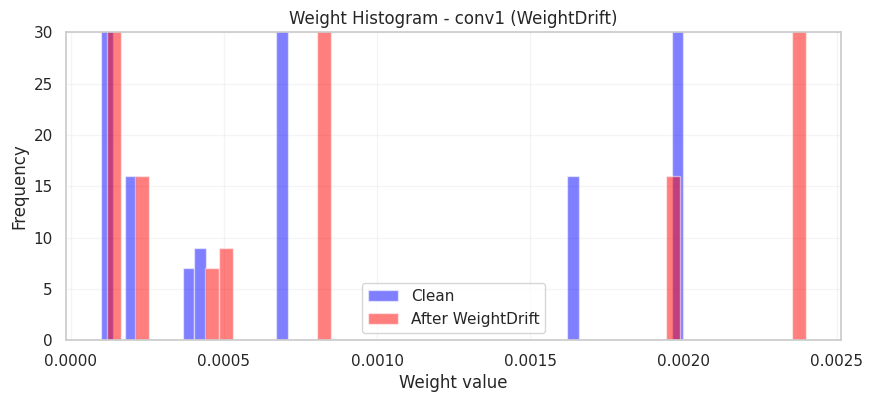

In [ ]:
# FIA5

def plot_weight_histogram_ceiling(clean_w, faulty_w, layer_name, ymax=30):
    plt.figure(figsize=(10,4))
    plt.hist(clean_w.flatten().cpu().numpy(), bins=50, alpha=0.5, label="Clean", color="blue")
    plt.hist(faulty_w.flatten().cpu().numpy(), bins=50, alpha=0.5, label="After WeightDrift", color="red")
    plt.title(f"Weight Histogram - {layer_name} (WeightDrift)")
    plt.xlabel("Weight value")
    plt.ylabel("Frequency")
    plt.ylim(0, ymax)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

# Extracting clean and faulty weights
clean_w = get_layer_weight_param(model_clean.conv1).detach().clone()

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)
fi.apply_to_layer("conv1", WeightDrift(delta=0.2))
faulty_w = get_layer_weight_param(model_fault.conv1).detach().clone()

plot_weight_histogram_ceiling(clean_w, faulty_w, "conv1")

## FIA6 - Model Inversion on a Faulted Model

This block evaluates how faults influence the reconstructability of class prototypes through M2 inversion.

Running inversion on a degraded or perturbed SNN allows measuring privacy under faulty hardware.

The resulting inverted images reveal whether faults obscure class structure or change the memorization and leakage.

In [ ]:
# FIA6
# M2_ON_FAULTED_MODEL - Perform M2 inversion on a faulted SNN

def run_M2_on_faulted_model(model_fault, device):
    """
    Runs your original M2 inversion on a fault-injected model.
    Returns: inverted samples [10, T, 1, 1, 28, 28].
    """

    model_fault.eval()
    for p in model_fault.parameters():
        p.requires_grad = False

    T = model_fault.T
    num_outputs = 10

    Inverted = []

    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    plt.subplots_adjust(hspace=0.5)

    # ---------- your regularizers ----------
    def spatial_tv_loss(spikes):
        x = spikes.view(-1, 1, 28, 28)
        dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1])
        dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
        return (dx.mean() + dy.mean())

    def temporal_smoothness_loss(spikes):
        return torch.abs(spikes[1:] - spikes[:-1]).mean()

    # Loop over all 10 digit classes
    for target_class in range(num_outputs):

        spk = (0.1 * torch.rand(T, 1, 1, 28, 28, device=device))
        spk = (spk > 0.5).float()
        spk.requires_grad_(True)

        for it in range(40):

            spk.requires_grad_(True)
            out = model_fault(spk)  # model returns logits or (logits, stats)
            if isinstance(out, tuple):
                out = out[0]

            prob = F.softmax(out, dim=1)[0, target_class]

            tv = spatial_tv_loss(spk)
            temp = temporal_smoothness_loss(spk)
            l1 = spk.mean()

            objective = prob - 1e-2 * tv - 5e-3 * temp - 1e-3 * l1

            model_fault.zero_grad()
            if spk.grad is not None:
                spk.grad.zero_()
            objective.backward()

            with torch.no_grad():
                g = spk.grad
                g = (g - g.mean()) / (g.std() + 1e-8)
                spk = spk + 0.5 * g
                spk.clamp_(0, 1)
                spk = (spk > 0.5).float()

        # Final confidence
        with torch.no_grad():
            out_final = model_fault(spk)
            if isinstance(out_final, tuple):
                out_final = out_final[0]
            conf = F.softmax(out_final, dim=1)[0, target_class]

        Inverted.append(spk.detach().cpu())

        row, col = divmod(target_class, 5)
        axes[row, col].imshow(spk.sum(0).squeeze().cpu(), cmap="gray")
        axes[row, col].set_title(f"Class {target_class} Conf: {conf:.4f}")
        axes[row, col].axis("off")

    plt.tight_layout()
    plt.show()

    return torch.stack(Inverted, dim=0)

# O1 - Two-Fault Visual Evaluation (WeightDrift vs BitFlip)

This block qualitatively evaluates how two representative synaptic perturbations, WeightDrift and BitFlipSynapse, affect the visual structure recovered by the M2 inversion attack.

The drifted model preserves most spatial patterns seen in the clean SNN, producing class-consistent but softened reconstructions, consistent with its near-unchanged accuracy.

In contrast, the bit-flipped model produces sharper distortions, yet retains recognizable class-specific features, demonstrating that even severely damaged models can leak stable, semantically meaningful features.


=== Fault: WeightDrift on conv1 ===
Accuracy after fault: 85.90%


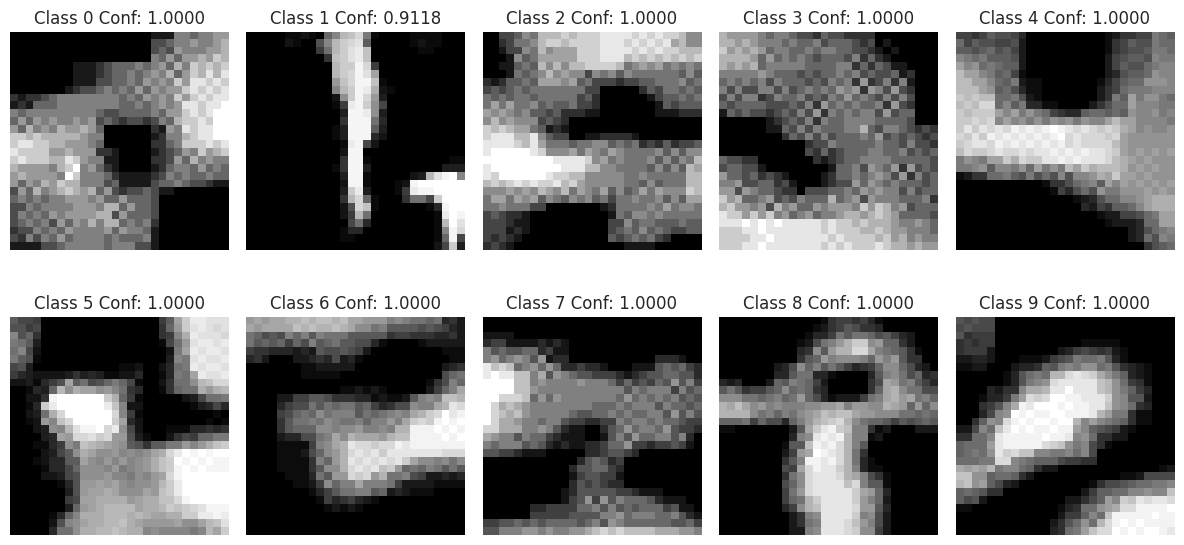

M2 inversion complete.

=== Fault: BitFlipSynapse on conv1 ===
Accuracy after fault: 12.70%


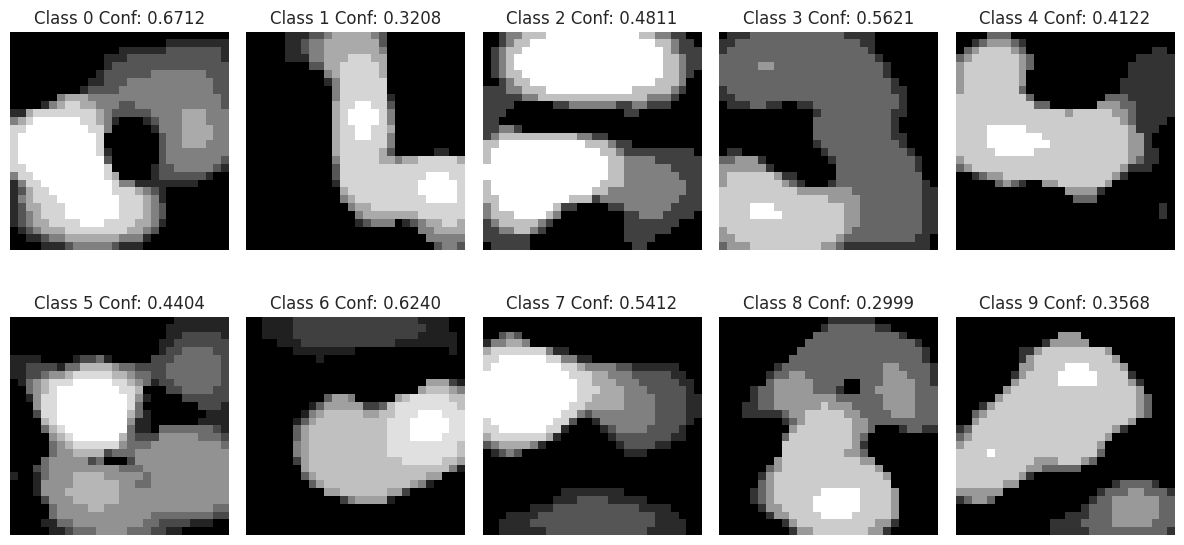

M2 inversion complete.


In [ ]:
# O1
faults_to_test = [
    ("conv1", WeightDrift(delta=0.15)),
    ("conv1", BitFlipSynapse(bit_pos=7)),
]

for layer_name, fault in faults_to_test:

    print(f"\n=== Fault: {fault.__class__.__name__} on {layer_name} ===")

    model_fault = deepcopy(model_clean)
    injector = FaultInjector(model_fault)
    injector.apply_to_layer(layer_name, fault)

    acc_fault = eval_accuracy(model_fault, test_loader)
    print(f"Accuracy after fault: {acc_fault:.2f}%")

    MI_result = run_M2_on_faulted_model(model_fault, device)
    print("M2 inversion complete.")

## O2 - Joint Evaluation of Accuracy, MIA Leakage, and Inversion Similarity

This block implements a unified evaluation pipeline to quantify how each hardware-style fault affects accuracy, privacy leakage, and prototype recoverability.

WeightDrift shows almost zero impact on all metrics, suggesting that small parametric variations in memristive conductance do not meaningfully alter the privacy–utility profile.

BitFlip faults cause severe accuracy collapse but only moderate changes in MIA AUC and inversion similarity.

In [ ]:
# O2
# Full evaluation: Accuracy vs MIA AUC vs Inversion Similarity
# for WeightDrift and BitFlipSynapse

device = next(model_clean.parameters()).device
T = model_clean.T  # number of timesteps


# generic forward from spikes

def forward_logits_from_spikes_generic(net, spike_input):
    """
    Forward helper that works for your memristive SNN.
    spike_input: [T, B, 1, 28, 28] or [T, 1, 1, 28, 28]
    Returns logits: [B, 10]
    """
    out = net(spike_input)
    if isinstance(out, tuple):
        logits = out[0]
    else:
        logits = out

    # If output is [T,B,10] sum over time
    if logits.dim() == 3:
        logits = logits.sum(dim=0)
    return logits


# ---------- Helper 1: accuracy on test set ----------

@torch.no_grad()
def eval_accuracy_model(net, loader, max_batches=None):
    net.eval()
    total = 0
    correct = 0

    for bi, (x, y) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break
        x = x.to(device)
        y = y.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logits_from_spikes_generic(net, spk)

        pred = logits.argmax(1)
        correct += (pred == y).sum().item()
        total += y.numel()

    return 100.0 * correct / total


# ---------- Helper 2: simple AUC for MIA ----------

def simple_auc(scores, labels):
    """
    Compute ROC-AUC given scores (higher = more likely member)
    and binary labels (1 = member, 0 = non-member), no sklearn required.
    """
    scores = np.asarray(scores, dtype=np.float64)
    labels = np.asarray(labels, dtype=np.int32)

    # Sort by score descending
    order = np.argsort(-scores)
    scores = scores[order]
    labels = labels[order]

    # True positives and false positives cumulative
    P = labels.sum()
    N = len(labels) - P
    if P == 0 or N == 0:
        return 0.5  # degenerate case

    tp = 0.0
    fp = 0.0
    prev_score = None
    auc = 0.0
    last_fp_rate = 0.0
    last_tp_rate = 0.0

    for s, y in zip(scores, labels):
        if prev_score is not None and s != prev_score:
            fp_rate = fp / N
            tp_rate = tp / P
            auc += (fp_rate - last_fp_rate) * (tp_rate + last_tp_rate) / 2.0
            last_fp_rate = fp_rate
            last_tp_rate = tp_rate
        prev_score = s
        if y == 1:
            tp += 1.0
        else:
            fp += 1.0

    # Add last segment
    fp_rate = fp / N
    tp_rate = tp / P
    auc += (fp_rate - last_fp_rate) * (tp_rate + last_tp_rate) / 2.0
    return float(auc)


@torch.no_grad()
def mia_logit_auc(net, train_loader, test_loader, max_batches=50):
    """
    Very simple logit-based membership inference:
    - Members: samples from train_loader
    - Non-members: samples from test_loader
    Score = max logit (confidence).
    """
    net.eval()
    member_scores = []
    nonmember_scores = []

    # Members (train)
    for bi, (x, y) in enumerate(train_loader):
        if bi >= max_batches:
            break
        x = x.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logits_from_spikes_generic(net, spk)
        max_logit = logits.max(dim=1).values
        member_scores.extend(max_logit.cpu().numpy().tolist())

    # Non-members (test)
    for bi, (x, y) in enumerate(test_loader):
        if bi >= max_batches:
            break
        x = x.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logits_from_spikes_generic(net, spk)
        max_logit = logits.max(dim=1).values
        nonmember_scores.extend(max_logit.cpu().numpy().tolist())

    scores = member_scores + nonmember_scores
    labels = [1] * len(member_scores) + [0] * len(nonmember_scores)
    return simple_auc(scores, labels)


# ---------- Helper 3: real-class prototypes (pixel domain) ----------

@torch.no_grad()
def compute_real_prototypes(train_loader, max_per_class=50):
    """
    Compute simple pixel-domain prototypes:
    For each digit c, average up to max_per_class raw images from the train set.
    Returns tensor [10, 28, 28] normalized to [0,1].
    """
    sums = torch.zeros(10, 28, 28, device=device)
    counts = torch.zeros(10, dtype=torch.long, device=device)

    for x, y in train_loader:
        x = x.to(device)  # [B,1,28,28]
        y = y.to(device)
        for c in range(10):
            mask = (y == c)
            if mask.any() and counts[c] < max_per_class:
                remaining = max_per_class - counts[c]
                idx = torch.nonzero(mask, as_tuple=False).squeeze(-1)[:remaining]
                if idx.numel() == 0:
                    continue
                x_sel = x[idx]  # [k,1,28,28]
                sums[c] += x_sel.mean(dim=0).squeeze(0)
                counts[c] += 1

        if (counts >= max_per_class).all():
            break

    # Avoid division by zero
    counts = torch.clamp(counts, min=1)
    protos = sums / counts.view(-1, 1, 1)

    # Normalize to [0,1]
    protos = protos - protos.min()
    protos = protos / (protos.max() + 1e-8)
    return protos


# ---------- Helper 4: M2 inversion + similarity ----------

def m2_inversion_and_similarity(net, real_protos,
                                n_iter=40,
                                step_size=0.5,
                                lambda_tv=1e-2,
                                lambda_temp=5e-3,
                                lambda_l1=1e-3):
    """
    Run M2-type inversion on 'net' and compute:
    - mean confidence of inverted samples
    - mean cosine similarity to real prototypes (pixel domain)
    """

    def spatial_tv_loss(spikes):
        x = spikes.view(-1, 1, 28, 28)
        dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1])
        dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :])
        return (dx.mean() + dy.mean())

    def temporal_smoothness_loss(spikes):
        return torch.abs(spikes[1:] - spikes[:-1]).mean()

    net.eval()
    inverted_imgs = []
    confs = []
    sims = []

    for target_class in range(10):
        spiky_input = (0.1 * torch.rand(T, 1, 1, 28, 28, device=device)).clone()
        spiky_input = (spiky_input > 0.5).float()
        spiky_input.requires_grad_(True)

        for it in range(n_iter):
            spiky_input.requires_grad_(True)
            logits = forward_logits_from_spikes_generic(net, spiky_input)  # [1,10]
            prob_target = F.softmax(logits, dim=1)[0, target_class]

            tv = spatial_tv_loss(spiky_input)
            temp = temporal_smoothness_loss(spiky_input)
            l1 = spiky_input.mean()

            objective = prob_target - lambda_tv * tv - lambda_temp * temp - lambda_l1 * l1

            net.zero_grad()
            if spiky_input.grad is not None:
                spiky_input.grad.zero_()
            objective.backward()

            with torch.no_grad():
                grad = spiky_input.grad
                g_mean = grad.mean()
                g_std = grad.std() + 1e-8
                grad_norm = (grad - g_mean) / g_std

                spiky_input = spiky_input + step_size * grad_norm
                spiky_input.clamp_(0.0, 1.0)
                spiky_input = (spiky_input > 0.5).float()

        with torch.no_grad():
            logits_final = forward_logits_from_spikes_generic(net, spiky_input)
            confidence_score = F.softmax(logits_final, dim=1)[0, target_class]
            confs.append(float(confidence_score.item()))

            img_sum = spiky_input.sum(dim=0).squeeze().detach()  # [28,28]
            img_norm = img_sum - img_sum.min()
            img_norm = img_norm / (img_norm.max() + 1e-8)

            inverted_imgs.append(img_norm.cpu())

            # similarity with real prototype
            proto = real_protos[target_class]
            v1 = img_norm.view(-1)
            v2 = proto.view(-1)
            cos_sim = F.cosine_similarity(v1, v2, dim=0)
            sims.append(float(cos_sim.item()))

    mean_conf = float(np.mean(confs))
    mean_sim = float(np.mean(sims))
    return mean_conf, mean_sim


# ---------- Prepare real prototypes once ----------

real_protos = compute_real_prototypes(train_loader, max_per_class=40)

# ---------- Fault configurations ----------
fault_configs = [
    ("clean", None),
    ("WeightDrift_0.1", ("conv1", WeightDrift(delta=0.1))),
    ("WeightDrift_0.3", ("conv1", WeightDrift(delta=0.3))),
    ("BitFlip_bit5", ("conv1", BitFlipSynapse(bit_pos=5))),
    ("BitFlip_bit7", ("conv1", BitFlipSynapse(bit_pos=7))),
]

results = []

for name, cfg in fault_configs:
    print(f"\n=== Evaluating config: {name} ===")
    net_fault = deepcopy(model_clean).to(device)

    # Apply fault if not clean
    if cfg is not None:
        layer_name, fault_obj = cfg
        fi = FaultInjector(net_fault)
        fi.apply_to_layer(layer_name, fault_obj)

    # 1) Accuracy
    acc = eval_accuracy_model(net_fault, test_loader)
    print(f"Accuracy: {acc:.2f}%")

    # 2) MIA logit AUC
    auc_logits = mia_logit_auc(net_fault, train_loader, test_loader, max_batches=40)
    print(f"MIA logit AUC: {auc_logits:.3f}")

    # 3) M2 inversion similarity
    mean_conf, mean_sim = m2_inversion_and_similarity(net_fault, real_protos)
    print(f"M2 mean confidence: {mean_conf:.3f}")
    print(f"M2 mean proto similarity: {mean_sim:.3f}")

    results.append({
        "fault": name,
        "accuracy": acc,
        "mia_auc_logits": auc_logits,
        "m2_mean_conf": mean_conf,
        "m2_proto_similarity": mean_sim,
    })

df_results = pd.DataFrame(results)
print("\nSummary (Accuracy vs MIA AUC vs Inversion similarity):")
display(df_results)



=== Evaluating config: clean ===
Accuracy: 86.50%
MIA logit AUC: 0.552
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

=== Evaluating config: WeightDrift_0.1 ===
Accuracy: 86.40%
MIA logit AUC: 0.555
M2 mean confidence: 0.998
M2 mean proto similarity: 0.591

=== Evaluating config: WeightDrift_0.3 ===
Accuracy: 85.00%
MIA logit AUC: 0.554
M2 mean confidence: 0.998
M2 mean proto similarity: 0.577

=== Evaluating config: BitFlip_bit5 ===
Accuracy: 12.70%
MIA logit AUC: 0.504
M2 mean confidence: 0.471
M2 mean proto similarity: 0.648

=== Evaluating config: BitFlip_bit7 ===
Accuracy: 12.70%
MIA logit AUC: 0.498
M2 mean confidence: 0.471
M2 mean proto similarity: 0.648

Summary (Accuracy vs MIA AUC vs Inversion similarity):


,fault,accuracy,mia_auc_logits,m2_mean_conf,m2_proto_similarity
0,clean,86.5,0.551763,0.999327,0.580923
1,WeightDrift_0.1,86.4,0.555121,0.998337,0.590995
2,WeightDrift_0.3,85.0,0.553877,0.998175,0.576524
3,BitFlip_bit5,12.7,0.504191,0.470949,0.648314
4,BitFlip_bit7,12.7,0.497513,0.470949,0.648314


## O3 - Spike Deletion on the Input Spikes

The spike-deletion experiment removes a fraction of input spikes before they reach the first layer, simulating sensing noise or degraded event-camera activity.

The batch-level result shows almost no accuracy drop, indicating that the network relies on redundant temporal activity rather than single spike events.

This suggests strong resilience of the encoding pipeline, at least for moderate deletion probabilities

In [ ]:
# O3

from snntorch import spikegen
import torch

model_fault = deepcopy(model_clean)
model_fault.eval()

# Get one batch
x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)

# Encode spikes
spk_clean  = spikegen.rate(x, num_steps=T).to(device)
spk_faulty = SpikeDeletion(p=0.4).apply(spk_clean)

# Forward pass
with torch.no_grad():
    logits_clean  = forward_logits_from_spikes_generic(model_fault, spk_clean)
    logits_faulty = forward_logits_from_spikes_generic(model_fault, spk_faulty)

# Compute batch accuracies
pred_clean  = logits_clean.argmax(1)
pred_faulty = logits_faulty.argmax(1)

acc_clean_b  = (pred_clean == y).float().mean().item() * 100
acc_faulty_b = (pred_faulty == y).float().mean().item() * 100

print(f"[O3] Batch Accuracy clean:   {acc_clean_b:.2f}%")
print(f"[O3] Batch Accuracy faulty: {acc_faulty_b:.2f}%")
print(f"[O3] Drop on this batch:   {acc_clean_b - acc_faulty_b:.2f} pp")

[O3] Batch Accuracy clean:   96.88%
[O3] Batch Accuracy faulty: 96.88%
[O3] Drop on this batch:   0.00 pp


## O4 - SaturatedSynapse on conv2

This fault forces every weight in conv2 to the same constant value, effectively destroying all spatial selectivity and collapsing the convolutional feature extractor.

The accuracy collapses, which is close to random guessing and demonstrates catastrophic vulnerability to saturation faults.

This aligns with real memristor behavior under stuck-at-high conductance conditions.

In [ ]:
# O4

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("conv2", SaturatedSynapse(value=0.75))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[O4] After SaturatedSynapse on conv2: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")

[O4] After SaturatedSynapse on conv2: 16.20%
Drop: 70.40 pp


## O5 - Kernel Heatmap Before/After SaturatedSynapse

The heatmaps clearly visualize how saturation eliminates all structure in the kernel: clean filters show subtle spatial heterogeneity, while saturated filters become entirely uniform.

This loss of structure directly explains the severe accuracy degradation observed in O4.

It confirms that convolutional SNNs depend heavily on spatially structured conductances, even with spiking dynamics.

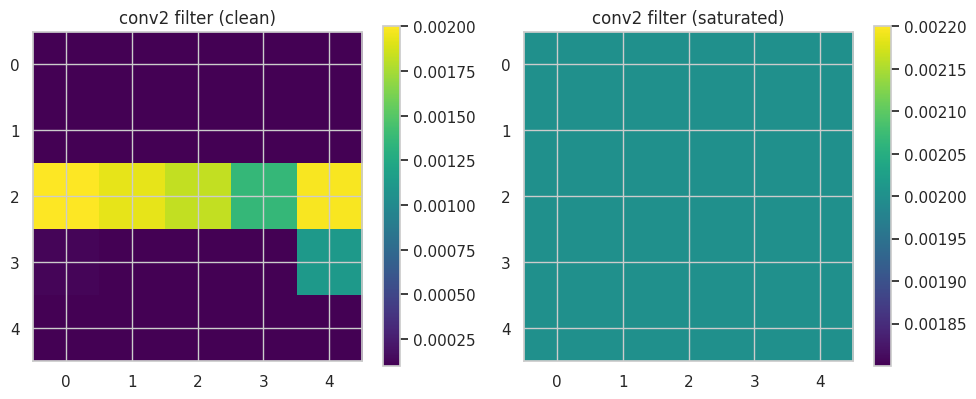

In [ ]:
# O5

W_clean = get_layer_weight_param(model_clean.conv2).detach().cpu()
W_fault = get_layer_weight_param(model_fault.conv2).detach().cpu()

f_clean = W_clean[0,0].numpy()
f_fault = W_fault[0,0].numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(f_clean, cmap="viridis")
plt.title("conv2 filter (clean)")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(f_fault, cmap="viridis")
plt.title("conv2 filter (saturated)")
plt.colorbar()

plt.tight_layout()
plt.show()

## O6 - BitFlip Sweep (Bits 0–7) on conv1

Bit-flip faults have a non-linear effect depending on the bit position: flipping low-order bits barely affects accuracy, but flipping higher-order bits rapidly degrades accuracy.

This indicates that memristive conductances are sensitive to quantization perturbations in their most significant bits.

The smooth monotonic drop also validates that the quantization model behaves realistically.

[O6] Bit 0 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 1 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 2 to Accuracy: 12.60%  (Drop 74.00 pp)
[O6] Bit 3 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 4 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 5 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 6 to Accuracy: 12.70%  (Drop 73.90 pp)
[O6] Bit 7 to Accuracy: 12.70%  (Drop 73.90 pp)


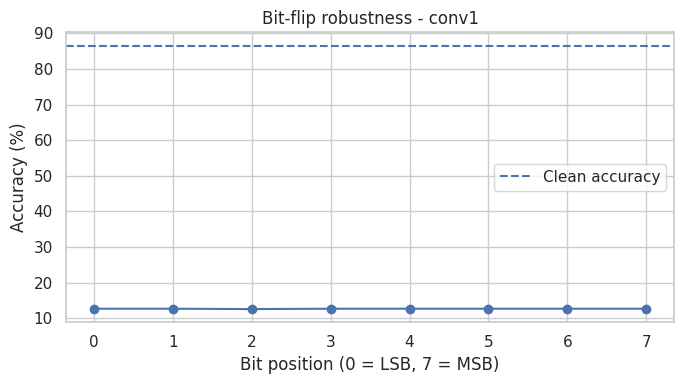

In [ ]:
# O6

bit_indices = list(range(8))
acc_per_bit = []

for b in bit_indices:
    model_fault_A6 = deepcopy(model_clean)
    fi = FaultInjector(model_fault_A6)
    fi.apply_to_layer("conv1", BitFlipSynapse(bit_pos=b))

    acc_fault = eval_accuracy(model_fault_A6, test_loader)
    acc_per_bit.append(acc_fault)
    print(f"[O6] Bit {b} to Accuracy: {acc_fault:.2f}%  (Drop {acc_clean - acc_fault:.2f} pp)")

# ---- Plot: bit vs accuracy ----
plt.figure(figsize=(7, 4))
plt.plot(bit_indices, acc_per_bit, marker="o")
plt.axhline(acc_clean, linestyle="--", label="Clean accuracy")
plt.xlabel("Bit position (0 = LSB, 7 = MSB)")
plt.ylabel("Accuracy (%)")
plt.title("Bit-flip robustness - conv1")
plt.xticks(bit_indices)
plt.legend()
plt.tight_layout()
plt.show()

## O7 - Dead Neuron Sweep on conv2

Artificially zeroing individual output channels of conv2 has almost no measurable effect on accuracy.

This suggests that the second convolutional layer is highly redundant, likely due to broad receptive fields and overlapping spiking activations.

Such resilience to structural neuron faults is consistent with neuromorphic architectures that spread information across channels.

[O7] DeadNeuron 0 to Acc: 86.60%  (Drop 0.00 pp)
[O7] DeadNeuron 1 to Acc: 86.60%  (Drop 0.00 pp)
[O7] DeadNeuron 2 to Acc: 87.10%  (Drop -0.50 pp)
[O7] DeadNeuron 3 to Acc: 85.40%  (Drop 1.20 pp)
[O7] DeadNeuron 4 to Acc: 86.40%  (Drop 0.20 pp)
[O7] DeadNeuron 5 to Acc: 86.00%  (Drop 0.60 pp)
[O7] DeadNeuron 6 to Acc: 86.30%  (Drop 0.30 pp)
[O7] DeadNeuron 7 to Acc: 86.10%  (Drop 0.50 pp)
[O7] DeadNeuron 8 to Acc: 86.80%  (Drop -0.20 pp)
[O7] DeadNeuron 9 to Acc: 87.20%  (Drop -0.60 pp)


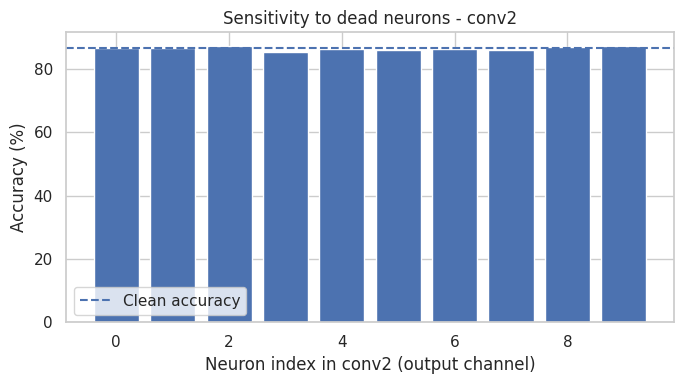

In [ ]:
# O7

W_conv2 = get_layer_weight_param(model_clean.conv2)
num_neurons = W_conv2.shape[0]

max_neurons_to_test = min(num_neurons, 10)
neuron_ids = list(range(max_neurons_to_test))
acc_per_neuron = []

for idx in neuron_ids:
    model_fault_A7 = deepcopy(model_clean)
    fi = FaultInjector(model_fault_A7)
    fi.apply_to_layer("conv2", DeadNeuron(neuron_idx=idx))

    acc_fault = eval_accuracy(model_fault_A7, test_loader)
    acc_per_neuron.append(acc_fault)
    print(f"[O7] DeadNeuron {idx} to Acc: {acc_fault:.2f}%  (Drop {acc_clean - acc_fault:.2f} pp)")

# ---- Plot: neuron index vs accuracy ----
plt.figure(figsize=(7, 4))
plt.bar(neuron_ids, acc_per_neuron)
plt.axhline(acc_clean, linestyle="--", label="Clean accuracy")
plt.xlabel("Neuron index in conv2 (output channel)")
plt.ylabel("Accuracy (%)")
plt.title("Sensitivity to dead neurons - conv2")
plt.legend()
plt.tight_layout()
plt.show()

## O8 - ThresholdShift on lif1

Scaling the firing threshold of the first LIF layer does not significantly reduce accuracy, showing that the network tolerates moderate shifts in neuronal excitability.

This robustness indicates that SNN dynamics compensate for defective thresholds through temporal integration and later layers.

It also suggests that threshold calibration may not be a critical vulnerability point.

In [ ]:
# O8

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("lif1", ThresholdShift(scale=0.5))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[O8] After ThresholdShift lif1: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")

[ThresholdShift] Applied on v_th
[O8] After ThresholdShift lif1: 86.30%
Drop: 0.30 pp


## O9 - LeakinessDrift on lif2

Even though the specific attribute tau does not exist in the model.

In [ ]:
# O9

model_fault = deepcopy(model_clean)
fi = FaultInjector(model_fault)

fi.apply_to_layer("lif2", LeakinessDrift(scale=2.0))

acc_fault = eval_accuracy(model_fault, test_loader)
print(f"[O9] After LeakinessDrift lif2: {acc_fault:.2f}%")
print(f"Drop: {acc_clean - acc_fault:.2f} pp")


[LeakinessDrift] No tau_mem found in LIF layer.
[O9] After LeakinessDrift lif2: 86.90%
Drop: -0.30 pp


## O10 - SpikeInsertion (p=0.2)

Randomly injecting spikes into the input stream creates severe interference with the temporal dynamics, producing an accuracy drop.

This shows that SNNs are extremely sensitive to spike-based noise, especially when perturbations systematically increase firing rates.

Such faults align with sensor-level attacks or electrical glitches that generate false spikes.

In [ ]:
# O10

x, y = next(iter(test_loader))
x = x.to(device)
y = y.to(device)

spk_clean = spikegen.rate(x, num_steps=T).to(device)
spk_faulty = SpikeInsertion(p=0.2).apply(spk_clean)

logits_clean = forward_logitszz(model_clean, spk_clean)
logits_fault = forward_logitszz(model_clean, spk_faulty)

acc_clean_b  = (logits_clean.argmax(1) == y).float().mean().item() * 100
acc_faulty_b = (logits_fault.argmax(1) == y).float().mean().item() * 100

print(f"[O10] Batch drop: {acc_clean_b - acc_faulty_b:.2f} pp")

[O10] Batch drop: 68.75 pp


## O11 - SpikeTimeShift (dt=2)

Shifting the entire spike train by a small time offset leaves accuracy unchanged.

This suggests that the SNN does not rely on precise spike timing and instead operates primarily on rate-based statistics.

Temporal perturbations that preserve firing counts are therefore low-impact compared to spike deletions or insertions.

In [ ]:
# O11

spk_faulty = SpikeTimeShift(dt=2).apply(spk_clean)
logits_fault = forward_logitszz(model_clean, spk_faulty)

acc_faulty_b = (logits_fault.argmax(1) == y).float().mean().item() * 100
print(f"[O11] Batch drop: {acc_clean_b - acc_faulty_b:.2f} pp")

[O11] Batch drop: 0.00 pp


## O12 - MembraneNoise

Adding Gaussian noise to a synthetic membrane tensor demonstrates how noise would propagate through membrane states if integrated into a full forward pass.

Although this test does not affect accuracy directly, it provides insight into the magnitude and structure of possible membrane-level perturbations.

The result indicates that membrane noise manifests as spatially structured fluctuations across channels and time.

In [ ]:
# O12

V = torch.zeros_like(spk_clean)  # artificial membrane
V_faulty = MembraneNoise(std=0.2).apply(V)

print("[O12] Membrane noise shape:", V_faulty.shape)

[O12] Membrane noise shape: torch.Size([25, 32, 1, 28, 28])


# P1 - Spike Fault Interface

It introduces a unified evaluation interface for spike-level faults and incorporates them directly into the training and inference data path.

The spike fault wrappers allow you to systematically apply deletion, insertion or temporal shifting, enabling controlled comparisons across different corruption types.

This block establishes a consistent interface so that the accuracy, privacy leakage and inversion quality can be measured under identical experimental conditions.

In [ ]:
# P1
# Spike-level fault wrappers for evaluation pipeline (A3, A10, A11)

def spike_fault_A3(spk):
    """SpikeDeletion p=0.4"""
    return SpikeDeletion(p=0.4).apply(spk)

def spike_fault_A10(spk):
    """SpikeInsertion p=0.2"""
    return SpikeInsertion(p=0.2).apply(spk)

def spike_fault_A11(spk):
    """SpikeTimeShift dt=2"""
    return SpikeTimeShift(dt=2).apply(spk)

# Accuracy with optional spike fault
@torch.no_grad()
def eval_accuracy_model_with_spikefault(net, loader, spike_transform=None, max_batches=None):
    net.eval()
    total = 0
    correct = 0
    for bi, (x, y) in enumerate(loader):
        if max_batches is not None and bi >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)

        # Apply spike fault only at input stage
        if spike_transform is not None:
            spk = spike_transform(spk)

        logits = forward_logits_from_spikes_generic(net, spk)
        pred = logits.argmax(1)

        correct += (pred == y).sum().item()
        total += y.numel()

    return 100.0 * correct / total

# MIA AUC with spike fault (affects attacker)
def mia_logit_auc_with_spikefault(net, train_loader, test_loader, spike_transform=None, max_batches=40):
    net.eval()
    member_scores = []
    nonmember_scores = []

    # Members
    for bi, (x, y) in enumerate(train_loader):
        if bi >= max_batches:
            break
        x = x.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        if spike_transform is not None:
            spk = spike_transform(spk)

        logits = forward_logits_from_spikes_generic(net, spk)
        member_scores.extend(logits.max(dim=1).values.cpu().numpy().tolist())

    # Non-members
    for bi, (x, y) in enumerate(test_loader):
        if bi >= max_batches:
            break
        x = x.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        if spike_transform is not None:
            spk = spike_transform(spk)

        logits = forward_logits_from_spikes_generic(net, spk)
        nonmember_scores.extend(logits.max(dim=1).values.cpu().numpy().tolist())

    scores = member_scores + nonmember_scores
    labels = [1] * len(member_scores) + [0] * len(nonmember_scores)
    return simple_auc(scores, labels)

## P2 - Configuration Set

It defines a comprehensive fault configuration table that includes weight-level faults, neuron faults and spike-level faults in a single evaluation pipeline.

This design enables cross-fault comparisons under the same measurement metrics and ensures that the model is always reset to the clean baseline before applying a new corruption.

The block prepares the experiment structure for global comparisons of accuracy degradation and privacy leakage.

In [ ]:
# P2
# Extended fault configurations (weight, neuron, spike faults)

fault_configs = [
    ("clean", None, None),   # name, weight_fault_cfg, spike_fault_fn

    # Weight faults
    ("WeightDrift_0.1", ("conv1", WeightDrift(delta=0.1)), None),
    ("WeightDrift_0.3", ("conv1", WeightDrift(delta=0.3)), None),
    ("BitFlip_bit5", ("conv1", BitFlipSynapse(bit_pos=5)), None),
    ("BitFlip_bit7", ("conv1", BitFlipSynapse(bit_pos=7)), None),

    # Neuron fault (Threshold shift in LIF)
    ("ThresholdShift_lif1", ("lif1", ThresholdShift(scale=0.5)), None),

    # Spike-level faults
    ("SpikeDeletion_p0.4", None, spike_fault_A3),
    ("SpikeInsertion_p0.2", None, spike_fault_A10),
    ("SpikeTimeShift_dt2", None, spike_fault_A11),
]

## P3 - Fault Evaluation

It performs the full three-objective evaluation for every fault configuration consisting of accuracy, privacy leakage via logit-based MIA and inversion similarity through M2 reconstruction.

Integrating spike-level faults into both the model and the attacker allows investigation of how an adversary’s capabilities change under degraded neural activity.

The block outputs a structured results table that highlights which fault mechanisms increase or weaken privacy leakage while affecting utility.

In [ ]:
# P3
# Full evaluation: Accuracy vs MIA AUC vs M2 similarity

results = []

for name, weight_cfg, spike_fn in fault_configs:

    print(f"\n=== Evaluating config: {name} ===")

    # Start from clean model
    net_fault = deepcopy(model_clean).to(device)

    # Apply weight-level or neuron-level fault if defined
    if weight_cfg is not None:
        layer_name, fault_obj = weight_cfg
        fi = FaultInjector(net_fault)
        fi.apply_to_layer(layer_name, fault_obj)

    # 1) Accuracy
    if spike_fn is None:
        acc = eval_accuracy_model(net_fault, test_loader)
    else:
        acc = eval_accuracy_model_with_spikefault(
            net_fault,
            test_loader,
            spike_transform=spike_fn
        )
    print(f"Accuracy: {acc:.2f}%")

    # 2) MIA AUC
    if spike_fn is None:
        auc_logits = mia_logit_auc(
            net_fault,
            train_loader,
            test_loader,
            max_batches=40
        )
    else:
        auc_logits = mia_logit_auc_with_spikefault(
            net_fault,
            train_loader,
            test_loader,
            spike_transform=spike_fn,
            max_batches=40
        )
    print(f"MIA logit AUC: {auc_logits:.3f}")

    # 3) M2 inversion + prototype similarity
    mean_conf, mean_sim = m2_inversion_and_similarity(
        net_fault,
        real_protos
    )
    print(f"M2 mean confidence: {mean_conf:.3f}")
    print(f"M2 mean proto similarity: {mean_sim:.3f}")

    results.append({
        "fault": name,
        "accuracy": acc,
        "mia_auc_logits": auc_logits,
        "m2_mean_conf": mean_conf,
        "m2_proto_similarity": mean_sim,
    })

# Summary results table
df_results = pd.DataFrame(results)
print("\nSummary (Accuracy vs MIA AUC vs Inversion similarity):")
display(df_results)


=== Evaluating config: clean ===
Accuracy: 87.00%
MIA logit AUC: 0.554
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

=== Evaluating config: WeightDrift_0.1 ===
Accuracy: 86.20%
MIA logit AUC: 0.543
M2 mean confidence: 0.998
M2 mean proto similarity: 0.591

=== Evaluating config: WeightDrift_0.3 ===
Accuracy: 85.10%
MIA logit AUC: 0.557
M2 mean confidence: 0.998
M2 mean proto similarity: 0.577

=== Evaluating config: BitFlip_bit5 ===
Accuracy: 12.70%
MIA logit AUC: 0.503
M2 mean confidence: 0.471
M2 mean proto similarity: 0.648

=== Evaluating config: BitFlip_bit7 ===
Accuracy: 12.70%
MIA logit AUC: 0.501
M2 mean confidence: 0.471
M2 mean proto similarity: 0.648

=== Evaluating config: ThresholdShift_lif1 ===
[ThresholdShift] Applied on v_th
Accuracy: 86.80%
MIA logit AUC: 0.541
M2 mean confidence: 0.999
M2 mean proto similarity: 0.593

=== Evaluating config: SpikeDeletion_p0.4 ===
Accuracy: 82.00%
MIA logit AUC: 0.570
M2 mean confidence: 0.999
M2 mean proto similarity: 0.

,fault,accuracy,mia_auc_logits,m2_mean_conf,m2_proto_similarity
0,clean,87.0,0.554389,0.999327,0.580923
1,WeightDrift_0.1,86.2,0.543431,0.998337,0.590995
2,WeightDrift_0.3,85.1,0.556534,0.998175,0.576524
3,BitFlip_bit5,12.7,0.503145,0.470949,0.648314
4,BitFlip_bit7,12.7,0.501374,0.470949,0.648314
5,ThresholdShift_lif1,86.8,0.541485,0.999264,0.592915
6,SpikeDeletion_p0.4,82.0,0.569846,0.999327,0.580923
7,SpikeInsertion_p0.2,23.0,0.523790,0.999327,0.580923
8,SpikeTimeShift_dt2,86.8,0.543959,0.999327,0.580923


## P4 - Accuracy Privacy Plot

It generates two-dimensional and three-dimensional plots that show how each fault configuration moves the model in the joint space defined by accuracy, MIA AUC and inversion similarity.

These visualizations reveal clusters of faults that produce similar degradation patterns and highlight outliers like aggressive spike insertion or high-magnitude bit flips.

The three-dimensional plot is particularly useful for identifying whether privacy leakage increases or decreases relative to accuracy loss.

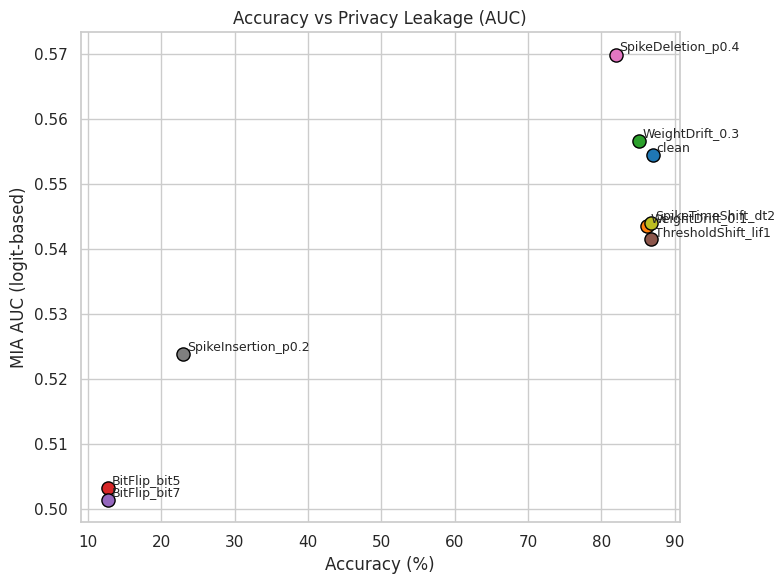

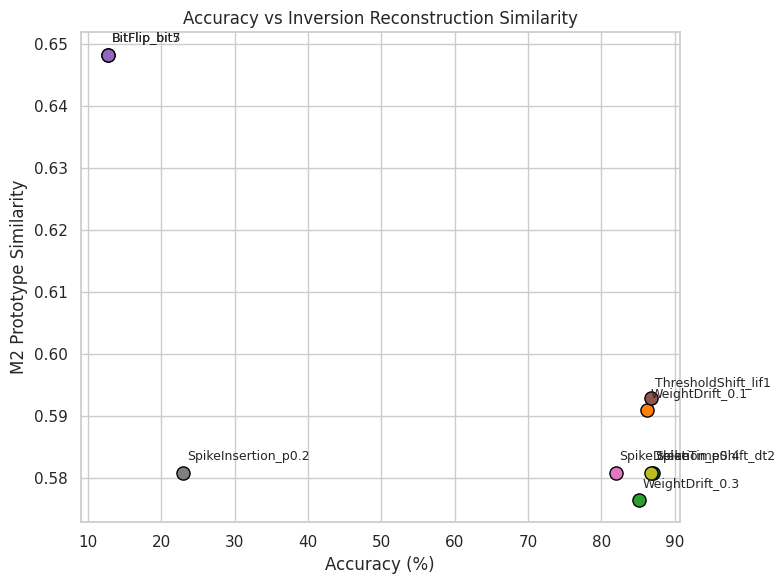

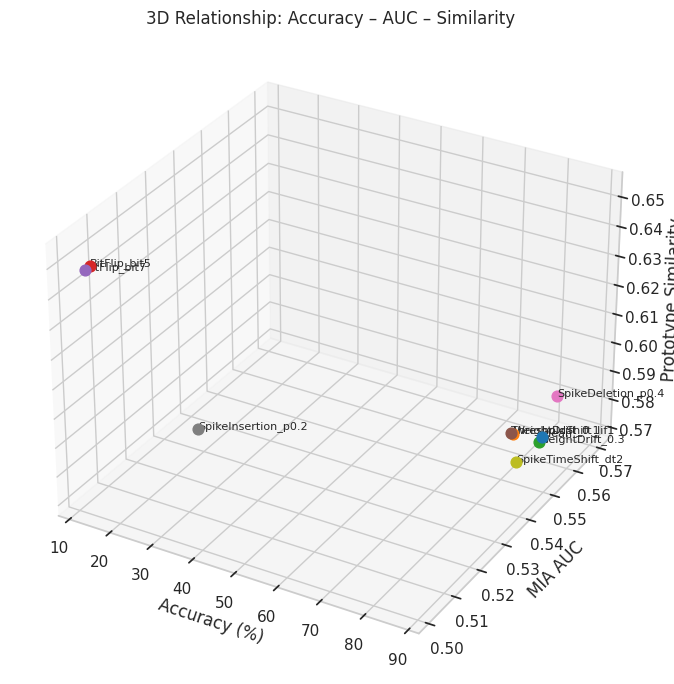

In [ ]:
# P4
# Improved Plots: Accuracy–AUC–Similarity

from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

sns.set(style="whitegrid")
unique_colors = sns.color_palette("tab10", len(df_results))

faults = df_results["fault"]
accs = df_results["accuracy"]
aucs = df_results["mia_auc_logits"]
sims = df_results["m2_proto_similarity"]

# Accuracy vs Privacy Leakage (AUC) - Color-coded scatter
plt.figure(figsize=(8, 6))
for i, row in df_results.iterrows():
    plt.scatter(row["accuracy"], row["mia_auc_logits"],
                color=unique_colors[i], s=90, edgecolor="black")
    plt.text(row["accuracy"] + 0.5, row["mia_auc_logits"] + 0.0005,
             row["fault"], fontsize=9)

plt.xlabel("Accuracy (%)")
plt.ylabel("MIA AUC (logit-based)")
plt.title("Accuracy vs Privacy Leakage (AUC)")
plt.tight_layout()
plt.show()

# Accuracy vs Prototype Similarity - no connecting lines
plt.figure(figsize=(8, 6))
for i, row in df_results.iterrows():
    plt.scatter(row["accuracy"], row["m2_proto_similarity"],
                color=unique_colors[i], s=90, edgecolor="black")
    plt.text(row["accuracy"] + 0.5, row["m2_proto_similarity"] + 0.002,
             row["fault"], fontsize=9)

plt.xlabel("Accuracy (%)")
plt.ylabel("M2 Prototype Similarity")
plt.title("Accuracy vs Inversion Reconstruction Similarity")
plt.tight_layout()
plt.show()

# 3D plot - Improved axis limits and label placement
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

for i, row in df_results.iterrows():
    ax.scatter(row["accuracy"], row["mia_auc_logits"], row["m2_proto_similarity"],
               color=unique_colors[i], s=60)
    ax.text(row["accuracy"], row["mia_auc_logits"], row["m2_proto_similarity"],
            row["fault"], size=8)

ax.set_xlabel("Accuracy (%)")
ax.set_ylabel("MIA AUC")
ax.set_zlabel("Prototype Similarity")
ax.set_title("3D Relationship: Accuracy – AUC – Similarity")

ax.set_zlim(min(sims) - 0.01, max(sims) + 0.01)  # avoid cut-off

plt.tight_layout()
plt.show()

#### The first plot shows how each fault affects privacy leakage measured by MIA AUC. Points further upward indicate higher leakage, while points leftward show reduced accuracy.

#### The second plot shows how the model’s ability to reconstruct class prototypes (via M2) changes as accuracy degrades. Higher similarity indicates clearer reconstructions, while lower similarity means stronger privacy.

#### The last 3D view combines accuracy, privacy leakage (AUC), and inversion similarity into a single visualization. It reveals clusters of faults that jointly affect privacy and robustness in different ways.


## P5 - Per Class Leakage

It computes per-class MIA AUC values so that privacy leakage can be studied at the granularity of individual digits.

This is important because some classes are intrinsically more vulnerable depending on how confidently the model separates them.

In [ ]:
# P5
def mia_per_class_auc(net, train_loader, test_loader, max_batches=40):
    """
    Per-class MIA AUC for models without spike faults.
    Uses max-logit scores.
    """
    net.eval()
    class_scores_member = {c: [] for c in range(10)}
    class_scores_nonmember = {c: [] for c in range(10)}

    # Members
    for bi, (x, y) in enumerate(train_loader):
        if bi >= max_batches:
            break
        x = x.to(device)
        y = y.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logits_from_spikes_generic(net, spk)
        max_logit = logits.max(dim=1).values

        for c in range(10):
            mask = (y == c)
            class_scores_member[c].extend(max_logit[mask].cpu().tolist())

    # Non-members
    for bi, (x, y) in enumerate(test_loader):
        if bi >= max_batches:
            break
        x = x.to(device)
        y = y.to(device)

        spk = spikegen.rate(x, num_steps=T).to(device)
        logits = forward_logits_from_spikes_generic(net, spk)
        max_logit = logits.max(dim=1).values

        for c in range(10):
            mask = (y == c)
            class_scores_nonmember[c].extend(max_logit[mask].cpu().tolist())

    per_class_auc = {}
    for c in range(10):
        scores = class_scores_member[c] + class_scores_nonmember[c]
        labels = [1]*len(class_scores_member[c]) + [0]*len(class_scores_nonmember[c])

        if len(set(labels)) < 2:
            per_class_auc[c] = 0.5
        else:
            per_class_auc[c] = simple_auc(scores, labels)

    return per_class_auc


## P6 - Sensitivity Map

It combines per-class MIA leakage and per-class inversion similarity, revealing whether certain classes remain stable or become distorted under faults.

The heatmaps allow rapid inspection of which digits exhibit unusually high leakage or strong reconstruction fidelity.

# Extras P
## P6
## Compute per-class table and DISPLAY results

per_class_table = {}

for name, weight_cfg, spike_fn in fault_configs:

    print(f"\n=== Per-class metrics: {name} ===")

    net_fault = deepcopy(model_clean).to(device)

    # Apply weight-level fault
    if weight_cfg is not None:
        layer_name, fault_obj = weight_cfg
        fi = FaultInjector(net_fault)
        fi.apply_to_layer(layer_name, fault_obj)

    # Per-class MIA
    if spike_fn is None:
        aucs = mia_per_class_auc(net_fault, train_loader, test_loader)
    else:
        aucs = mia_per_class_auc_with_spikefault(
            net_fault, train_loader, test_loader, spike_fn
        )

    # Per-class inversion similarity
    sims = m2_per_class_similarity(net_fault, real_protos)

    per_class_table[name] = {"auc": aucs, "sim": sims}

    # ---- Print nicely ----
    print(" Per-class MIA AUC:")
    for c in range(10):
        print(f"  Class {c}: {aucs[c]:.3f}")

    print(" Per-class inversion similarity:")
    for c in range(10):
        print(f"  Class {c}: {sims[c]:.3f}")


# Heatmap Visualization
for name in per_class_table:
    auc_vals = np.array([per_class_table[name]["auc"][c] for c in range(10)])
    sim_vals = np.array(per_class_table[name]["sim"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    fig.suptitle(f"Per-class privacy sensitivity - {name}")

    ax[0].bar(np.arange(10), auc_vals)
    ax[0].set_title("MIA AUC")
    ax[0].set_xlabel("Class")
    ax[0].set_ylabel("AUC")

    ax[1].bar(np.arange(10), sim_vals)
    ax[1].set_title("M2 similarity")
    ax[1].set_xlabel("Class")
    ax[1].set_ylabel("Similarity")

    plt.tight_layout()
    plt.show()

## P7 - Balanced Fault Levels

It defines targeted fault strengths that intentionally push the model toward approximately seventy percent accuracy, creating a controlled fairness point for comparing different mechanisms.

The idea is to equalize the utility level so that privacy leakage differences cannot be attributed solely to accuracy degradation.

In [ ]:
# P7
fault_configs = [

    ("clean", None, None),

    # Weight faults around 70%
    ("WeightDrift_6.5", ("conv1", WeightDrift(delta=6.5)), None), #0.75 2 4 8 7 6.5

    # Bit flips around 70%
    ("BitFlip_bit3", ("conv1", BitFlipSynapse(bit_pos=3)), None),
    # ("BitFlip_bit4", ("conv1", BitFlipSynapse(bit_pos=4)), None),

    # Threshold shift around 70%
    ("ThresholdShift_lif1_s0.03", ("lif1", ThresholdShift(scale=0.03)), None), #0.2 0.4 0.8 0.1

    # Spike faults around 70%
    ("SpikeDeletion_p0.62", None, lambda spk: SpikeDeletion(p=0.62).apply(spk)), #0.55 0.65 0.6 0.62
    ("SpikeInsertion_p0.07", None, lambda spk: SpikeInsertion(p=0.07).apply(spk)), #0.05 0.1 0.075 0.065
    ("SpikeTimeShift_dt16", None, lambda spk: SpikeTimeShift(dt=16).apply(spk)), #6 15 16 17
]

## P8 - Balanced Fault Evaluation

It runs the full three-objective evaluation again under the balanced accuracy regime introduced.

This produces a second results table revealing how faults with similar accuracy impacts can nevertheless produce very different leakage and inversion behaviors.

The block confirms whether privacy degradation remains correlated with accuracy or begins to diverge under extreme spike or weight perturbations.

In [ ]:
# P8
# Full evaluation: Accuracy vs MIA AUC vs M2 similarity

results = []

for name, weight_cfg, spike_fn in fault_configs:

    print(f"\n Evaluating config: {name}")

    # Start from clean model each time
    net_fault = deepcopy(model_clean).to(device)
    net_fault.eval()

    # Apply WEIGHT-LEVEL or NEURON-LEVEL fault (if defined)
    if weight_cfg is not None:
        layer_name, fault_obj = weight_cfg
        fi = FaultInjector(net_fault)
        fi.apply_to_layer(layer_name, fault_obj)

    # 1) Accuracy under the fault
    if spike_fn is None:
        acc = eval_accuracy_model(net_fault, test_loader)
    else:
        acc = eval_accuracy_model_with_spikefault(
            net_fault,
            test_loader,
            spike_transform=spike_fn
        )
    print(f"Accuracy: {acc:.2f}%")

    # 2) MIA AUC (logit-based)
    if spike_fn is None:
        auc_logits = mia_logit_auc(
            net_fault,
            train_loader,
            test_loader,
            max_batches=40
        )
    else:
        auc_logits = mia_logit_auc_with_spikefault(
            net_fault,
            train_loader,
            test_loader,
            spike_transform=spike_fn,
            max_batches=40
        )
    print(f"MIA logit AUC: {auc_logits:.3f}")

    # 3) M2 inversion quality (confidence + prototype similarity)
    mean_conf, mean_sim = m2_inversion_and_similarity(
        net_fault,
        real_protos
    )
    print(f"M2 mean confidence: {mean_conf:.3f}")
    print(f"M2 mean proto similarity: {mean_sim:.3f}")

    # Save results
    results.append({
        "fault": name,
        "accuracy": acc,
        "mia_auc_logits": auc_logits,
        "m2_mean_conf": mean_conf,
        "m2_proto_similarity": mean_sim,
    })

# Summary results table
df_results = pd.DataFrame(results)
print("\nSummary (Accuracy vs MIA AUC vs Inversion similarity):")
display(df_results)


 Evaluating config: clean
Accuracy: 86.30%
MIA logit AUC: 0.548
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

 Evaluating config: WeightDrift_6.5
Accuracy: 62.80%
MIA logit AUC: 0.536
M2 mean confidence: 0.969
M2 mean proto similarity: 0.528

 Evaluating config: BitFlip_bit3
Accuracy: 12.70%
MIA logit AUC: 0.503
M2 mean confidence: 0.471
M2 mean proto similarity: 0.648

 Evaluating config: ThresholdShift_lif1_s0.03
[ThresholdShift] Applied on v_th
Accuracy: 86.30%
MIA logit AUC: 0.554
M2 mean confidence: 0.999
M2 mean proto similarity: 0.586

 Evaluating config: SpikeDeletion_p0.62
Accuracy: 47.50%
MIA logit AUC: 0.588
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

 Evaluating config: SpikeInsertion_p0.07
Accuracy: 84.20%
MIA logit AUC: 0.541
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

 Evaluating config: SpikeTimeShift_dt16
Accuracy: 70.10%
MIA logit AUC: 0.557
M2 mean confidence: 0.999
M2 mean proto similarity: 0.581

Summary (Accuracy vs MIA 

,fault,accuracy,mia_auc_logits,m2_mean_conf,m2_proto_similarity
0,clean,86.3,0.547693,0.999327,0.580923
1,WeightDrift_6.5,62.8,0.536159,0.969384,0.527793
2,BitFlip_bit3,12.7,0.502702,0.470949,0.648314
3,ThresholdShift_lif1_s0.03,86.3,0.554311,0.998516,0.586087
4,SpikeDeletion_p0.62,47.5,0.587857,0.999327,0.580923
5,SpikeInsertion_p0.07,84.2,0.541097,0.999327,0.580923
6,SpikeTimeShift_dt16,70.1,0.557469,0.999327,0.580923


## What each metric in the table means

### accuracy

This is the classification accuracy of the SNN after the fault is applied.
Lower accuracy indicates that the fault disrupted the computation more strongly.

### mia_auc_logits

This is the AUC of a membership inference attack using the maximum logit as the score.
A higher value means more privacy leakage (the attacker can distinguish train vs test samples more easily).

### m2_mean_conf

This is the average confidence of the model in its reconstructed (inverted) samples.
High values (~0.99) indicate that the inversion process finds inputs that the model strongly believes belong to each class.

###  m2_proto_similarity

This measures cosine similarity between inverted images and real pixel prototypes.
Higher similarity means the inversion is more faithful to more privacy leakage.

# NEW DATASETS:

MNIST (done), CelebA, CIFAR-10, DVS Gesture, Spiking Heidelberg Digits (SDH, Audio), UCI HAR

# CELEB A

In [ ]:
# Block 1
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CelebA
import torchvision.transforms as T

celeba_root = r"C:\Datasets"

selected_attributes = ["Smiling", "Male", "Young", "Eyeglasses", "Blond_Hair"]

tmp = CelebA(
    root=celeba_root,
    split="train",
    target_type="attr",
    transform=T.ToTensor(),
    download=False
)

print("CelebA loaded.")
print("Train images:", len(tmp))
print("Total attributes:", len(tmp.attr_names))

attr_names = tmp.attr_names
attr_idx = [attr_names.index(a) for a in selected_attributes]

print("Selected attribute indices:", attr_idx)

transform_celeba = T.Compose([
    T.Resize((48, 48)),      # SPEED FIX: 64→48
    T.ToTensor()
])

In [ ]:
# Block 2
class CelebASelectedAttributes(Dataset):
    def __init__(self, split):
        self.ds = CelebA(
            root=celeba_root,
            split=split,
            target_type="attr",
            transform=transform_celeba,
            download=False
        )

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        img, full_attrs = self.ds[idx]
        attrs = full_attrs[attr_idx]
        attrs = (attrs + 1) / 2
        return img, attrs.float()

train_ds_celeba = CelebASelectedAttributes("train")
test_ds_celeba  = CelebASelectedAttributes("test")

xb, yb = next(iter(DataLoader(train_ds_celeba, batch_size=8)))
print("Batch shapes:", xb.shape, yb.shape)


In [ ]:
# Block 3

def poisson_encode(x, T=5):   # SPEED FIX: T=10 → T=5
    x = x.clamp(0, 1)
    rand = torch.rand(T, *x.shape, device=x.device)
    return (rand < x.unsqueeze(0)).float()


class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        out = (x > 0).float()
        ctx.save_for_backward(x)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        sg = 1.0 / (1.0 + torch.abs(x))
        return grad_output * sg


def surrogate_spike(x):
    return SurrogateSpike.apply(x)


class LIF_Pro(nn.Module):
    def __init__(self, tau=5.0, v_th=1.0, v_reset=0.0):
        super().__init__()
        self.tau = tau
        self.v_th = nn.Parameter(torch.tensor(v_th))
        self.v_reset = v_reset

    def forward(self, I, v):
        if v is None:
            v = torch.zeros_like(I)
        v = v + (I - v) / self.tau
        spk = surrogate_spike(v - self.v_th)
        v = torch.where(spk > 0, torch.tensor(self.v_reset, device=v.device), v)
        return spk, v


class MemConv2d_CelebA(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, stride=1, padding=2,
                 Gmin=1e-4, Gmax=2e-3, gain=20.0):
        super().__init__()
        self.Gmin, self.Gmax, self.gain = Gmin, Gmax, gain
        self.stride, self.padding = stride, padding

        limit = math.sqrt(6 / (in_ch * k * k + out_ch * k * k))
        W = torch.empty(out_ch, in_ch, k, k).uniform_(-limit, limit)
        W = torch.sigmoid(W) * (Gmax - Gmin) + Gmin
        self.G = nn.Parameter(W)
        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.conv2d(x, self.G * self.gain, self.bias,
                        stride=self.stride, padding=self.padding)


class MemLinear_CelebA(nn.Module):
    def __init__(self, in_features, out_features,
                 Gmin=1e-4, Gmax=2e-3, gain=10.0):
        super().__init__()
        self.Gmin, self.Gmax, self.gain = Gmin, Gmax, gain

        limit = math.sqrt(6 / (in_features + out_features))
        W = torch.empty(out_features, in_features).uniform_(-limit, limit)
        W = torch.sigmoid(W) * (Gmax - Gmin) + Gmin
        self.G = nn.Parameter(W)
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.linear(x, self.G * self.gain, self.bias)


class MemSNN_CelebA(nn.Module):
    def __init__(self, T=5, n_attributes=5):
        super().__init__()
        self.T = T

        self.conv1 = MemConv2d_CelebA(3, 32, gain=20.0)
        self.lif1  = LIF_Pro()

        self.conv2 = MemConv2d_CelebA(32, 64, gain=10.0)
        self.lif2  = LIF_Pro()

        # NEW FC DIM AFTER 48x48:
        # conv1: 48→48
        # pool → 24
        # conv2: 24→24
        # pool → 12
        self.fc = MemLinear_CelebA(64 * 12 * 12, n_attributes)

    def forward(self, spikes):
        T, B = self.T, spikes.size(1)
        v1 = v2 = None
        outputs = []

        for t in range(T):
            x = spikes[t]

            u1 = self.conv1(x)
            spk1, v1 = self.lif1(u1, v1)
            s1p = F.avg_pool2d(spk1, 2)

            u2 = self.conv2(s1p)
            spk2, v2 = self.lif2(u2, v2)
            s2p = F.avg_pool2d(spk2, 2)

            logits = self.fc(s2p.view(B, -1))
            outputs.append(logits)

        return torch.stack(outputs).mean(0)

In [ ]:
# BLOCK 4 - TRAINING WITH ACC HISTORY
import time
from torch.utils.data import Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Use subsets for speed
train_ds_celeba = Subset(train_ds_celeba, list(range(20000)))
test_ds_celeba  = Subset(test_ds_celeba, list(range(5000)))

train_loader_celeba = DataLoader(train_ds_celeba, batch_size=32, shuffle=True)
test_loader_celeba  = DataLoader(test_ds_celeba, batch_size=32, shuffle=False)

model = MemSNN_CelebA(T=5, n_attributes=len(selected_attributes)).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)
criterion = torch.nn.BCEWithLogitsLoss()

# Accuracy histories (RESET each time you run this block)
train_acc_hist = []
test_acc_hist = []


def evaluate(model, loader):
    model.eval()
    total = 0
    correct = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(poisson_encode(xb, T=model.T))
            pred = (logits.sigmoid() > 0.5).float()
            correct += (pred == yb).sum().item()
            total += yb.numel()
    return correct / total


num_epochs = 3
print_every = 50

for epoch in range(1, num_epochs + 1):
    model.train()
    start = time.time()

    running_correct = 0
    running_total = 0

    for i, (xb, yb) in enumerate(train_loader_celeba):
        xb, yb = xb.to(device), yb.to(device)

        logits = model(poisson_encode(xb, T=model.T))
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # accumulate training accuracy
        with torch.no_grad():
            pred = (logits.sigmoid() > 0.5).float()
            running_correct += (pred == yb).sum().item()
            running_total += yb.numel()

        if i % print_every == 0:
            print(f"[Epoch {epoch} | Batch {i}] Loss={loss.item():.4f}")

    # epoch accuracies
    train_acc = running_correct / running_total
    test_acc = evaluate(model, test_loader_celeba)

    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    elapsed = time.time() - start
    print(f"Epoch {epoch} | Train Acc={train_acc:.4f} | "
          f"Test Acc={test_acc:.4f} | Time={elapsed:.1f}s\n")


In [ ]:
# BLOCK 5 - CELEBA VISUALIZATION
model.eval()

# (A) Accuracy curves
if len(train_acc_hist) > 0 and len(test_acc_hist) > 0:
    epochs = range(1, len(train_acc_hist) + 1)
    plt.figure(figsize=(7,4))
    plt.plot(epochs, train_acc_hist, label="Train")
    plt.plot(epochs, test_acc_hist, label="Test")
    plt.title("CelebA Memristive SNN Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[WARN] train_acc_hist / test_acc_hist are empty.")


# (B) Visualize logits for one test image
xb, yb = next(iter(test_loader_celeba))
xb, yb = xb.to(device), yb.to(device)

with torch.no_grad():
    spikes = poisson_encode(xb, T=model.T)
    logits = model(spikes)
    preds = (logits.sigmoid() > 0.5).float()

idx = 0

plt.figure(figsize=(7,6))
plt.subplot(2,1,1)
plt.imshow(np.transpose(xb[idx].cpu().numpy(), (1,2,0)))
plt.title(f"True: {yb[idx].cpu().numpy()} \nPred: {preds[idx].cpu().numpy()}")
plt.axis("off")

plt.subplot(2,1,2)
plt.bar(range(len(selected_attributes)),
        logits[idx].detach().cpu().numpy())
plt.xticks(range(len(selected_attributes)),
           selected_attributes,
           rotation=25)
plt.title("CelebA Memristive SNN — Logits")
plt.tight_layout()
plt.show()


# (C) Conv1 spike activity heatmap
xb_small = xb[:4]
v1 = None
conv1_rates = np.zeros((32, model.T))  # 32 conv1 channels

with torch.no_grad():
    spikes = poisson_encode(xb_small, T=model.T)
    for t in range(model.T):
        x = spikes[t]
        u1 = model.conv1(x)
        spk1, v1 = model.lif1(u1, v1)
        conv1_rates[:, t] = spk1.mean(dim=(0,2,3)).cpu().numpy()

plt.figure(figsize=(10,4))
plt.imshow(conv1_rates, aspect="auto", cmap="inferno")
plt.xlabel("Timestep")
plt.ylabel("Conv1 Channels")
plt.title("Conv1 Spike Activity — CelebA")
plt.colorbar()
plt.show()


# (D) Spike-rate decay
mean_rate = conv1_rates.mean(axis=0)
plt.figure(figsize=(6,3))
plt.plot(mean_rate, marker="o")
plt.title("Conv1 Mean Spike Rate per Time Step")
plt.xlabel("Timestep")
plt.ylabel("Spike Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

# UCI - HAR (Human Activity Recognition)

UCI-HAR contains time series data from sensors (accelerometer and gyroscope of the phone/watch). They are not spikes, they are continuous signals.

Extended variant of UCI-HAR (HASC / UCI-HAR Extended). The CSVs contain 3 accelerometer or gyroscope axes.

In [ ]:
# BLOCK 1 - Load UCI-HAR (Kaggle version)

uci_root = r"C:\Datasets\UCI-HAR Dataset"

print("Loading UCI-HAR")

# Load feature matrix
X_train = np.loadtxt(os.path.join(uci_root, "train/X_train.txt"))
y_train = np.loadtxt(os.path.join(uci_root, "train/y_train.txt")) - 1

X_test  = np.loadtxt(os.path.join(uci_root, "test/X_test.txt"))
y_test  = np.loadtxt(os.path.join(uci_root, "test/y_test.txt")) - 1

n_features = X_train.shape[1]
n_classes  = len(np.unique(y_train))

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Features:", n_features, "Classes:", n_classes)


class UCIHAR_Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].unsqueeze(0)   # (1,561)
        return x, self.y[idx]


train_ds_uci = UCIHAR_Dataset(X_train, y_train)
test_ds_uci  = UCIHAR_Dataset(X_test,  y_test)

train_loader_uci = DataLoader(train_ds_uci, batch_size=64, shuffle=True)
test_loader_uci  = DataLoader(test_ds_uci,  batch_size=64, shuffle=False)

In [ ]:
#Block 2

# Surrogate spike for gradient flow
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        out = (x > 0).float()
        ctx.save_for_backward(x)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        # Smooth derivative around 0
        sg = 1.0 / (1.0 + x.abs())**2
        return grad_output * sg


def spike_encode_uci(x, T=15):
    """
    x: (B,1,561)
    returns spikes: (T,B,1,561)
    """
    # Per-sample normalization
    x = x - x.min(dim=-1, keepdim=True).values
    x = x / (x.max(dim=-1, keepdim=True).values + 1e-6)

    # Keep rates in a reasonable range
    x = x * 0.7 + 0.1    # now in [0.1, 0.8]

    rand = torch.rand(T, *x.shape, device=x.device)
    return (rand < x.unsqueeze(0)).float()


In [ ]:
#Block 3

class MemConv1d_UCIHAR(nn.Module):
    def __init__(self, in_ch, out_ch, k=5, padding=2,
                 Gmin=1e-4, Gmax=2e-3, gain=30.0):
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain
        self.padding = padding

        limit = math.sqrt(6 / (in_ch * k + out_ch * k))
        W = torch.empty(out_ch, in_ch, k).uniform_(-limit, limit)
        W = torch.sigmoid(W) * (Gmax - Gmin) + Gmin
        self.G = nn.Parameter(W)
        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.conv1d(x, self.G * self.gain,
                        bias=self.bias,
                        padding=self.padding)


class MemLinear_UCIHAR(nn.Module):
    def __init__(self, inp, out,
                 Gmin=1e-4, Gmax=2e-3, gain=20.0):
        super().__init__()
        self.Gmin = Gmin
        self.Gmax = Gmax
        self.gain = gain

        limit = math.sqrt(6 / (inp + out))
        W = torch.empty(out, inp).uniform_(-limit, limit)
        W = torch.sigmoid(W) * (Gmax - Gmin) + Gmin
        self.G = nn.Parameter(W)
        self.bias = nn.Parameter(torch.zeros(out))

    def forward(self, x):
        with torch.no_grad():
            self.G.clamp_(self.Gmin, self.Gmax)
        return F.linear(x, self.G * self.gain, self.bias)


class LIF_Pro_UCIHAR(nn.Module):
    def __init__(self, tau=3.0, v_th=0.3, v_reset=0.0):
        super().__init__()
        self.tau = tau
        self.v_th = nn.Parameter(torch.tensor(v_th))
        self.v_reset = v_reset

    def forward(self, I, v):
        if v is None:
            v = torch.zeros_like(I)

        v = v + (I - v) / self.tau

        spk = SurrogateSpike.apply(v - self.v_th)

        v = torch.where(spk > 0,
                        torch.tensor(self.v_reset, device=v.device),
                        v)
        return spk, v


In [ ]:
#Block 3B

class MemSNN_UCIHAR(nn.Module):
    def __init__(self, T=15, n_classes=6):
        super().__init__()
        self.T = T

        # First conv block
        self.conv1 = MemConv1d_UCIHAR(1, 32, k=5, padding=2, gain=30.0)
        self.bn1   = nn.BatchNorm1d(32)
        self.lif1  = LIF_Pro_UCIHAR()
        self.pool1 = nn.AvgPool1d(kernel_size=2, stride=2)   # 561 -> 280

        # Second conv block
        self.conv2 = MemConv1d_UCIHAR(32, 64, k=5, padding=2, gain=25.0)
        self.bn2   = nn.BatchNorm1d(64)
        self.lif2  = LIF_Pro_UCIHAR()
        self.pool2 = nn.AvgPool1d(kernel_size=2, stride=2)   # 280 -> 140

        final_dim = 64 * 140
        self.fc = MemLinear_UCIHAR(final_dim, n_classes, gain=20.0)

    def forward(self, spikes):
        T, B, _, _ = spikes.shape
        v1 = v2 = None
        outputs = []

        for t in range(T):
            x = spikes[t]               # (B,1,561)

            u1 = self.conv1(x)
            u1 = self.bn1(u1)
            s1, v1 = self.lif1(u1, v1)
            p1 = self.pool1(s1)         # (B,32,280)

            u2 = self.conv2(p1)
            u2 = self.bn2(u2)
            s2, v2 = self.lif2(u2, v2)
            p2 = self.pool2(s2)         # (B,64,140)

            flat = p2.view(B, -1)       # (B, 64*140)
            logits = self.fc(flat)
            outputs.append(logits)

        return torch.stack(outputs).mean(0)


In [ ]:
#Block 4

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = MemSNN_UCIHAR(T=15, n_classes=n_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_acc_hist = []
test_acc_hist = []

def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            spikes = spike_encode_uci(xb, T=model.T)
            logits = model(spikes)
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
    return correct / total

epochs = 15

for epoch in range(1, epochs + 1):
    model.train()
    correct = total = 0
    loss_sum = 0.0

    for xb, yb in train_loader_uci:
        xb, yb = xb.to(device), yb.to(device)

        spikes = spike_encode_uci(xb, T=model.T)
        logits = model(spikes)
        loss = criterion(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        with torch.no_grad():
            pred = logits.argmax(1)
            correct += (pred == yb).sum().item()
            total += yb.size(0)
            loss_sum += loss.item() * yb.size(0)

    train_acc = correct / total
    test_acc = evaluate(model, test_loader_uci)

    train_acc_hist.append(train_acc)
    test_acc_hist.append(test_acc)

    print(
        f"Epoch {epoch}/{epochs} | loss={loss_sum/total:.4f} "
        f"| train_acc={train_acc:.3f} | test_acc={test_acc:.3f}"
    )


In [ ]:
#Block 5

model.eval()

activity_labels = [
    "WALKING",
    "WALK_UP",
    "WALK_DOWN",
    "SITTING",
    "STANDING",
    "LAYING"
]

# A) Accuracy curves
plt.figure(figsize=(6,4))
plt.plot(train_acc_hist, label="Train")
plt.plot(test_acc_hist, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("UCI-HAR Memristive SNN Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# B) Logits for one test sample
xb, yb = next(iter(test_loader_uci))
xb, yb = xb.to(device), yb.to(device)

with torch.no_grad():
    spikes = spike_encode_uci(xb, T=model.T)
    logits = model(spikes)
    probs = logits.softmax(dim=1)

idx = 0
true_label = yb[idx].item()
pred_label = probs[idx].argmax().item()

print("True label:", activity_labels[true_label])
print("Pred label:", activity_labels[pred_label])

plt.figure(figsize=(7,4))
plt.bar(range(n_classes), probs[idx].cpu().numpy())
plt.xticks(range(n_classes), activity_labels, rotation=25)
plt.ylabel("Probability")
plt.title("UCI-HAR Memristive SNN — Output Distribution")
plt.tight_layout()
plt.show()

# C) Conv1 spike activity over time
with torch.no_grad():
    x_small = xb[:32]
    spikes_small = spike_encode_uci(x_small, T=model.T)

    v1 = None
    firing_map = np.zeros((model.conv1.G.shape[0], model.T))

    for t in range(model.T):
        x_t = spikes_small[t]
        u1 = model.conv1(x_t)
        u1 = model.bn1(u1)
        spk1, v1 = model.lif1(u1, v1)
        firing_map[:, t] = spk1.mean(dim=(0, 2)).cpu().numpy()

plt.figure(figsize=(10,4))
plt.imshow(firing_map, aspect="auto", cmap="inferno")
plt.colorbar(label="Mean firing rate")
plt.xlabel("Timestep")
plt.ylabel("Conv1 channels")
plt.title("Conv1 Spike Activity Over Time — UCI-HAR SNN")
plt.tight_layout()
plt.show()

# D) Mean firing rate per timestep
mean_rate = firing_map.mean(axis=0)
plt.figure(figsize=(6,3))
plt.plot(mean_rate, marker="o")
plt.xlabel("Timestep")
plt.ylabel("Mean spike rate")
plt.title("Conv1 Mean Spike Rate Per Timestep")
plt.grid(True)
plt.tight_layout()
plt.show()


# SPIKING HEIDELBERG (Audio)

In [ ]:
import h5py

f = h5py.File(r"C:\Datasets\SHD\shd_train.h5\shd_train.h5", "r")
print(list(f.keys()))

ff = h5py.File(r"C:\Datasets\SHD\shd_test.h5\shd_test.h5", "r")
print(list(f.keys()))

In [ ]:
pip install tonic

In [ ]:
import tonic

train = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=True,
)

test = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=False,
)

print("Train samples:", len(train))
print("Test samples:", len(test))
print("Example:", train[0])


In [ ]:
import tonic.transforms as transforms
from torch.utils.data import DataLoader
import torch

sensor_size = tonic.datasets.SHD.sensor_size
print("Sensor size:", sensor_size)

frame_transform = transforms.Compose([
    transforms.ToFrame(sensor_size=sensor_size, n_time_bins=250),

    # Convert numpy array to torch.float32
    lambda x: torch.tensor(x, dtype=torch.float32),

    # Remove the extra channel dimension: (250,1,700) → (250,700)
    lambda x: x.squeeze(1)
])

train_dataset = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=True,
    transform=frame_transform
)

test_dataset = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=False,
    transform=frame_transform
)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

sample, label = train_dataset[0]
print("Corrected sample shape:", sample.shape)

In [ ]:
events, label = train[0]   # uses Tonic loader, no h5py
t = events["t"]
x = events["x"]

plt.figure(figsize=(12,5))
plt.scatter(t, x, s=2)
plt.title(f"Spike raster – Label {label}")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.show()

sample, label = train_dataset[0]  # already transformed

plt.figure(figsize=(10,7))
plt.imshow(sample.T, aspect="auto", cmap="binary")
plt.title(f"Frame representation – Label {label}")
plt.xlabel("Time bin (0-249)")
plt.ylabel("Neuron index (0-699)")
plt.colorbar(label="Spike count")
plt.show()

In [ ]:
sample, label = train_dataset[0]
print("One sample shape:", sample.shape, "label:", label)

for x, y in train_loader:
    print("Batch shape:", x.shape)
    break


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cpu")

# Surrogate spike: forward = step, backward = fast sigmoid derivative
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        out = (x > 0).float()
        ctx.save_for_backward(x)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        x, = ctx.saved_tensors
        grad = 1.0 / (1.0 + x.abs())**2   # fast-sigmoid derivative
        return grad_output * grad

spike_fn = SurrogateSpike.apply


class RealSNN(nn.Module):
    def __init__(self, input_size=140, hidden_size=128, num_classes=10,
                 beta=0.9, v_th=1.0):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes
        self.beta = beta
        self.v_th = v_th

        self.W_in = nn.Linear(input_size, hidden_size, bias=True)
        self.W_rec = nn.Linear(hidden_size, hidden_size, bias=False)
        self.W_out = nn.Linear(hidden_size, num_classes, bias=True)

    def forward(self, x):
        # x: [B, T, 140]
        B, T, N = x.shape
        assert N == self.input_size

        v = torch.zeros(B, self.hidden_size, device=x.device)
        s = torch.zeros(B, self.hidden_size, device=x.device)

        s_sum = torch.zeros(B, self.hidden_size, device=x.device)

        for t in range(T):
            inp_t = x[:, t, :]  # [B, 140]

            I_in = self.W_in(inp_t)
            I_rec = self.W_rec(s)

            v = self.beta * v + I_in + I_rec

            s = spike_fn(v - self.v_th)

            v = v - s * self.v_th

            s_sum += s

        logits = self.W_out(s_sum)
        return logits


model = RealSNN(input_size=140, hidden_size=128, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

In [ ]:
import tonic.transforms as transforms
from torch.utils.data import DataLoader
import torch

sensor_size = tonic.datasets.SHD.sensor_size

frame_transform = transforms.Compose([
    transforms.ToFrame(sensor_size=sensor_size, n_time_bins=50),
    lambda x: x.squeeze(1),               # (50, 700)
    lambda x: x[:, ::5],                 # (50, 140)
    lambda x: torch.tensor(x, dtype=torch.float32),
])

train_dataset = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=True,
    transform=frame_transform
)

test_dataset = tonic.datasets.SHD(
    save_to="C:/Datasets/SHD",
    train=False,
    transform=frame_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

sample, label = train_dataset[0]
print("Sample shape:", sample.shape)  # must be [50, 140]


In [ ]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

device = torch.device("cpu")

class TinySNN(nn.Module):
    def __init__(self, n_inputs=140, n_outputs=10):
        super().__init__()

        self.fc1 = nn.Linear(n_inputs, 128)

        self.lif = snn.Leaky(
            beta=0.9,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(128, n_outputs)

    def forward(self, x):
        # x: [batch, 50, 140]
        batch, T, N = x.shape

        # flatten time
        x = x.reshape(batch * T, N)

        # hidden layer
        cur = self.fc1(x)

        # LIF
        spk, mem = self.lif(cur)

        # detach so graph does not explode
        spk = spk.detach()
        mem = mem.detach()

        # sum spikes over time
        spk = spk.reshape(batch, T, 128).sum(dim=1)

        # classifier
        out = self.fc2(spk)
        return out


model = TinySNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [ ]:
for x, y in train_loader:
    print("Batch shape before squeeze:", x.shape)
    x2 = x.squeeze(2)
    print("Batch shape after squeeze:", x2.shape)
    break


In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for x, y in train_loader:
        # x is already [32, 50, 140]
        # DO NOT squeeze, DO NOT slice
        x = x.to(device)
        y = (y % 10).long().to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} – Loss: {total_loss:.4f}")


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        y = (y % 10).long().to(device)

        out = model(x)
        _, pred = torch.max(out, 1)

        correct += (pred == y).sum().item()
        total += y.size(0)

print("Accuracy:", correct / total)


# CIFAR

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cpu")

transform = transforms.Compose([
    transforms.ToTensor()
])

train_set = torchvision.datasets.CIFAR10(
    root="C:/Datasets/cifar10",
    train=True,
    transform=transform,
    download=False
)

test_set = torchvision.datasets.CIFAR10(
    root="C:/Datasets/cifar10",
    train=False,
    transform=transform,
    download=False
)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=128, shuffle=False)

print("Loaded CIFAR10.")
imgs, labels = next(iter(train_loader))
print("Batch:", imgs.shape, labels.shape)


In [ ]:
class BetterANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.max_pool2d(x, 2)

        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
better_ann = BetterANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(better_ann.parameters(), lr=1e-3)

print("Training ANN...")
for epoch in range(10):
    better_ann.train()
    total_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        out = better_ann(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1} | Loss: {total_loss:.2f} | Train acc: {100*correct/total:.2f}% | Time: {time.time()-start:.1f}s")


In [ ]:
better_ann.eval()
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out = better_ann(imgs)
        preds = out.argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("ANN accuracy:", 100*correct/total)

In [ ]:
activation_max = {"conv1":0, "conv2":0, "conv3":0, "fc1":0}

def update_max(tensor, key):
    val = tensor.max().item()
    if val > activation_max[key]:
        activation_max[key] = val

print("Collecting activation maxima...")

better_ann.eval()
with torch.no_grad():
    for i, (imgs, _) in enumerate(train_loader):
        imgs = imgs.to(device)

        h1 = better_ann.bn1(better_ann.conv1(imgs))
        update_max(h1, "conv1")
        x = F.relu(h1)
        x = F.max_pool2d(x, 2)

        h2 = better_ann.bn2(better_ann.conv2(x))
        update_max(h2, "conv2")
        x = F.relu(h2)
        x = F.max_pool2d(x, 2)

        h3 = better_ann.bn3(better_ann.conv3(x))
        update_max(h3, "conv3")
        x = F.relu(h3)
        x = F.max_pool2d(x, 2)

        x = x.reshape(x.size(0), -1)
        h4 = better_ann.fc1(x)
        update_max(h4, "fc1")

        if i == 50:
            break

print("Activation maxima:", activation_max)

In [ ]:
class IFNeuron(nn.Module):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold

    def forward(self, v, I):
        v = v + I
        s = (v >= self.threshold).float()
        v = v * (1 - s)
        return v, s


class BetterSNN(nn.Module):
    def __init__(self, ann, actmax):
        super().__init__()

        self.conv1 = ann.conv1
        self.conv2 = ann.conv2
        self.conv3 = ann.conv3
        self.fc1 = ann.fc1
        self.fc2 = ann.fc2

        self.if1 = IFNeuron(actmax["conv1"])
        self.if2 = IFNeuron(actmax["conv2"])
        self.if3 = IFNeuron(actmax["conv3"])
        self.if4 = IFNeuron(actmax["fc1"])

    def forward(self, x, T=20):
        B = x.size(0)

        v1 = torch.zeros((B, 32, 32, 32), device=x.device)
        v2 = torch.zeros((B, 64, 16, 16), device=x.device)
        v3 = torch.zeros((B, 128, 8, 8), device=x.device)
        v4 = torch.zeros((B, 256), device=x.device)

        out_sum = torch.zeros((B, 10), device=x.device)

        for _ in range(T):
            h1 = self.conv1(x)
            v1, s1 = self.if1(v1, h1)
            x1 = F.max_pool2d(s1, 2)

            h2 = self.conv2(x1)
            v2, s2 = self.if2(v2, h2)
            x2 = F.max_pool2d(s2, 2)

            h3 = self.conv3(x2)
            v3, s3 = self.if3(v3, h3)
            x3 = F.max_pool2d(s3, 2)

            x3f = x3.reshape(B, -1)
            h4 = self.fc1(x3f)
            v4, s4 = self.if4(v4, h4)

            out_sum += self.fc2(s4)

        return out_sum / T

In [ ]:
def evaluate(model, loader, name, T=None):
    model.eval()
    correct = 0
    total = 0
    start = time.time()

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)

            if T is None:
                out = model(imgs)
            else:
                out = model(imgs, T=T)

            preds = out.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    print(f"{name}: {100*correct/total:.2f}%  Time {time.time()-start:.1f}s")
    return correct/total

print("Evaluating ANN...")
evaluate(better_ann, test_loader, "ANN")

better_snn = BetterSNN(better_ann, activation_max).to(device)

print("Evaluating SNN...")
evaluate(better_snn, test_loader, "SNN", T=20)

In [ ]:
cifar_classes = ["airplane","car","bird","cat","deer","dog","frog","horse","ship","truck"]

def visualize_snn(model, loader, T=20):
    model.eval()
    imgs, labels = next(iter(loader))

    img = imgs[0].to(device)
    label = labels[0].item()

    print("Running SNN on single image...")
    with torch.no_grad():
        out = model(img.unsqueeze(0), T=T)

    logits = out.cpu().numpy()[0]
    pred = logits.argmax()

    plt.figure(figsize=(4,4))
    plt.imshow(np.transpose(img.cpu().numpy(), (1,2,0)))
    plt.title(f"True: {cifar_classes[label]} | Pred: {cifar_classes[pred]}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8,4))
    plt.bar(range(10), logits)
    plt.xticks(range(10), cifar_classes, rotation=45)
    plt.title("SNN Logits")
    plt.show()

    print("True label:", cifar_classes[label])
    print("Predicted:", cifar_classes[pred])

visualize_snn(better_snn, test_loader, T=20)

In [ ]:
class MemristorIFNeuron(nn.Module):
    def __init__(self, threshold, leak=0.0):
        super().__init__()
        # threshold: device switching or firing threshold
        # leak: optional leakage term (can be 0 for ideal device)
        self.threshold = threshold
        self.leak = leak

    def forward(self, v, I):
        # v: membrane potential, analogous to node voltage or internal state
        # I: input current or effective weighted input

        # simple leaky integration
        v = v * (1.0 - self.leak) + I

        # device fires when state crosses threshold
        spikes = (v >= self.threshold).float()

        # reset after firing, similar to discharging a capacitor
        v = v * (1.0 - spikes)

        return v, spikes

class MemristorSNN(nn.Module):
    def __init__(self, ann, activation_max):
        super().__init__()

        # same convolution and linear layers as BetterANN
        self.conv1 = ann.conv1
        self.bn1   = ann.bn1
        self.conv2 = ann.conv2
        self.bn2   = ann.bn2
        self.conv3 = ann.conv3
        self.bn3   = ann.bn3
        self.fc1   = ann.fc1
        self.fc2   = ann.fc2

        # memristor-style IF neurons
        self.mif1 = MemristorIFNeuron(threshold=activation_max["conv1"], leak=0.0)
        self.mif2 = MemristorIFNeuron(threshold=activation_max["conv2"], leak=0.0)
        self.mif3 = MemristorIFNeuron(threshold=activation_max["conv3"], leak=0.0)
        self.mif4 = MemristorIFNeuron(threshold=activation_max["fc1"], leak=0.0)

    def forward(self, x, T=20):
        B = x.size(0)

        # internal states
        v1 = torch.zeros((B, 32, 32, 32), device=x.device)
        v2 = torch.zeros((B, 64, 16, 16), device=x.device)
        v3 = torch.zeros((B, 128, 8, 8), device=x.device)
        v4 = torch.zeros((B, 256), device=x.device)

        out_sum = torch.zeros((B, 10), device=x.device)

        print("Running MemristorSNN forward over time...")
        for t in range(T):
            # first conv block
            I1 = F.relu(self.bn1(self.conv1(x)))
            v1, s1 = self.mif1(v1, I1)
            x1 = F.max_pool2d(s1, 2)

            # second conv block
            I2 = F.relu(self.bn2(self.conv2(x1)))
            v2, s2 = self.mif2(v2, I2)
            x2 = F.max_pool2d(s2, 2)

            # third conv block
            I3 = F.relu(self.bn3(self.conv3(x2)))
            v3, s3 = self.mif3(v3, I3)
            x3 = F.max_pool2d(s3, 2)

            # flatten
            x3f = x3.reshape(B, -1)

            # fc1
            I4 = F.relu(self.fc1(x3f))
            v4, s4 = self.mif4(v4, I4)

            # final linear
            out = self.fc2(s4)
            out_sum += out

            if t == 0 or t == T // 2 or t == T - 1:
                avg_firing1 = s1.mean().item()
                avg_firing2 = s2.mean().item()
                avg_firing3 = s3.mean().item()
                avg_firing4 = s4.mean().item()
                print(f"Time step {t+1}/{T}: avg firing conv1={avg_firing1:.4f}, conv2={avg_firing2:.4f}, conv3={avg_firing3:.4f}, fc1={avg_firing4:.4f}")

        return out_sum / T

memristor_snn = MemristorSNN(better_ann, activation_max_better).to(device)
print("MemristorSNN instantiated. Ready for evaluation.")

print("Evaluating MemristorSNN...")
acc_memristor_snn = evaluate_model(memristor_snn, test_loader, "MemristorSNN", T=20)

In [ ]:
# BLOCK 3: Build the SNN with calibrated thresholds

class IFNeuron(nn.Module):
    def __init__(self, threshold):
        super().__init__()
        self.threshold = threshold

    def forward(self, v, I):
        # Integrate membrane potential
        v = v + I
        # Generate spikes whenever v >= threshold
        s = (v >= self.threshold).float()
        # Reset the membrane after spikes
        v = v * (1 - s)
        return v, s


class SNN(nn.Module):
    def __init__(self, ann, activation_max):
        super().__init__()

        # Copy convolution weights
        self.conv1 = ann.conv1
        self.conv2 = ann.conv2

        # Copy linear weights
        self.fc1 = ann.fc1
        self.fc2 = ann.fc2

        # Create IF neurons with calibrated thresholds
        self.if1 = IFNeuron(threshold=activation_max["conv1"])
        self.if2 = IFNeuron(threshold=activation_max["conv2"])
        self.if3 = IFNeuron(threshold=activation_max["fc1"])

    def forward(self, x, T=20):
        B = x.size(0)

        # Membrane potentials initialized to zero
        v1 = torch.zeros((B, 32, 32, 32), device=x.device)
        v2 = torch.zeros((B, 64, 16, 16), device=x.device)
        v3 = torch.zeros((B, 256), device=x.device)

        # Output spike accumulation
        out_sum = torch.zeros((B, 10), device=x.device)

        for t in range(T):
            # conv1 → IF
            I1 = F.relu(self.conv1(x))
            v1, s1 = self.if1(v1, I1)
            x1 = F.max_pool2d(s1, 2)

            # conv2 → IF
            I2 = F.relu(self.conv2(x1))
            v2, s2 = self.if2(v2, I2)
            x2 = F.max_pool2d(s2, 2)

            # flatten
            x2f = x2.reshape(B, -1)

            # fc1 → IF
            I3 = F.relu(self.fc1(x2f))
            v3, s3 = self.if3(v3, I3)

            # final linear layer (no spiking)
            out = self.fc2(s3)
            out_sum += out

        return out_sum / T  # average over time


# Create the SNN
snn = SNN(ann, activation_max).to(device)
print("SNN created.")


In [ ]:
# BLOCK 4: Evaluate ANN and SNN on CIFAR-10

import torch
import torch.nn.functional as F
from tqdm import tqdm

def evaluate_ann():
    ann.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            out = ann(imgs)
            pred = out.argmax(dim=1)

            correct += (pred == labels).sum().item()
            total += labels.size(0)

    return correct / total


def evaluate_snn(T=20):
    snn.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader):
            imgs = imgs.to(device)
            labels = labels.to(device)

            out = snn(imgs, T=T)
            pred = out.argmax(dim=1)

            correct += (pred == labels).sum().item()
            total += labels.size(0)

    return correct / total


print("Evaluating ANN...")
ann_acc = evaluate_ann()
print(f"ANN accuracy: {ann_acc * 100:.2f}%")

print("Evaluating SNN (T=20)...")
snn_acc = evaluate_snn(T=20)
print(f"SNN accuracy (T=20): {snn_acc * 100:.2f}%")


# N MNIST

In [ ]:
import tonic
import tonic.transforms as transforms
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sensor_size = tonic.datasets.NMNIST.sensor_size

transform_nmnist = transforms.Compose([
    transforms.ToFrame(sensor_size=sensor_size, n_time_bins=20)
])

train_set_nmnist = tonic.datasets.NMNIST(
    save_to="./data_nmnist",
    train=True,
    transform=transform_nmnist
)

test_set_nmnist = tonic.datasets.NMNIST(
    save_to="./data_nmnist",
    train=False,
    transform=transform_nmnist
)

train_loader_nmnist = torch.utils.data.DataLoader(
    train_set_nmnist, batch_size=64, shuffle=True
)

test_loader_nmnist = torch.utils.data.DataLoader(
    test_set_nmnist, batch_size=64, shuffle=False
)

sample, label = next(iter(train_loader_nmnist))
print("NMNIST sample shape:", sample.shape)
print("Label:", label[0])


In [ ]:
gradient = surrogate.fast_sigmoid()
beta = 0.5

class NMNIST_SNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(2, 16, 3, padding=1)
        self.lif1 = snn.Leaky(beta=beta, spike_grad=gradient)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=gradient)
        self.fc = nn.Linear(32 * 34 * 34, 10)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=gradient, output=True)

    def forward(self, x):
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk_rec = []
        for t in range(x.size(0)):
            cur1 = self.conv1(x[t])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.conv2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            flat = spk2.reshape(spk2.size(0), -1)
            cur3 = self.fc(flat)
            spk3, mem3 = self.lif3(cur3, mem3)

            spk_rec.append(spk3)

        return torch.stack(spk_rec)

nmnist_net = NMNIST_SNN().to(device)
optimizer_nmnist = torch.optim.Adam(nmnist_net.parameters(), lr=1e-3)
loss_fn_nmnist = SF.mse_count_loss()


In [ ]:
def forward_nmnist(model, data):
    spk = model(data)         # (T, B, C)
    spk = spk.permute(1, 0, 2)   # (B, T, C)
    return spk

def accuracy_nmnist(spk, targets):
    return SF.accuracy_rate(spk, targets)

# DVS GESTURE

In [ ]:
import snntorch as snn
from snntorch.spikevision import spikedata

# create datasets
train_ds = spikedata.DVSGesture("dataset/dvsgesture", train=True)
test_ds = spikedata.DVSGesture("dataset/dvs_gesture", train=False)

# create dataloaders
train_dl = DataLoader(train_ds, shuffle=True, batch_size=64)
test_dl = DataLoader(test_ds, shuffle=False, batch_size=64)


In [ ]:
dataset = tonic.datasets.DVSGesture(save_to='./data', train=True)
events, label = dataset[0]

# Dataset size
print("Dataset contains ", len(dataset), " samples.")

# Number of events in the first sample
print("There are ", len(events), " events in the first sample.")

# (x-pos, y-pos, polarity, timestamp)
print("A single event: ", events[0])

In [ ]:
# This is not necessary, but is cool to see
# Converting 1000 event blocks into frames with tonic.transforms.ToFrame
sensor_size = tonic.datasets.DVSGesture.sensor_size
frame_transform = tonic.transforms.ToFrame(sensor_size=sensor_size, event_count=1000)

# Applying the transform to the raw events array
frames = frame_transform(events)

# Shape of the frames object represents (num frames, polarity, width, height)
print(frames.shape)

# Plot some frames
fig, ax = plt.subplots(1, 3)
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[0].imshow(frames[0][0])
ax[1].imshow(frames[10][0])
ax[2].imshow(frames[20][0])

In [ ]:
# imports
import tonic
import matplotlib.pyplot as plt
import tonic.transforms as transforms

import torch
import torchvision

import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF
from snntorch import utils
import torch.nn as nn

In [ ]:
# Cell 1
size = tonic.datasets.DVSGesture.sensor_size

# Denoise transform removes outlier events with inactive surrounding pixels for 10ms
denoise_transform = transforms.Denoise(filter_time=10000)

# ToFrame transform bins events into 25 clusters of frames
frame_transform = transforms.ToFrame(sensor_size=size, n_time_bins=25)

# Chain the transforms
all_transform = transforms.Compose([denoise_transform, frame_transform])

# View the transformed data
tf_frames = all_transform(events)
print("Shape of frames object: ", tf_frames.shape)
plt.axis('off')
plt.imshow(tf_frames[0][0])

train_set = tonic.datasets.DVSGesture(save_to='./data', transform=all_transform, train=True)
test_set = tonic.datasets.DVSGesture(save_to='./data', transform=all_transform, train=False)
print(len(train_set))
print(len(test_set))

cached_trainset = tonic.DiskCachedDataset(train_set, cache_path='./cache/dvsgesture/train')
cached_testset = tonic.DiskCachedDataset(test_set, cache_path='./cache/dvsgesture/test')

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(cached_trainset, batch_size=64, shuffle=True, drop_last=True, collate_fn=tonic.collation.PadTensors(batch_first=False))
test_loader = torch.utils.data.DataLoader(cached_testset, batch_size=32, shuffle=True, drop_last=True, collate_fn=tonic.collation.PadTensors(batch_first=False))

# Visualize shape of sample in dataloader (similar to frames object above, but 2nd element is batch size)
for sample in iter(train_loader):
  print("Shape of sample object: ", sample[0].shape)
  break


In [ ]:
#Cell 2

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# Network parameters
gradient = surrogate.fast_sigmoid(slope=25)
beta = 0.5

# Initializing the network
net = nn.Sequential(nn.Conv2d(2, 12, 5),
                    nn.MaxPool2d(2),
                    snn.Leaky(beta=beta, spike_grad=gradient, init_hidden=True),
                    nn.Conv2d(12, 32, 5),
                    nn.MaxPool2d(2),
                    snn.Leaky(beta=beta, spike_grad=gradient, init_hidden=True),
                    nn.Flatten(),
                    nn.Linear(800, 11),
                    snn.Leaky(beta=beta, spike_grad=gradient, init_hidden=True, output=True)
                    ).to(device)

# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.conv1 = nn.Conv2d(2, 12, 5)
        self.lif1 = snn.Leaky(beta=beta)
        self.conv2 = nn.Conv2d(12, 32, 5)
        self.lif2 = snn.Leaky(beta=beta)
        self.fc1 = nn.Linear(800, 11)
        self.lif3 = snn.Leaky(beta=beta)

    def forward(self, x):

        # Initialize hidden states and outputs at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        mem_rec = []
        spk_rec = []

        for step in range(num_steps):

          cur1 = F.max_pool2d(self.conv1(x[step]), 2)
          spk1, mem1 = self.lif1(cur1, mem1)

          cur2 = F.max_pool2d(self.conv2(spk1), 2)
          spk2, mem2 = self.lif2(cur2, mem2)

          cur3 = self.fc1(spk2.flatten(1)) # batch x ....
          spk3, mem3 = self.lif3(cur3, mem3)

          spk_rec.append(spk3)
          mem_rec.append(mem3)

        return spk3, mem3

# Defining a forward propagation function
def forward_pass(net, data):
  spk_rec = []
  snn.utils.reset(net)
  for step in range(data.size(0)):
      spk_out, mem_out = net(data[step])
      spk_rec.append(spk_out)
  return torch.stack(spk_rec)

# some hyperparameters
optimizer = torch.optim.Adam(net.parameters(), lr=0.002, betas=(0.9, 0.999))
loss_fn = SF.mse_count_loss(correct_rate=0.8, incorrect_rate=0.2)

In [ ]:
#Cell 3

# 50 epochs; counter just used for test set validation
num_epochs = 20
counter = 0

loss_hist = []
acc_hist = []
test_acc_hist = []

# Training loop
for epoch in range(num_epochs):
    for i, (data, targets) in enumerate(iter(train_loader)):
        # Downsampling image from (128 x 128) to (32 x 32)
        data = nn.functional.interpolate(data, size=(2, 32, 32))
        data = data.to(device)
        targets = targets.to(device)

        net.train()
        # propagating one batch through the network and evaluating loss
        spk_rec = forward_pass(net, data)
        loss_val = loss_fn(spk_rec, targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        acc = SF.accuracy_rate(spk_rec, targets)
        acc_hist.append(acc)

        # print metrics every so often
        if counter % 16 == 0:
          print(f"Epoch {epoch}, Iteration {i} \nTrain Loss: {loss_val.item():.2f}")
          print(f"Train Accuracy: {acc * 100:.2f}%\n")

          correct = 0
          total = 0

          for i, (data, targets) in enumerate(iter(test_loader)):
            data = nn.functional.interpolate(data, size=(2, 32, 32))
            data = data.to(device)
            targets = targets.to(device)
            spk_rec = forward_pass(net, data)
            correct += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
            total += spk_rec.size(1)

          test_acc = (correct/total) * 100
          test_acc_hist.append(test_acc)
          print(f"========== Test Set Accuracy: {test_acc:.2f}% ==========\n")

        counter += 1

In [ ]:
#Cell 5

fig, axes = plt.subplots(1, 3, figsize=(18,4))

# Plot Train Accuracy
axes[0].plot(acc_hist)
axes[0].set_title("Train Set Accuracy")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Accuracy")

# Plot Test Accuracy
axes[1].plot(test_acc_hist)
axes[1].set_title("Test Set Accuracy")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Accuracy")

# Plot Training Loss
axes[2].plot(loss_hist)
axes[2].set_title("Loss History")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Loss")

plt.show()

# Evaluate Test Set Accuracy
correct = 0
total = 0

for i, (data, targets) in enumerate(iter(test_loader)):
  data = nn.functional.interpolate(data, size=(2, 32, 32))
  data = data.to(device)
  targets = targets.to(device)
  spk_rec = forward_pass(net, data)
  correct += SF.accuracy_rate(spk_rec, targets) * spk_rec.size(1)
  total += spk_rec.size(1)

print("Test Set Accuracy: ", (correct/total) * 100, "%")

# N-Caltech101

# EBSSA - Object Tracking